## Figure 4.1: Hypothesis Similarity Across Attention Heads

Compares head-level hypothesis similarity distributions for each model under baseline, single best-fit, and linearly weighted program settings.


── BERT ──────────────────────────────────────────
  Baseline (Diag): 14.0%
  Best-single: mean=47.3%
  Interpolation: Found k-values [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  All-weighted (k=20): mean=51.1%

── GPT2 ──────────────────────────────────────────
  Baseline (Diag): 29.7%
  Best-single: mean=75.3%
  Interpolation: Found k-values [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  All-weighted (k=20): mean=65.4%

── TINYLLAMA ──────────────────────────────────────────
  Baseline (Diag): 23.9%
  Best-single: mean=81.2%
  Interpolation: Found k-values [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  All-weighted (k=20): mean=70.9%

── LLAMA3B ──────────────────────────────────────────


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Baseline (Diag): 21.1%
  Best-single: mean=78.7%
  Interpolation: Found k-values [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  All-weighted (k=10): mean=74.7%


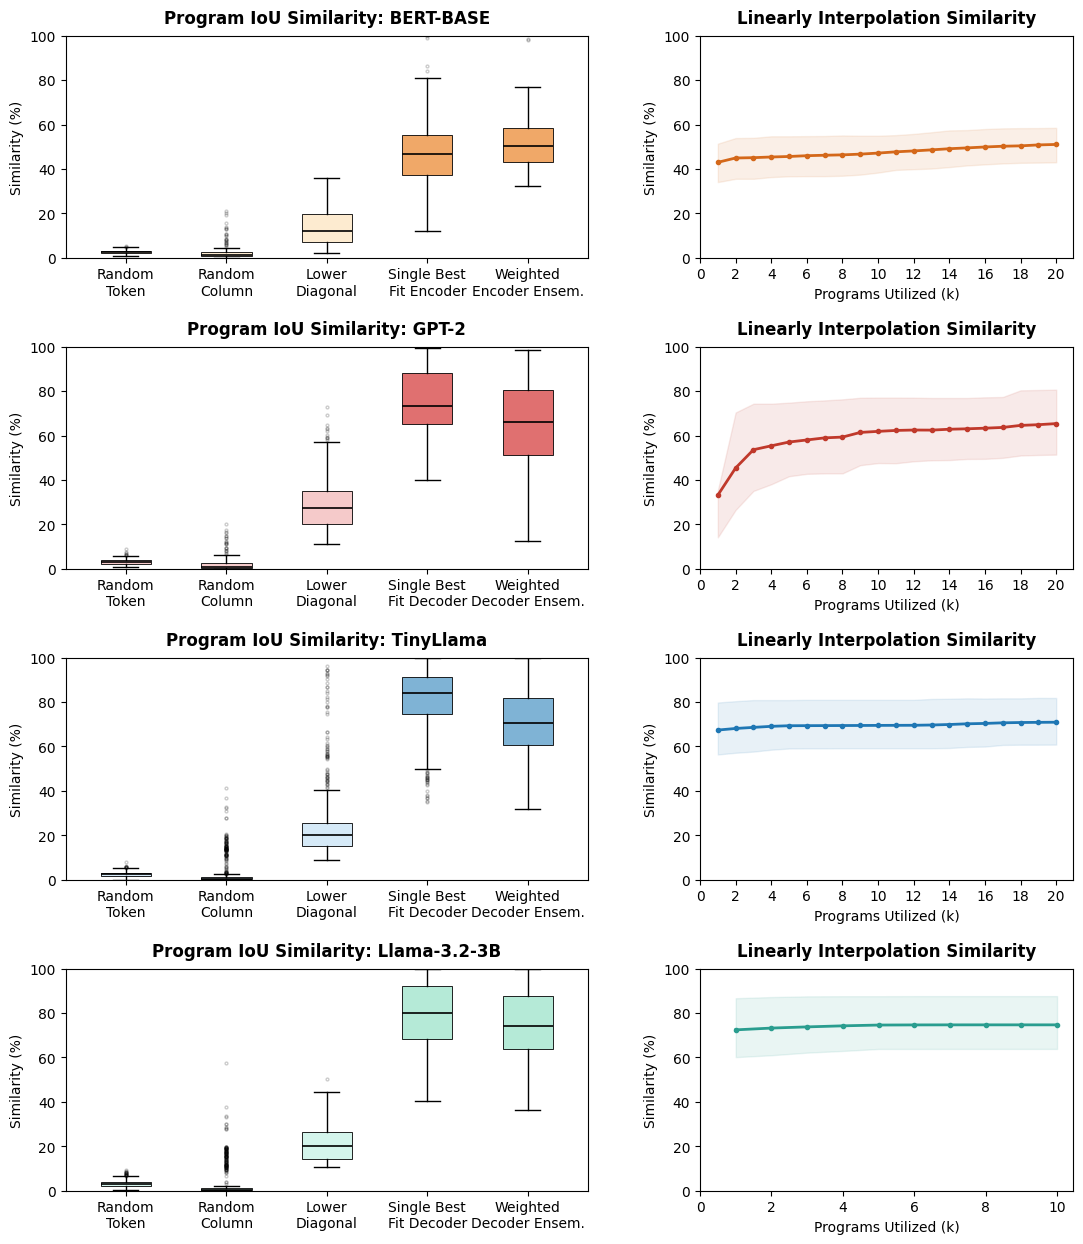

In [1]:
# ============================================================
#  FIGURE 4.1 — Self-contained plotting cell (REPAIR VERSION)
# ============================================================

# ... [Steps 1-3 remain the same as previous] ...
import os, sys, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

DATA_BASE    = "../data"
DATA_DIR     = f"{DATA_BASE}"
RESULTS_DIR  = f"../results"

MODEL_CONFIGS = {
    "bert":      {"display": "BERT-BASE", "arch": "Encoder", "hf_name": "bert-base-uncased"},
    "gpt2":      {"display": "GPT-2",     "arch": "Decoder", "hf_name": "openai-community/gpt2"},
    "tinyllama": {"display": "TinyLlama", "arch": "Decoder", "hf_name": "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"},
    "llama3b":   {"display": "Llama-3.2-3B", "arch": "Decoder", "hf_name": "meta-llama/Llama-3.2-3B", "hf_token": "X"},  # set hf_token="hf_..." if needed
}

def iou_score(p, q):
    p = np.clip(p, 1e-12, 1.0); q = np.clip(q, 1e-12, 1.0)
    return float(np.minimum(p, q).sum() / np.maximum(p, q).sum())

def compute_baselines(hf_name, sentences, device="cpu", hf_token=None, use_fp16=False):
    load_kw = dict(output_attentions=True)
    if hf_token: load_kw["token"] = hf_token
    if use_fp16: load_kw["torch_dtype"] = __import__("torch").float16
    model = AutoModel.from_pretrained(hf_name, **load_kw).to(device)
    tok_kw = {"token": hf_token} if hf_token else {}
    tok   = AutoTokenizer.from_pretrained(hf_name, **tok_kw)
    n_layers, n_heads = model.config.num_hidden_layers, model.config.num_attention_heads
    accum_token, accum_col, accum_diag = np.zeros(n_layers * n_heads), np.zeros(n_layers * n_heads), np.zeros(n_layers * n_heads)

    for sent in sentences:
        inputs = tok(sent, return_tensors="pt").to(device)
        with torch.no_grad(): atts = model(**inputs).attentions
        for l in range(n_layers):
            for h in range(n_heads):
                att = atts[l][0, h].to(torch.float32).cpu().numpy()
                n = att.shape[0]
                ref_diag = np.tril(np.ones((n, n))); ref_diag /= ref_diag.sum(axis=1, keepdims=True)
                ref_col = np.zeros((n, n)); ref_col[:, np.random.randint(0, n)] = 1.0
                ref_tok = np.zeros((n, n))
                for i in range(n): ref_tok[i, np.random.randint(0, n)] = 1.0
                idx = l * n_heads + h
                accum_diag[idx] += np.mean([iou_score(att[i], ref_diag[i]) for i in range(n)])
                accum_col[idx] += np.mean([iou_score(att[i], ref_col[i]) for i in range(n)])
                accum_token[idx] += np.mean([iou_score(att[i], ref_tok[i]) for i in range(n)])
    del model, tok
    return (accum_token/len(sentences)*100).tolist(), (accum_col/len(sentences)*100).tolist(), (accum_diag/len(sentences)*100).tolist()

# ── 5. Load Sentences ──
df_json = pd.read_json(f"{DATA_DIR}/generic_sentences.json")
SAMPLE_SENTENCES = df_json[0].sample(5, random_state=RANDOM_SEED).tolist()

# ── 6. Build Data (Diagnostic Fix) ──
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_results = {}

for key, cfg in MODEL_CONFIGS.items():
    print(f"\n── {key.upper()} ──────────────────────────────────────────")
    # Try multiple common naming conventions for the CSV
    interp_csv = f"{DATA_DIR}/interpolation_k_{key}.csv"
    if not os.path.exists(interp_csv):
        interp_csv = f"{DATA_DIR}/interpolation_k_{key.upper()}.csv"

    iou_csv = f"{DATA_DIR}/iou_scores_{key}.csv"
    
    _token   = cfg.get("hf_token")
    _fp16    = cfg.get("use_fp16", key == "llama3b")
    b_tok, b_col, b_diag = compute_baselines(
        cfg["hf_name"], SAMPLE_SENTENCES, device=DEVICE,
        hf_token=_token, use_fp16=_fp16)
    print(f"  Baseline (Diag): {np.mean(b_diag):.1f}%")

    best_single = []
    if os.path.exists(iou_csv):
        iou_df = pd.read_csv(iou_csv)
        best_single = (iou_df.groupby(["layer", "head"])["iou_score"].max().dropna() * 100).tolist()
        print(f"  Best-single: mean={np.mean(best_single):.1f}%")

    all_weighted, k_sweep = [], {}
    if os.path.exists(interp_csv):
        interp_df = pd.read_csv(interp_csv)
        # Ensure k and iou_score are numeric and drop NaNs
        interp_df["k"] = pd.to_numeric(interp_df["k"], errors='coerce')
        interp_df["iou_score"] = pd.to_numeric(interp_df["iou_score"], errors='coerce')
        interp_df = interp_df.dropna(subset=["k", "iou_score"])
        
        interp_df["iou_val"] = interp_df["iou_score"] * 100
        max_k = interp_df["k"].max()
        
        all_weighted = interp_df[interp_df["k"] == max_k]["iou_val"].tolist()
        
        for kval, grp in interp_df.groupby("k"):
            k_sweep[int(kval)] = grp["iou_val"].tolist()
        
        print(f"  Interpolation: Found k-values {sorted(k_sweep.keys())}")
        print(f"  All-weighted (k={max_k}): mean={np.mean(all_weighted):.1f}%")
    else:
        print(f"  [ERROR] CSV NOT FOUND: {interp_csv}")

    model_results[key] = {"box_data": [b_tok, b_col, b_diag, best_single, all_weighted], "k_sweep": k_sweep}

# ── 7. Plotting ──
def styled_boxplot(ax, data, labels, colors, positions):
    valid = [(d, l, p) for d, l, p in zip(data, labels, positions) if len(d) > 0]
    if not valid: return
    vdata, vlabels, vpos = zip(*valid)
    bp = ax.boxplot(vdata, positions=list(vpos), patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=1.2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_edgecolor("black"); patch.set_linewidth(0.6)
    ax.set_xticks(list(vpos)); ax.set_xticklabels(list(vlabels))

ROW_COLORS = {
    "bert":      {"box": "#f0a868", "line": "#d4681a", "base": "#fdebd0"},
    "gpt2":      {"box": "#e07070", "line": "#c0392b", "base": "#f5caca"},
    "tinyllama": {"box": "#7fb3d5", "line": "#1f77b4", "base": "#d6eaf8"},
    "llama3b":   {"box": "#b5ead7", "line": "#2a9d8f", "base": "#d4f5ec"},
}

fig = plt.figure(figsize=(13, 15)) 
gs  = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.25, width_ratios=[1.4, 1])

for row, key in enumerate(["bert", "gpt2", "tinyllama", "llama3b"]):
    cfg, res, c = MODEL_CONFIGS[key], model_results[key], ROW_COLORS[key]
    colors = [c["base"], c["base"], c["base"], c["box"], c["box"]]

    ax_box = fig.add_subplot(gs[row, 0])
    labels = ["Random\nToken", "Random\nColumn", "Lower\nDiagonal", f"Single Best\nFit {cfg['arch']}", f"Weighted\n{cfg['arch']} Ensem."]
    styled_boxplot(ax_box, res["box_data"], labels, colors, positions=[1, 2, 3, 4, 5])
    ax_box.set_title(f"Program IoU Similarity: {cfg['display']}", fontweight="bold", pad=9)
    ax_box.set_ylabel("Similarity (%)"); ax_box.set_ylim(0, 100); ax_box.set_xlim(0.4, 5.6)

    ax_line = fig.add_subplot(gs[row, 1])
    ax_line.set_title("Linearly Interpolation Similarity", fontweight="bold", pad=9)
    ax_line.set_xlabel("Programs Utilized (k)"); ax_line.set_ylabel("Similarity (%)"); ax_line.set_ylim(0, 100)
    
    if res["k_sweep"]:
        ks = sorted(res["k_sweep"].keys())
        means = [np.mean(res["k_sweep"][k]) for k in ks]
        p25, p75 = [np.percentile(res["k_sweep"][k], 25) for k in ks], [np.percentile(res["k_sweep"][k], 75) for k in ks]
        ax_line.plot(ks, means, color=c["line"], linewidth=2, marker="o", markersize=3)
        ax_line.fill_between(ks, p25, p75, color=c["line"], alpha=0.1)
        ax_line.set_xticks(range(0, max(ks) + 2, 2))
    else:
        ax_line.text(0.5, 0.5, "(check GPT-2 CSV path)", transform=ax_line.transAxes, ha="center", color="red")

# for ax in fig.axes:
    # ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# plt.savefig(f"{RESULTS_DIR}/plots/figure_4_1.pdf", dpi=300, bbox_inches="tight")
plt.show()


── BERT ──────────────────────────────────────────
  Baseline (Diag): 14.0%
  Best-single: mean=47.3%
  All-weighted (k=20): mean=51.1%

── GPT2 ──────────────────────────────────────────
  Baseline (Diag): 29.7%
  Best-single: mean=75.3%
  All-weighted (k=20): mean=65.4%

── TINYLLAMA ──────────────────────────────────────────
  Baseline (Diag): 23.9%
  Best-single: mean=81.2%
  All-weighted (k=20): mean=70.9%

── LLAMA3B ──────────────────────────────────────────


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Baseline (Diag): 21.1%
  Best-single: mean=78.7%
  All-weighted (k=10): mean=74.7%


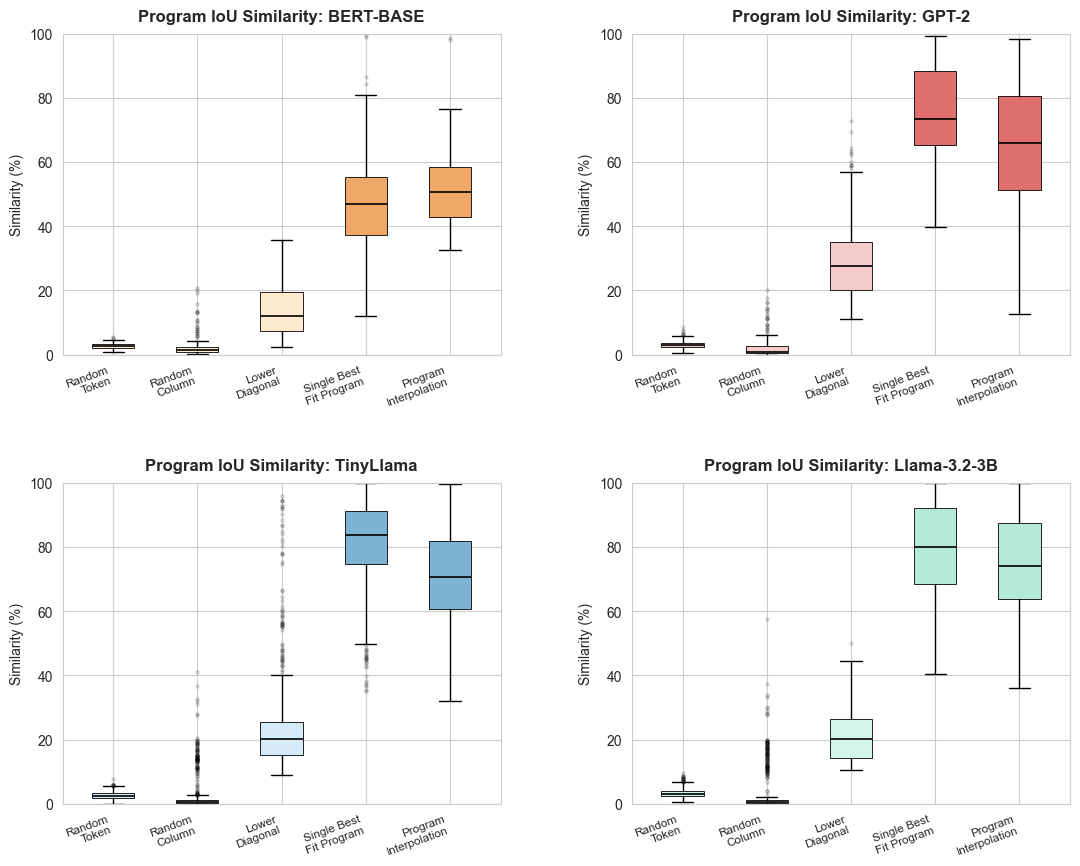

In [ ]:
import os, sys, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

DATA_BASE   = "../data"
DATA_DIR    = f"{DATA_BASE}"
RESULTS_DIR = f"../results"

MODEL_CONFIGS = {
    "bert":      {"display": "BERT-BASE",    "arch": "Encoder", "hf_name": "bert-base-uncased"},
    "gpt2":      {"display": "GPT-2",        "arch": "Decoder", "hf_name": "openai-community/gpt2"},
    "tinyllama": {"display": "TinyLlama",    "arch": "Decoder", "hf_name": "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"},
    "llama3b":   {"display": "Llama-3.2-3B", "arch": "Decoder", "hf_name": "meta-llama/Llama-3.2-3B", "hf_token": "X"},
}

def iou_score(p, q):
    p = np.clip(p, 1e-12, 1.0); q = np.clip(q, 1e-12, 1.0)
    return float(np.minimum(p, q).sum() / np.maximum(p, q).sum())

def compute_baselines(hf_name, sentences, device="cpu", hf_token=None, use_fp16=False):
    load_kw = dict(output_attentions=True)
    if hf_token: load_kw["token"] = hf_token
    if use_fp16: load_kw["torch_dtype"] = __import__("torch").float16
    model = AutoModel.from_pretrained(hf_name, **load_kw).to(device)
    tok_kw = {"token": hf_token} if hf_token else {}
    tok = AutoTokenizer.from_pretrained(hf_name, **tok_kw)
    n_layers, n_heads = model.config.num_hidden_layers, model.config.num_attention_heads
    accum_token, accum_col, accum_diag = np.zeros(n_layers * n_heads), np.zeros(n_layers * n_heads), np.zeros(n_layers * n_heads)

    for sent in sentences:
        inputs = tok(sent, return_tensors="pt").to(device)
        with torch.no_grad(): atts = model(**inputs).attentions
        for l in range(n_layers):
            for h in range(n_heads):
                att = atts[l][0, h].to(torch.float32).cpu().numpy()
                n = att.shape[0]
                ref_diag = np.tril(np.ones((n, n))); ref_diag /= ref_diag.sum(axis=1, keepdims=True)
                ref_col = np.zeros((n, n)); ref_col[:, np.random.randint(0, n)] = 1.0
                ref_tok = np.zeros((n, n))
                for i in range(n): ref_tok[i, np.random.randint(0, n)] = 1.0
                idx = l * n_heads + h
                accum_diag[idx] += np.mean([iou_score(att[i], ref_diag[i]) for i in range(n)])
                accum_col[idx]   += np.mean([iou_score(att[i], ref_col[i]) for i in range(n)])
                accum_token[idx] += np.mean([iou_score(att[i], ref_tok[i]) for i in range(n)])
    del model, tok
    return (accum_token/len(sentences)*100).tolist(), (accum_col/len(sentences)*100).tolist(), (accum_diag/len(sentences)*100).tolist()

# ── Load Sentences ──
df_json = pd.read_json(f"{DATA_DIR}/generic_sentences.json")
SAMPLE_SENTENCES = df_json[0].sample(5, random_state=RANDOM_SEED).tolist()

# ── Build Data ──
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_results = {}

for key, cfg in MODEL_CONFIGS.items():
    print(f"\n── {key.upper()} ──────────────────────────────────────────")
    iou_csv = f"{DATA_DIR}/iou_scores_{key}.csv"

    _token = cfg.get("hf_token")
    _fp16  = cfg.get("use_fp16", key == "llama3b")
    b_tok, b_col, b_diag = compute_baselines(
        cfg["hf_name"], SAMPLE_SENTENCES, device=DEVICE,
        hf_token=_token, use_fp16=_fp16)
    print(f"  Baseline (Diag): {np.mean(b_diag):.1f}%")

    best_single = []
    if os.path.exists(iou_csv):
        iou_df = pd.read_csv(iou_csv)
        best_single = (iou_df.groupby(["layer", "head"])["iou_score"].max().dropna() * 100).tolist()
        print(f"  Best-single: mean={np.mean(best_single):.1f}%")

    interp_csv = f"{DATA_DIR}/interpolation_k_{key}.csv"
    if not os.path.exists(interp_csv):
        interp_csv = f"{DATA_DIR}/interpolation_k_{key.upper()}.csv"

    all_weighted = []
    if os.path.exists(interp_csv):
        interp_df = pd.read_csv(interp_csv)
        interp_df["k"] = pd.to_numeric(interp_df["k"], errors="coerce")
        interp_df["iou_score"] = pd.to_numeric(interp_df["iou_score"], errors="coerce")
        interp_df = interp_df.dropna(subset=["k", "iou_score"])
        interp_df["iou_val"] = interp_df["iou_score"] * 100
        max_k = interp_df["k"].max()
        all_weighted = interp_df[interp_df["k"] == max_k]["iou_val"].tolist()
        print(f"  All-weighted (k={max_k}): mean={np.mean(all_weighted):.1f}%")

    model_results[key] = {"box_data": [b_tok, b_col, b_diag, best_single, all_weighted]}

# ── Plotting ──
def styled_boxplot(ax, data, labels, colors, positions):
    valid = [(d, l, p) for d, l, p in zip(data, labels, positions) if len(d) > 0]
    if not valid: return
    vdata, vlabels, vpos = zip(*valid)
    bp = ax.boxplot(vdata, positions=list(vpos), patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=1.2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_edgecolor("black"); patch.set_linewidth(0.6)
    ax.set_xticks(list(vpos))
    ax.set_xticklabels(list(vlabels), rotation=20, ha="right", fontsize=8.5)

ROW_COLORS = {
    "bert":      {"box": "#f0a868", "base": "#fdebd0"},
    "gpt2":      {"box": "#e07070", "base": "#f5caca"},
    "tinyllama": {"box": "#7fb3d5", "base": "#d6eaf8"},
    "llama3b":   {"box": "#b5ead7", "base": "#d4f5ec"},
}

keys = ["bert", "gpt2", "tinyllama", "llama3b"]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

for ax, key in zip(axes.flat, keys):
    cfg, res, c = MODEL_CONFIGS[key], model_results[key], ROW_COLORS[key]
    colors = [c["base"], c["base"], c["base"], c["box"], c["box"]]
    labels = ["Random\nToken", "Random\nColumn", "Lower\nDiagonal",
              f"Single Best\nFit Program", f"Program\nInterpolation"]
    styled_boxplot(ax, res["box_data"], labels, colors, positions=[1, 2, 3, 4, 5])
    ax.set_title(f"Program IoU Similarity: {cfg['display']}", fontweight="bold", pad=9)
    ax.set_ylabel("Similarity (%)")
    ax.set_ylim(0, 100)
    ax.set_xlim(0.4, 5.6)

plt.savefig(f"{RESULTS_DIR}/plots/figure_4_1.pdf", dpi=300, bbox_inches="tight")
plt.show()

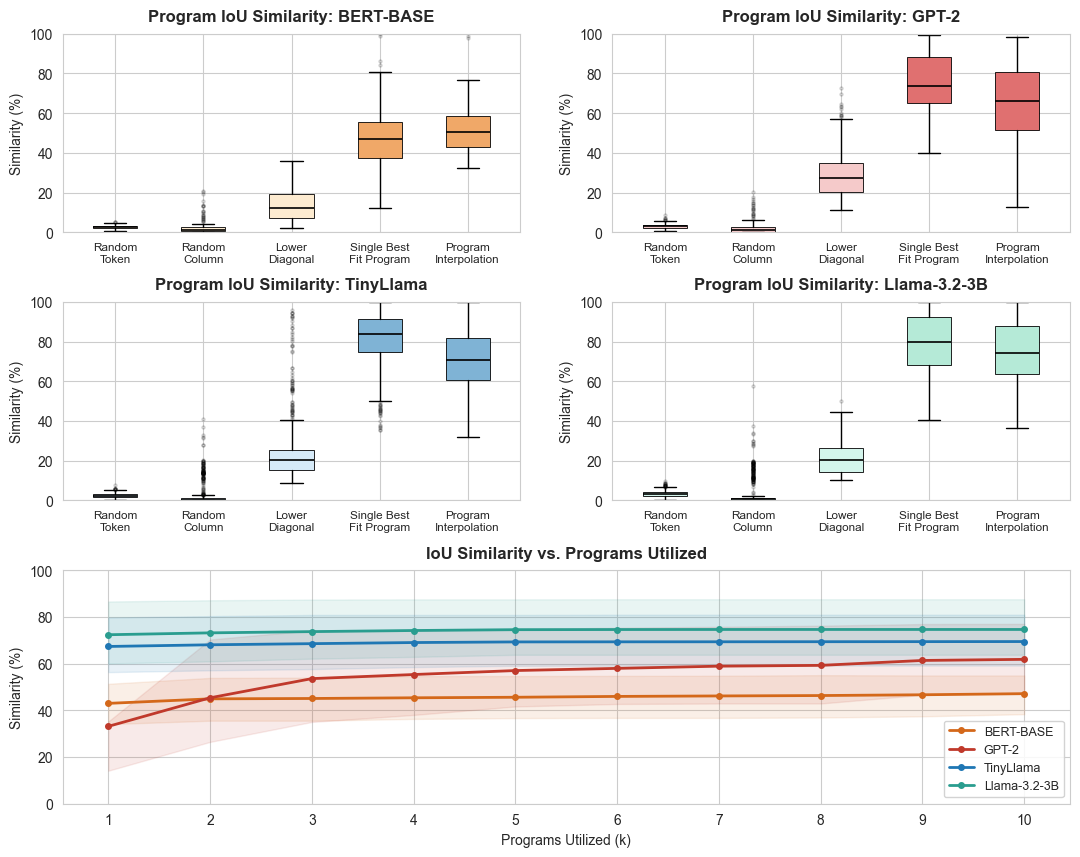

In [18]:
def styled_boxplot(ax, data, labels, colors, positions):
    valid = [(d, l, p) for d, l, p in zip(data, labels, positions) if len(d) > 0]
    if not valid: return
    vdata, vlabels, vpos = zip(*valid)
    bp = ax.boxplot(vdata, positions=list(vpos), patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=1.2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_edgecolor("black"); patch.set_linewidth(0.6)
    ax.set_xticks(list(vpos))
    ax.set_xticklabels(list(vlabels), rotation=0, ha="center", fontsize=8.5)


ROW_COLORS = {
    "bert":      {"box": "#f0a868", "base": "#fdebd0", "line": "#d4681a"},
    "gpt2":      {"box": "#e07070", "base": "#f5caca", "line": "#c0392b"},
    "tinyllama": {"box": "#7fb3d5", "base": "#d6eaf8", "line": "#1f77b4"},
    "llama3b":   {"box": "#b5ead7", "base": "#d4f5ec", "line": "#2a9d8f"},
}

keys = ["bert", "gpt2", "tinyllama", "llama3b"]

# ── Figure: 2x2 grid on top, line plot below ──
fig = plt.figure(figsize=(13, 10))
gs  = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.2)

gs_top = gs[0].subgridspec(2, 2, hspace=0.35, wspace=0.2)

for idx, key in enumerate(keys):
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs_top[row, col])
    cfg, res, c = MODEL_CONFIGS[key], model_results[key], ROW_COLORS[key]
    colors = [c["base"], c["base"], c["base"], c["box"], c["box"]]
    labels = ["Random\nToken", "Random\nColumn", "Lower\nDiagonal",
              "Single Best\nFit Program", "Program\nInterpolation"]
    styled_boxplot(ax, res["box_data"], labels, colors, positions=[1, 2, 3, 4, 5])
    ax.set_title(f"Program IoU Similarity: {cfg['display']}", fontweight="bold", pad=9)
    ax.set_ylabel("Similarity (%)")
    ax.set_ylim(0, 100)
    ax.set_xlim(0.4, 5.6)

# ── Line plot: mean IoU vs k ──
ax_line = fig.add_subplot(gs[1])

for key in keys:
    res, c, cfg = model_results[key], ROW_COLORS[key], MODEL_CONFIGS[key]
    k_sweep = res.get("k_sweep", {})
    if not k_sweep:
        continue

    ks    = sorted(k for k in k_sweep.keys() if k <= 10)
    if not ks:
        continue

    means = [np.mean(k_sweep[k]) for k in ks]
    p25   = [np.percentile(k_sweep[k], 25) for k in ks]
    p75   = [np.percentile(k_sweep[k], 75) for k in ks]

    ax_line.plot(ks, means, color=c["line"], linewidth=2, marker="o",
                 markersize=4, label=cfg["display"])
    ax_line.fill_between(ks, p25, p75, color=c["line"], alpha=0.10)

ax_line.set_title("IoU Similarity vs. Programs Utilized",
                  fontweight="bold", pad=9)
ax_line.set_xlabel("Programs Utilized (k)")
ax_line.set_ylabel("Similarity (%)")
ax_line.set_ylim(0, 100)
ax_line.set_xticks(range(1, 11))
ax_line.legend(framealpha=0.85, fontsize=9)

plt.savefig(f"{RESULTS_DIR}/plots/figure_4_1.pdf", dpi=300, bbox_inches="tight")
plt.show()

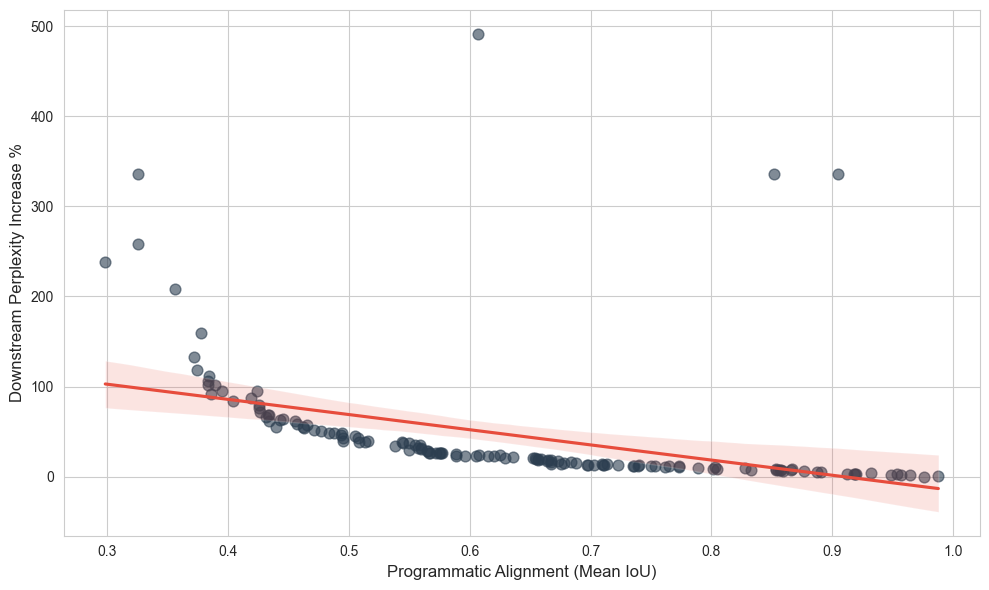

Successfully matched 138 heads.
Spearman Correlation: -0.9215


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# 1. Load your data
df_results = pd.read_csv(r"..\results\replacement_run\shuffles\gpt2_smart_shuffle_8.csv")
df_iou = pd.read_csv(r"..\data\iou_scores_gpt2.csv")

# 2. Process IoU: Aggregate sentences
df_iou_agg = df_iou.groupby(['layer', 'head', 'program_idx'])['iou_score'].mean().reset_index()

def get_program_name(idx):
    obj = all_programs[idx]
    return obj.__name__ if hasattr(obj, '__name__') else str(obj)

df_iou_agg['program'] = df_iou_agg['program_idx'].apply(get_program_name)

# 3. Standardize Head Keys
def clean_key(h):
    try:
        val = ast.literal_eval(str(h).strip())
        return f"({val[0]}, {val[1]})"
    except:
        return str(h).strip()

df_results['head_key'] = df_results['head'].apply(clean_key)
df_iou_agg['head_key'] = df_iou_agg.apply(lambda x: f"({int(x['layer'])}, {int(x['head'])})", axis=1)

# 4. Merge
df_plot = pd.merge(
    df_results,
    df_iou_agg[['head_key', 'program', 'iou_score']],
    on=['head_key', 'program'],
    how='inner'
)

# 5. Plotting Logic
if df_plot.empty:
    print("!! ERROR: Still no matches. !!")
    print(f"Sample Result Program: {df_results['program'].iloc[0]}")
    print(f"Sample IoU Program: {df_iou_agg['program'].iloc[0]}")
else:
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Main Plot
    sns.regplot(
        data=df_plot,
        x='iou_score',
        y='increase',
        scatter_kws={'alpha':0.6, 'color':'#2c3e50', 's':60},
        line_kws={'color':'#e74c3c', 'label':'Linear Trend'}
    )

    # Border
    # ax = plt.gca()
    # for spine in ax.spines.values():
    #     spine.set_visible(True)
    #     spine.set_linewidth(1.5)
    #     spine.set_edgecolor('black')

    # Statistical Annotation
    corr = df_plot['iou_score'].corr(df_plot['increase'], method='spearman')
    # plt.text(0.05, 0.95, f'Spearman ρ: {corr:.3f}', transform=ax.transAxes,
    #          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    # plt.title("GPT-2 Correlation of Program Scores to Perplexity Increase", fontsize=14)
    plt.xlabel("Programmatic Alignment (Mean IoU)", fontsize=12)
    plt.ylabel("Downstream Perplexity Increase %", fontsize=12)

    plt.tight_layout()
    plt.savefig(r"..\results\plots\figure_4_2_1.pdf", dpi=300)
    plt.show()

    print(f"Successfully matched {len(df_plot)} heads.")
    print(f"Spearman Correlation: {corr:.4f}")

## Figure 4.2: Best-Fit Program Mapping by Head

Maps each attention head to its highest-IoU hypothesis program and visualizes category-aware patterns across layers and heads.

In [3]:
import inspect
import json
import os
import sys
from typing import List, Callable
import pandas as pd

# ============================================================
# Figure 4.2 data prep: build/read best-fit CSVs per model
# Expected paths:
#   ../data/iou_scores_{model}.csv
#   ../results/program_categories.json
# ============================================================

DATA_BASE    = "../data"
DATA_DIR     = f"{DATA_BASE}"
RESULTS_DIR  = f"../results"

MODEL_CONFIGS = {
    "bert":      {"display": "BERT-BASE", "arch": "Encoder", "hf_name": "bert-base-uncased"},
    "gpt2":      {"display": "GPT-2",     "arch": "Decoder", "hf_name": "openai-community/gpt2"},
    "tinyllama": {"display": "TinyLlama", "arch": "Decoder", "hf_name": "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"},
    "llama3b":   {"display": "Llama-3.2-3B", "arch": "Decoder", "hf_name": "meta-llama/Llama-3.2-3B", "hf_token": "X"},  # set hf_token="hf_..." if needed
}

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import inspect
from data import golden_programs
from data import golden_programs_two

# Get all functions from the module
all_programs = [
    obj for _, obj in inspect.getmembers(golden_programs, inspect.isfunction)
]
new_programs = [
    obj for _, obj in inspect.getmembers(golden_programs_two, inspect.isfunction)
]
unique_golden_map = {f.__name__: f for f in all_programs}
sorted_golden_names = sorted(unique_golden_map.keys())
all_programs_sorted = [unique_golden_map[name] for name in sorted_golden_names]
golden_names_set = set(sorted_golden_names)
all_programs_new = []
seen_new_names = set()
for func in new_programs:
    name = func.__name__
    if name not in golden_names_set and name not in seen_new_names:
        all_programs_new.append(func)
        seen_new_names.add(name)
all_programs = all_programs_sorted + all_programs_new

remove = [
    "_get_gpt2_tokenizer", "align_gpt2_to_spacy", "align_spacy_to_gpt2", 
    "apply_causal_mask", "spacy_parse", "first_token_bias_stochastic_L7H11", 
    "get_modifying_adjectives", "get_nlp", "gpt2_tokenize", "make_row_stochastic",]
all_programs = [f for f in all_programs if f.__name__ not in remove]

# Program categories prepared offline
with open("../results/program_categories.json", "r") as f:
    attention_head_categories = json.load(f)

# Verification of programs
total_count = sum(len(v) for v in attention_head_categories.values())
print(f"[INFO] Programs loaded: {len(all_programs)}")
print(f"[INFO] Programs categorized: {total_count}")

for model_key in MODEL_CONFIGS.keys():
    iou_csv = f"{DATA_DIR}/iou_scores_{model_key}.csv"
    if not os.path.exists(iou_csv):
        print(f"[WARN] Missing: {iou_csv}. Skipping best-fit generation for {model_key}.")
        continue

    # Skip if best-fit CSV already exists
    out_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    # if os.path.exists(out_csv):
    #     print(f"[INFO] Already exists: {out_csv}. Skipping best-fit generation for {model_key}.")
    #     continue

    iou_df = pd.read_csv(iou_csv)
    iou_df = iou_df.groupby(["layer", "head", "program_idx"])["iou_score"].mean().reset_index()

    n_best_programs = 1
    best_fits = (
        iou_df.groupby(["layer", "head"])
        .apply(lambda g: g.nlargest(n_best_programs, "iou_score"))
        .reset_index(drop=True)
    )

    best_fits["iou_score"] = best_fits["iou_score"].round(3)
    best_fits.to_csv(out_csv, index=False)
    print(f"[DONE] Saved best fits for {model_key} to {out_csv}")

best_fits_bert = []
best_fits_gpt2 = []
best_fits_tinyllama = []
best_fits_llama3b = []

for model_key in MODEL_CONFIGS.keys():
    best_fits_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    if os.path.exists(best_fits_csv):
        df = pd.read_csv(best_fits_csv)
        _names = [all_programs[int(i)].__name__ for i in df["program_idx"]]
        _tuples = list(zip(df["layer"].astype(int), df["head"].astype(int), _names, df["iou_score"]))
        if model_key == "bert":      best_fits_bert      = _tuples
        elif model_key == "gpt2":    best_fits_gpt2      = _tuples
        elif model_key == "tinyllama": best_fits_tinyllama = _tuples
        elif model_key == "llama3b": best_fits_llama3b   = _tuples
        print(f"[INFO] Loaded best fits for {model_key} from {best_fits_csv}")
    else:
        print(f"[WARN] Missing: {best_fits_csv}. Cannot load best fits for {model_key}.")

[INFO] Programs loaded: 144
[INFO] Programs categorized: 144
[DONE] Saved best fits for bert to ../results/best_fits_bert.csv
[DONE] Saved best fits for gpt2 to ../results/best_fits_gpt2.csv
[DONE] Saved best fits for tinyllama to ../results/best_fits_tinyllama.csv
[DONE] Saved best fits for llama3b to ../results/best_fits_llama3b.csv
[INFO] Loaded best fits for bert from ../results/best_fits_bert.csv
[INFO] Loaded best fits for gpt2 from ../results/best_fits_gpt2.csv
[INFO] Loaded best fits for tinyllama from ../results/best_fits_tinyllama.csv
[INFO] Loaded best fits for llama3b from ../results/best_fits_llama3b.csv


In [ ]:
import inspect
import json
import os
import sys
from typing import List, Callable
import pandas as pd

# ============================================================
# Figure 4.2 data prep: build/read best-fit CSVs per model
# ============================================================

DATA_BASE    = "../data"
DATA_DIR     = f"{DATA_BASE}"
RESULTS_DIR  = f"../results"

MODEL_CONFIGS = {
    "bert":      {"display": "BERT-BASE", "arch": "Encoder", "hf_name": "bert-base-uncased"},
    "gpt2":      {"display": "GPT-2",     "arch": "Decoder", "hf_name": "openai-community/gpt2"},
    "tinyllama": {"display": "TinyLlama", "arch": "Decoder", "hf_name": "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"},
    "llama3b":   {"display": "Llama-3.2-3B", "arch": "Decoder", "hf_name": "meta-llama/Llama-3.2-3B"},
}

# The "Rosetta Stone": Mapping your original indices to function names
OLD_INDEX_MAP = {
    "0": "adverbial_modulation", "1": "appositive_phrase_attention", "2": "cls_attention",
    "3": "complement_adjunct_relationship", "4": "compound_element_association",
    "5": "compound_modifier_attention", "6": "compound_word_attention_pattern",
    "7": "conjunction_based_grouping", "8": "conjunction_resolution", "9": "contextual_anchoring",
    "10": "coord_and_verb_dependency", "11": "coordination_attention", "12": "coreference_resolution",
    "13": "dependencies", "14": "dominant_subject_attention", "15": "emphasize_verbs_and_objects",
    "16": "eos_attention", "17": "first_token_dominance", "18": "first_token_domination",
    "19": "first_token_emphasis", "20": "head_initial_token_emphasis", "21": "high_saliency_relationship_detection",
    "22": "initial_contextual_attention", "23": "initial_element_reinforcement",
    "24": "initial_phrase_contextualization", "25": "initial_phrase_dominance",
    "26": "initial_reference_attention", "27": "initial_token_anchoring", "28": "initial_token_attachment",
    "29": "initial_token_attention", "30": "initial_token_centralization", "31": "initial_token_dominance",
    "32": "initial_token_emphasis", "33": "initial_token_reference_attention", "34": "initial_word_attention",
    "35": "last_token_attention", "36": "leading_contextual_emphasis", "37": "lexical_diversity_focus",
    "38": "main_subject_attention", "39": "negation_attention", "40": "next_attention",
    "41": "parenthetical_attention", "42": "parenthetical_insertion", "43": "pos_alignment",
    "44": "previous_attention", "45": "pronoun_reference", "46": "punctuation_attention",
    "47": "quotation_association", "48": "rare_word_dominance", "49": "relative_position_attention",
    "50": "repeated_attention", "51": "same_attention", "52": "semantic_grouping",
    "53": "sentence_beginning_attention_pattern", "54": "sentence_beginning_emphasis",
    "55": "sentence_beginning_salience", "56": "sentence_boundary_focus", "57": "sentence_initial_dominance",
    "58": "sentence_initiation_emphasis", "59": "sentence_level_attention", "60": "sentence_level_initial_token_repetition",
    "61": "sentence_opening_salience", "62": "sentence_position_preference", "63": "sentence_start_attention",
    "64": "sentence_start_dominance", "65": "sentence_start_emphasis", "66": "special_token_attention",
    "67": "token_emphasis_subsequent_dominance", "68": "token_reinforcement", "69": "uniform_attention",
    "70": "uniform_lower_diagonal"
}

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from data import golden_programs, golden_programs_two

# --- Build the Alphabetized + Extended List ---
raw_golden = [obj for _, obj in inspect.getmembers(golden_programs, inspect.isfunction)]
raw_new = [obj for _, obj in inspect.getmembers(golden_programs_two, inspect.isfunction)]

# Deduplicate Golden and Sort Alphabetically
unique_golden_map = {f.__name__: f for f in raw_golden}
sorted_golden_names = sorted(unique_golden_map.keys())
all_programs_sorted = [unique_golden_map[name] for name in sorted_golden_names]

# Add new programs to the end if not already present
golden_names_set = set(sorted_golden_names)
all_programs_new = []
seen_new_names = set()
for func in raw_new:
    name = func.__name__
    if name not in golden_names_set and name not in seen_new_names:
        all_programs_new.append(func)
        seen_new_names.add(name)

all_programs = all_programs_sorted + all_programs_new

# Cleanup
remove = [
    "_get_gpt2_tokenizer", "align_gpt2_to_spacy", "align_spacy_to_gpt2", 
    "apply_causal_mask", "spacy_parse", "first_token_bias_stochastic_L7H11", 
    "get_modifying_adjectives", "get_nlp", "gpt2_tokenize", "make_row_stochastic"
]
all_programs = [f for f in all_programs if f.__name__ not in remove]

# Mapping for the plotter to find the NEW index by name
name_to_new_idx = {f.__name__: i for i, f in enumerate(all_programs)}

with open("../results/program_categories.json", "r") as f:
    attention_head_categories = json.load(f)

print(f"[INFO] Programs loaded: {len(all_programs)}")

# --- Re-generate Best Fits to Align Indices ---
for model_key in MODEL_CONFIGS.keys():
    iou_csv = f"{DATA_DIR}/iou_scores_{model_key}.csv"
    out_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    
    if not os.path.exists(iou_csv): continue

    iou_df = pd.read_csv(iou_csv)
    
    # GROUPING: Get the average score per head per program
    iou_df = iou_df.groupby(["layer", "head", "program_idx"])["iou_score"].mean().reset_index()
    
    # PICK THE WINNER: This will now consider indices 0 through 143
    best_fits = (
        iou_df.groupby(["layer", "head"])
        .apply(lambda g: g.nlargest(1, "iou_score"))
        .reset_index(drop=True)
    )

    best_fits["iou_score"] = best_fits["iou_score"].round(3)
    best_fits.to_csv(out_csv, index=False)
    print(f"[DONE] Generated fresh best fits for {model_key} (Indices up to {iou_df['program_idx'].max()})")

# --- Load Tuples for Plotting ---
best_fits_bert, best_fits_gpt2, best_fits_tinyllama, best_fits_llama3b = [], [], [], []

for model_key in MODEL_CONFIGS.keys():
    best_fits_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    if os.path.exists(best_fits_csv):
        df = pd.read_csv(best_fits_csv)
        # Now i corresponds perfectly to all_programs[i]
        _names = [all_programs[int(i)].__name__ for i in df["program_idx"]]
        _tuples = list(zip(df["layer"].astype(int), df["head"].astype(int), _names, df["iou_score"]))
        
        if model_key == "bert":        best_fits_bert = _tuples
        elif model_key == "gpt2":      best_fits_gpt2 = _tuples
        elif model_key == "tinyllama": best_fits_tinyllama = _tuples
        elif model_key == "llama3b":   best_fits_llama3b = _tuples

[INFO] Programs loaded: 144
[DONE] Generated fresh best fits for bert (Indices up to 142)


C:\Users\amkah\AppData\Local\Temp\ipykernel_10956\679214939.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(1, "iou_score"))
C:\Users\amkah\AppData\Local\Temp\ipykernel_10956\679214939.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(1, "iou_score"))


[DONE] Generated fresh best fits for gpt2 (Indices up to 141)


C:\Users\amkah\AppData\Local\Temp\ipykernel_10956\679214939.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(1, "iou_score"))


[DONE] Generated fresh best fits for tinyllama (Indices up to 141)
[DONE] Generated fresh best fits for llama3b (Indices up to 70)


C:\Users\amkah\AppData\Local\Temp\ipykernel_10956\679214939.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(1, "iou_score"))


In [ ]:
# all_programs = [
#     obj for _, obj in inspect.getmembers(golden_programs, inspect.isfunction)
# ]
for p in all_programs:
    print(p)

<function adverbial_modulation at 0x000001730E3DFBA0>
<function appositive_phrase_attention at 0x0000017309AA16C0>
<function cls_attention at 0x000001730E3DFCE0>
<function complement_adjunct_relationship at 0x00000173676139C0>
<function compound_element_association at 0x000001730E3DFC40>
<function compound_modifier_attention at 0x000001730E3DFA60>
<function compound_word_attention_pattern at 0x000001730E3DFB00>
<function conjunction_based_grouping at 0x000001730E3DF920>
<function conjunction_resolution at 0x0000017309AA2520>
<function contextual_anchoring at 0x000001730E3DF880>
<function coord_and_verb_dependency at 0x0000017309AA1760>
<function coordination_attention at 0x000001736774FF60>
<function coreference_resolution at 0x000001730E3DFEC0>
<function dependencies at 0x000001730E3DF9C0>
<function dominant_subject_attention at 0x000001730D508360>
<function emphasize_verbs_and_objects at 0x00000173674C28E0>
<function eos_attention at 0x000001730E3DF7E0>
<function first_token_dominanc

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

# Standardized Colormap: 0-40% White, 40-100% transitions to Dark Charcoal
colors = [(1, 1, 1), (1, 1, 1), (0.15, 0.15, 0.15)]
nodes = [0.0, 0.4, 1.0]
standard_prec_map = mcolors.LinearSegmentedColormap.from_list("custom_gray", list(zip(nodes, colors)))

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#001D3D",
    "relational_and_semantic":       "#4A90E2",
    "special_tokens_and_boundaries": "#7FF1F5",
    "linguistic_and_syntactic":      "#274C77",
    "sequential_and_induction":      "#0077B6",
    "uniformity_and_global":         "#95D5EE",
}

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#4285F4",
    "relational_and_semantic":       "#EA4335", 
    "special_tokens_and_boundaries": "#FBBC05",
    "linguistic_and_syntactic":      "#FF6D00",
    "sequential_and_induction":      "#34A853",
    "uniformity_and_global":         "#A142F4", 
}

all_names = [func.__name__ for func in all_programs]
os.makedirs("../results/plots/figure_4_2", exist_ok=True)

def save_heatmap(data, title, best_fits, all_names, filename, categories=None):
    n_rows, n_cols = data.shape
    fig_w = n_cols * 0.45 + 1.2
    fig_h = n_rows * 0.45 + 1.0
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    reversed_data = data[::-1]
    sns.heatmap(reversed_data, ax=ax, cmap=standard_prec_map, cbar=False,
                linewidths=0.5, linecolor='#EEEEEE', vmin=0, vmax=1, square=True)

    name_to_cat = get_name_to_category(categories) if categories else {}

    if best_fits is not None:
        for i, (head_id, name, score) in enumerate(best_fits):
            layer_val = i // n_cols
            x = i % n_cols
            y_pos = (n_rows - 1) - layer_val
            cell_value = data[layer_val, x] # The accuracy value for this cell

            if name:
                legend_idx = all_names.index(name) if name in all_names else head_id
                cat = name_to_cat.get(name, None)
                color = CATEGORY_COLORS.get(cat, "#333333")

                # Change 1: Text color dependent on background accuracy
                # If accuracy is high (dark background), use white text for visibility
                text_color = "white" if cell_value > 0.7 else "black"

                ax.add_patch(plt.Circle((x + 0.5, y_pos + 0.5), radius=0.3,
                                        facecolor='none', edgecolor=color,
                                        linewidth=3.5, zorder=3))

                ax.text(x + 0.5, y_pos + 0.5, str(legend_idx),
                        ha='center', va='center', color=text_color,
                        fontweight='bold', fontsize=8, zorder=4)

    # Change 2: Precision spacing beneath title using 'pad'
    ax.set_title(title, fontweight='bold', fontsize=11, color='#001D3D', pad=5)
    ax.set_yticklabels(range(n_rows - 1, -1, -1), rotation=0, fontsize=7)
    ax.set_xticklabels(range(n_cols), fontsize=7)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

def save_shared_colorbar(filename):
    # Change 3: Significantly thinner plot and removed helper text
    fig, ax = plt.subplots(figsize=(10, 0.15))
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=standard_prec_map),
                      cax=ax, orientation='horizontal')
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=7)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

def get_name_to_category(categories):
    return {m: cat for cat, members in categories.items() for m in members}

# 1. Build heatmap matrices — use (layer, head) from tuples directly
# best_fits_* are now (layer, head, name, score) so coordinates are exact.
def _build_matrix(best_fits, n_layers, n_heads):
    data = np.zeros((n_layers, n_heads))
    for layer, head, name, score in best_fits:
        if score is not None and layer < n_layers and head < n_heads:
            data[layer, head] = float(score)
    return data

bert_data      = _build_matrix(best_fits_bert,      12, 12)
gpt2_data      = _build_matrix(best_fits_gpt2,      12, 12)
tinyllama_data = _build_matrix(best_fits_tinyllama, 22, 32)
llama3b_data   = _build_matrix(best_fits_llama3b,   28, 24)

# Rebuild annotation lists in (program_idx_or_name, name, score) format
# save_heatmap iterates enumerate() and uses i // n_cols to place circles,
# so we reconstruct ordered flat lists (sorted by layer, head) for it.
def _ordered_fits(best_fits, n_layers, n_heads):
    grid = {}
    for layer, head, name, score in best_fits:
        grid[(layer, head)] = (name, score)
    result = []
    for l in range(n_layers):
        for h in range(n_heads):
            if (l, h) in grid:
                name, score = grid[(l, h)]
                result.append((h, name, score))
            else:
                result.append((h, None, 0.0))
    return result

best_fits_bert_ordered      = _ordered_fits(best_fits_bert,      12, 12)
best_fits_gpt2_ordered      = _ordered_fits(best_fits_gpt2,      12, 12)
best_fits_tinyllama_ordered = _ordered_fits(best_fits_tinyllama, 22, 32)
best_fits_llama3b_ordered   = _ordered_fits(best_fits_llama3b,   28, 24)

save_heatmap(bert_data, "BERT-BASE",
             best_fits_bert_ordered, all_names, "../results/plots/figure_4_2/fig_bert.png",
             categories=attention_head_categories)

save_heatmap(gpt2_data, "GPT-2",
             best_fits_gpt2_ordered, all_names, "../results/plots/figure_4_2/fig_gpt.png",
             categories=attention_head_categories)

save_heatmap(tinyllama_data, "TINY LLAMA",
             best_fits_tinyllama_ordered, all_names, "../results/plots/figure_4_2/fig_tinyllama.png",
             categories=attention_head_categories)

save_heatmap(llama3b_data, "LLAMA-3.2-3B",
             best_fits_llama3b_ordered, all_names, "../results/plots/figure_4_2/fig_llama3b.png",
             categories=attention_head_categories)

# 2. Generate the Ultra-Thin Shared Colorbar
# Place this at the very bottom of your figure grid in your document
save_shared_colorbar("../results/plots/figure_4_2/fig_shared_colorbar.png")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.colors as mcolors

def get_text_color(hex_color):
    """Returns 'black' for light colors and 'white' for dark colors."""
    rgb = mcolors.to_rgb(hex_color)
    # Standard formula for relative luminance
    luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
    return 'black' if luminance > 0.5 else 'white'

def save_category_boxes(filename):
    n_cats = len(CATEGORY_COLORS)
    fig, axes = plt.subplots(1, n_cats, figsize=(14, 1.2))
    fig.subplots_adjust(wspace=0.15)

    for ax, (group, color) in zip(axes, CATEGORY_COLORS.items()):
        ax.axis('off')

        # Draw the rounded box
        rect = mpatches.FancyBboxPatch(
            (0.05, 0.1), 0.9, 0.8,
            boxstyle="round,pad=0,rounding_size=0.15",
            color=color, transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(rect)

        # 1. ADD LOGIC HERE: Determine text color based on background luminance
        t_color = get_text_color(color)

        clean_name = group.replace('_', ' ').title().replace(' And', '\nAnd')

        # 2. UPDATE TEXT CALL: Use the dynamic t_color
        ax.text(0.5, 0.5, clean_name,
                color=t_color, ha='center', va='center',
                fontweight='bold', fontsize=10, transform=ax.transAxes,
                linespacing=1.5)

    plt.savefig(filename, dpi=300, bbox_inches='tight', transparent=True)
    plt.close()

# 2. Filtered Legend Only including programs present in the matrices
def save_filtered_legend(all_names, filename, categories, best_fits_list):
    """
    best_fits_list: list of lists, e.g., [best_fits_bert, best_fits_gpt, best_fits_tinyllama]
    """
    # Identify unique names that actually appeared in the matrices
    appeared_names = set()
    for fits in best_fits_list:
        if fits is not None:
            for head_id, name, score in fits:
                if name is not None:
                    appeared_names.add(name)

    # Filter and sort by original index to keep numbering consistent
    filtered_programs = [(i, name) for i, name in enumerate(all_names) if name in appeared_names]

    if not filtered_programs:
        print("No programs found in matrices. Skipping legend.")
        return

    n_cols = 4
    n_rows = int(np.ceil(len(filtered_programs) / n_cols))
    fig, ax = plt.subplots(figsize=(14, n_rows * 0.3))
    ax.axis('off')

    # Set the title with consistent professional blue and padding
    ax.set_title("Executable Programs:\n",
                 fontweight='bold', fontsize=18, color='black', pad=15)

    name_to_cat = get_name_to_category(categories)

    for i, (original_idx, name) in enumerate(filtered_programs):
        col, row = i // n_rows, i % n_rows
        x, y = col * (1/n_cols), 1 - (row * (1/n_rows))
        cat = name_to_cat.get(name)
        color = CATEGORY_COLORS.get(cat, "#333333")

        # Consistent numbering based on the original all_names list
        ax.text(x, y, f"○ {original_idx}: {name}", color=color, fontsize=8,
                fontfamily='monospace', transform=ax.transAxes)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {filename} with {len(filtered_programs)} programs.")

# --- Call sequence ---
save_category_boxes("../results/plots/figure_4_2/fig_group_map.png")

# Pass all three best_fits lists to filter the legend
save_filtered_legend(
    all_names,
    "../results/plots/figure_4_2/fig_program_index.png",
    attention_head_categories,
    [best_fits_bert_ordered, best_fits_gpt2_ordered, best_fits_tinyllama_ordered, best_fits_llama3b_ordered]
)

Saved ../results/plots/figure_4_2/fig_program_index.png with 50 programs.


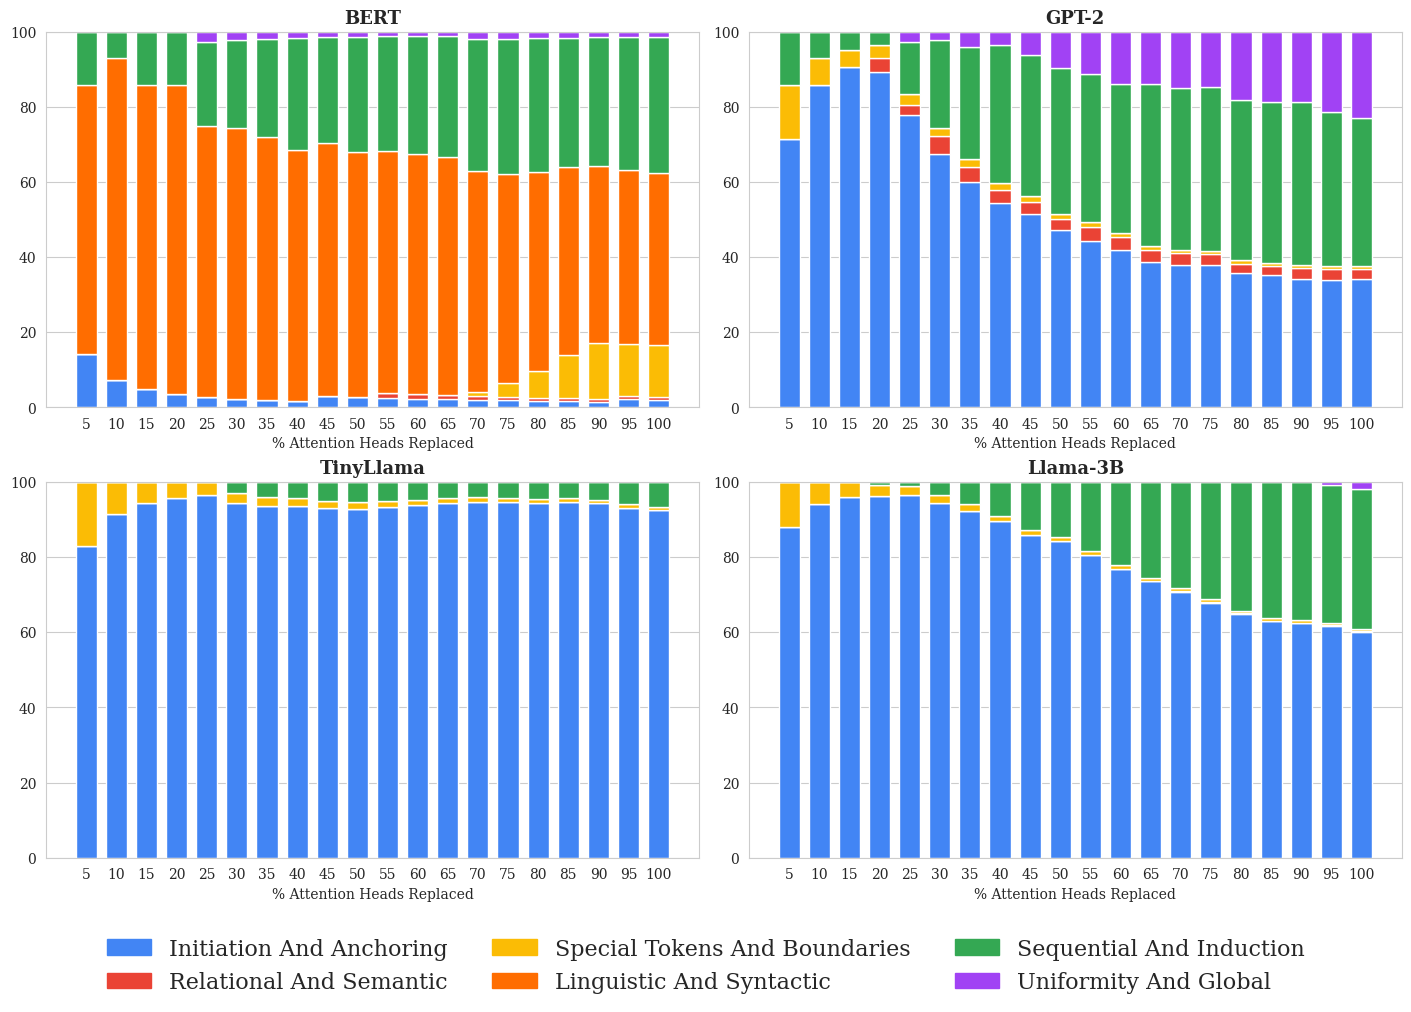

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#4285F4",
    "relational_and_semantic":       "#EA4335",
    "special_tokens_and_boundaries": "#FBBC05",
    "linguistic_and_syntactic":      "#FF6D00",
    "sequential_and_induction":      "#34A853",
    "uniformity_and_global":         "#A142F4",
}

with open("../results/program_categories.json", "r") as f:
    attention_head_categories = json.load(f)
PROGRAM_TO_CATEGORY = {}
for cat, programs in attention_head_categories.items():
    for prog in programs:
        PROGRAM_TO_CATEGORY[prog] = cat

HEAD_COUNTS = {
    "bert":      144,
    "gpt2":      144,
    "tinyllama": 704,
    "llama3b":   672,
}

REPLACEMENT_LEVELS = [round(x * 0.05, 2) for x in range(1, 21)]

FILES = {
    "BERT":       "../results/replacement_run/bert_smart.csv",
    "GPT-2":      "../results/replacement_run/gpt2_smart.csv",
    "TinyLlama":  "../results/replacement_run/tinyllama_smart.csv",
    "Llama-3B":   "../results/replacement_run/llama3b_smart.csv",
}

def get_category_counts_at_level(df, total_heads, pct):
    n = int(total_heads * pct)
    subset = df.sort_values("k").head(n)
    counts = {cat: 0 for cat in CATEGORY_COLORS}
    for prog in subset["program"]:
        cat = PROGRAM_TO_CATEGORY.get(prog, "uniformity_and_global")
        counts[cat] += 1
    return counts

plt.rcParams["font.family"] = "serif"
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
axes_flat = axes.flatten()

model_names = list(FILES.keys())
total_heads_map = {
    "BERT":      144,
    "GPT-2":     144,
    "TinyLlama": 704,
    "Llama-3B":  672,
}

for ax, model_name in zip(axes_flat, model_names):
    df = pd.read_csv(FILES[model_name])
    total = total_heads_map[model_name]
    cats = list(CATEGORY_COLORS.keys())
    x = [int(p * 100) for p in REPLACEMENT_LEVELS]
    
    bottoms = np.zeros(len(REPLACEMENT_LEVELS))
    for cat in cats:
        heights = []
        for pct in REPLACEMENT_LEVELS:
            counts = get_category_counts_at_level(df, total, pct)
            n_replaced = int(total * pct)
            heights.append(counts[cat] / n_replaced * 100 if n_replaced > 0 else 0)
        heights = np.array(heights)
        ax.bar(x, heights, bottom=bottoms,
               color=CATEGORY_COLORS[cat], width=3.5, label=cat)
        bottoms += heights

    ax.set_title(model_name, fontweight="bold", fontsize=13)
    ax.set_xlabel("% Attention Heads Replaced", fontsize=10)
    # ax.set_ylabel("% of Replaced Heads", fontsize=10)
    # ax.set_ylim(0, 100)
    ax.set_xticks(x)
    # ax.grid(axis="y", linestyle=":", alpha=0.4)

legend_patches = [
    mpatches.Patch(color=CATEGORY_COLORS[c],
                   label=c.replace("_", " ").title())
    for c in CATEGORY_COLORS
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=3, fontsize=16, frameon=False,
           bbox_to_anchor=(0.5, -0.12))

plt.savefig("figure_4_6.pdf", bbox_inches="tight")
plt.show()

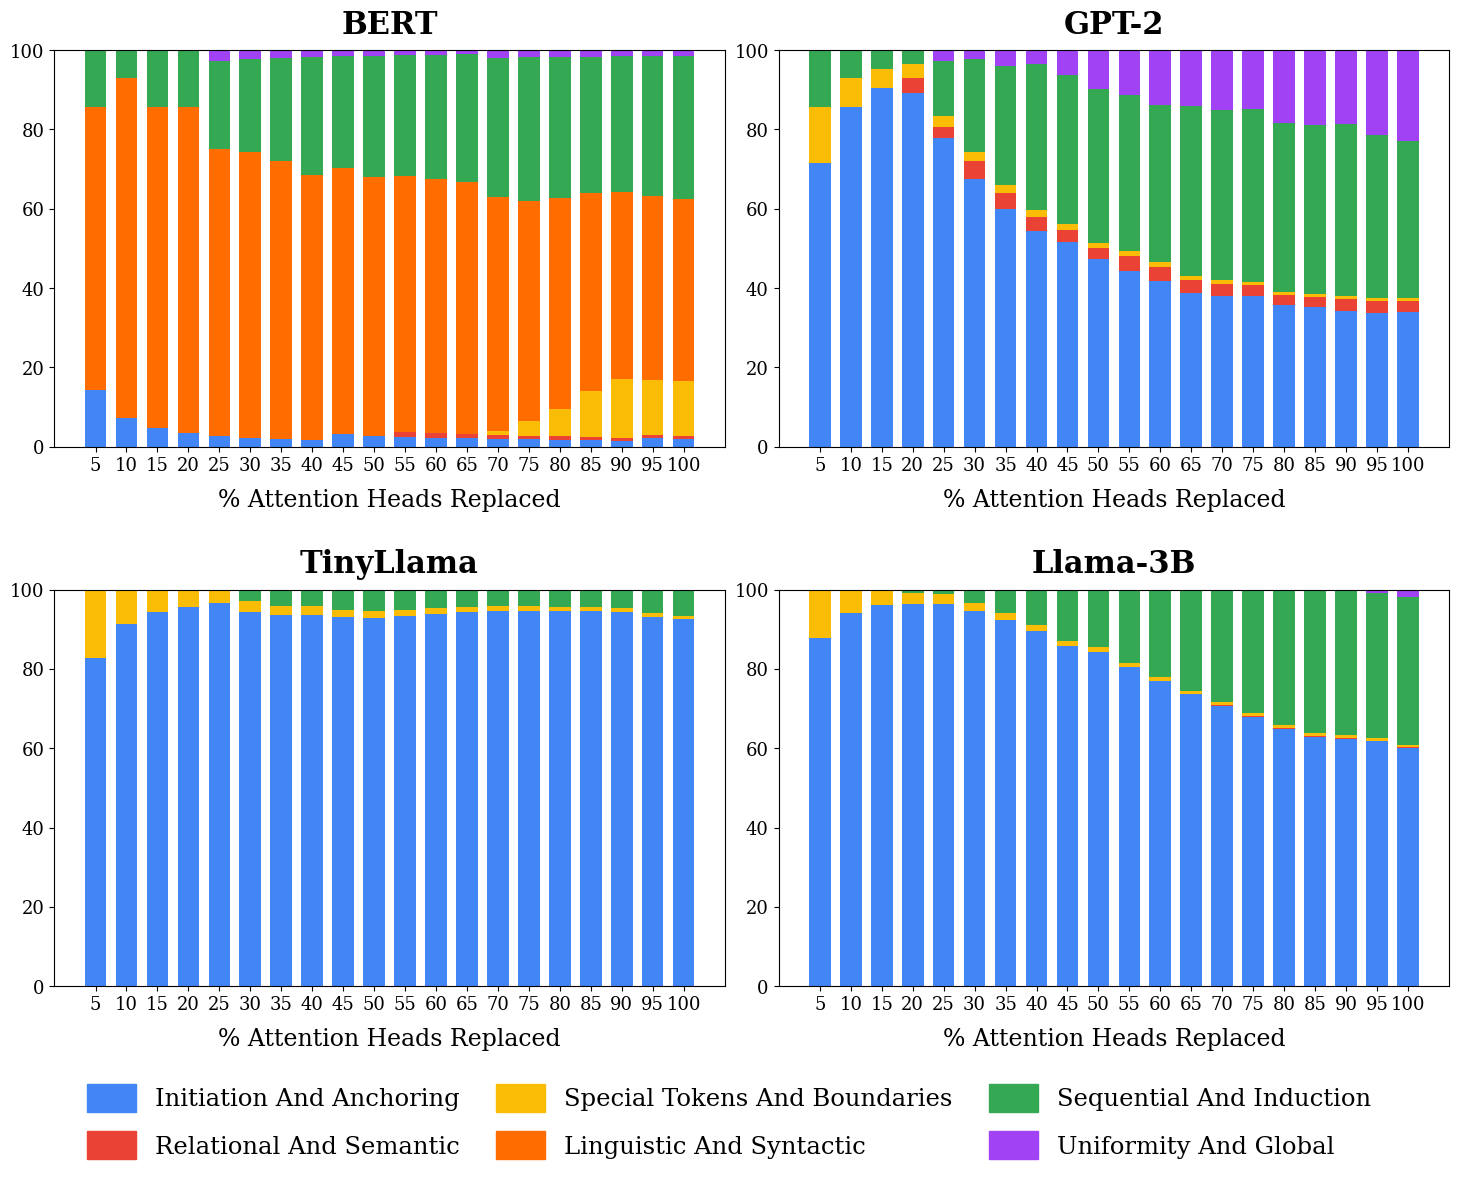

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import json

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#4285F4",
    "relational_and_semantic":       "#EA4335",
    "special_tokens_and_boundaries": "#FBBC05",
    "linguistic_and_syntactic":      "#FF6D00",
    "sequential_and_induction":      "#34A853",
    "uniformity_and_global":         "#A142F4",
}

with open("../results/program_categories.json", "r") as f:
    attention_head_categories = json.load(f)
PROGRAM_TO_CATEGORY = {}
for cat, programs in attention_head_categories.items():
    for prog in programs:
        PROGRAM_TO_CATEGORY[prog] = cat

HEAD_COUNTS = {
    "bert":      144,
    "gpt2":      144,
    "tinyllama": 704,
    "llama3b":   672,
}

REPLACEMENT_LEVELS = [round(x * 0.05, 2) for x in range(1, 21)]

FILES = {
    "BERT":       "../results/replacement_run/bert_smart.csv",
    "GPT-2":      "../results/replacement_run/gpt2_smart.csv",
    "TinyLlama":  "../results/replacement_run/tinyllama_smart.csv",
    "Llama-3B":   "../results/replacement_run/llama3b_smart.csv",
}

def get_category_counts_at_level(df, total_heads, pct):
    n = int(total_heads * pct)
    subset = df.sort_values("k").head(n)
    counts = {cat: 0 for cat in CATEGORY_COLORS}
    for prog in subset["program"]:
        cat = PROGRAM_TO_CATEGORY.get(prog, "uniformity_and_global")
        counts[cat] += 1
    return counts

plt.rcParams["font.family"] = "serif"
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.subplots_adjust(hspace=0.36, wspace=0.08, bottom=0.16)

model_names = list(FILES.keys())
total_heads_map = {
    "BERT":      144,
    "GPT-2":     144,
    "TinyLlama": 704,
    "Llama-3B":  672,
}

for ax, model_name in zip(axes.flatten(), model_names):
    df = pd.read_csv(FILES[model_name])
    total = total_heads_map[model_name]
    cats = list(CATEGORY_COLORS.keys())
    x = [int(p * 100) for p in REPLACEMENT_LEVELS]

    bottoms = np.zeros(len(REPLACEMENT_LEVELS))
    for cat in cats:
        heights = []
        for pct in REPLACEMENT_LEVELS:
            counts = get_category_counts_at_level(df, total, pct)
            n_replaced = int(total * pct)
            heights.append(counts[cat] / n_replaced * 100 if n_replaced > 0 else 0)
        heights = np.array(heights)
        ax.bar(x, heights, bottom=bottoms,
               color=CATEGORY_COLORS[cat], width=3.5, label=cat)
        bottoms += heights

    ax.set_title(model_name, fontweight="bold", fontsize=22, pad=12)
    ax.set_xlabel("% Attention Heads Replaced", fontsize=17, labelpad=10)
    ax.set_xticks(x)
    ax.tick_params(axis="both", labelsize=13)

legend_patches = [
    mpatches.Patch(color=CATEGORY_COLORS[c],
                   label=c.replace("_", " ").title())
    for c in CATEGORY_COLORS
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=3, fontsize=17.5, frameon=False,
           bbox_to_anchor=(0.5, 0.01),
           handleheight=1.4, handlelength=2.0,
           labelspacing=0.8, columnspacing=1.5)

plt.savefig("figure_4_6_flat.pdf", bbox_inches="tight")
plt.show()

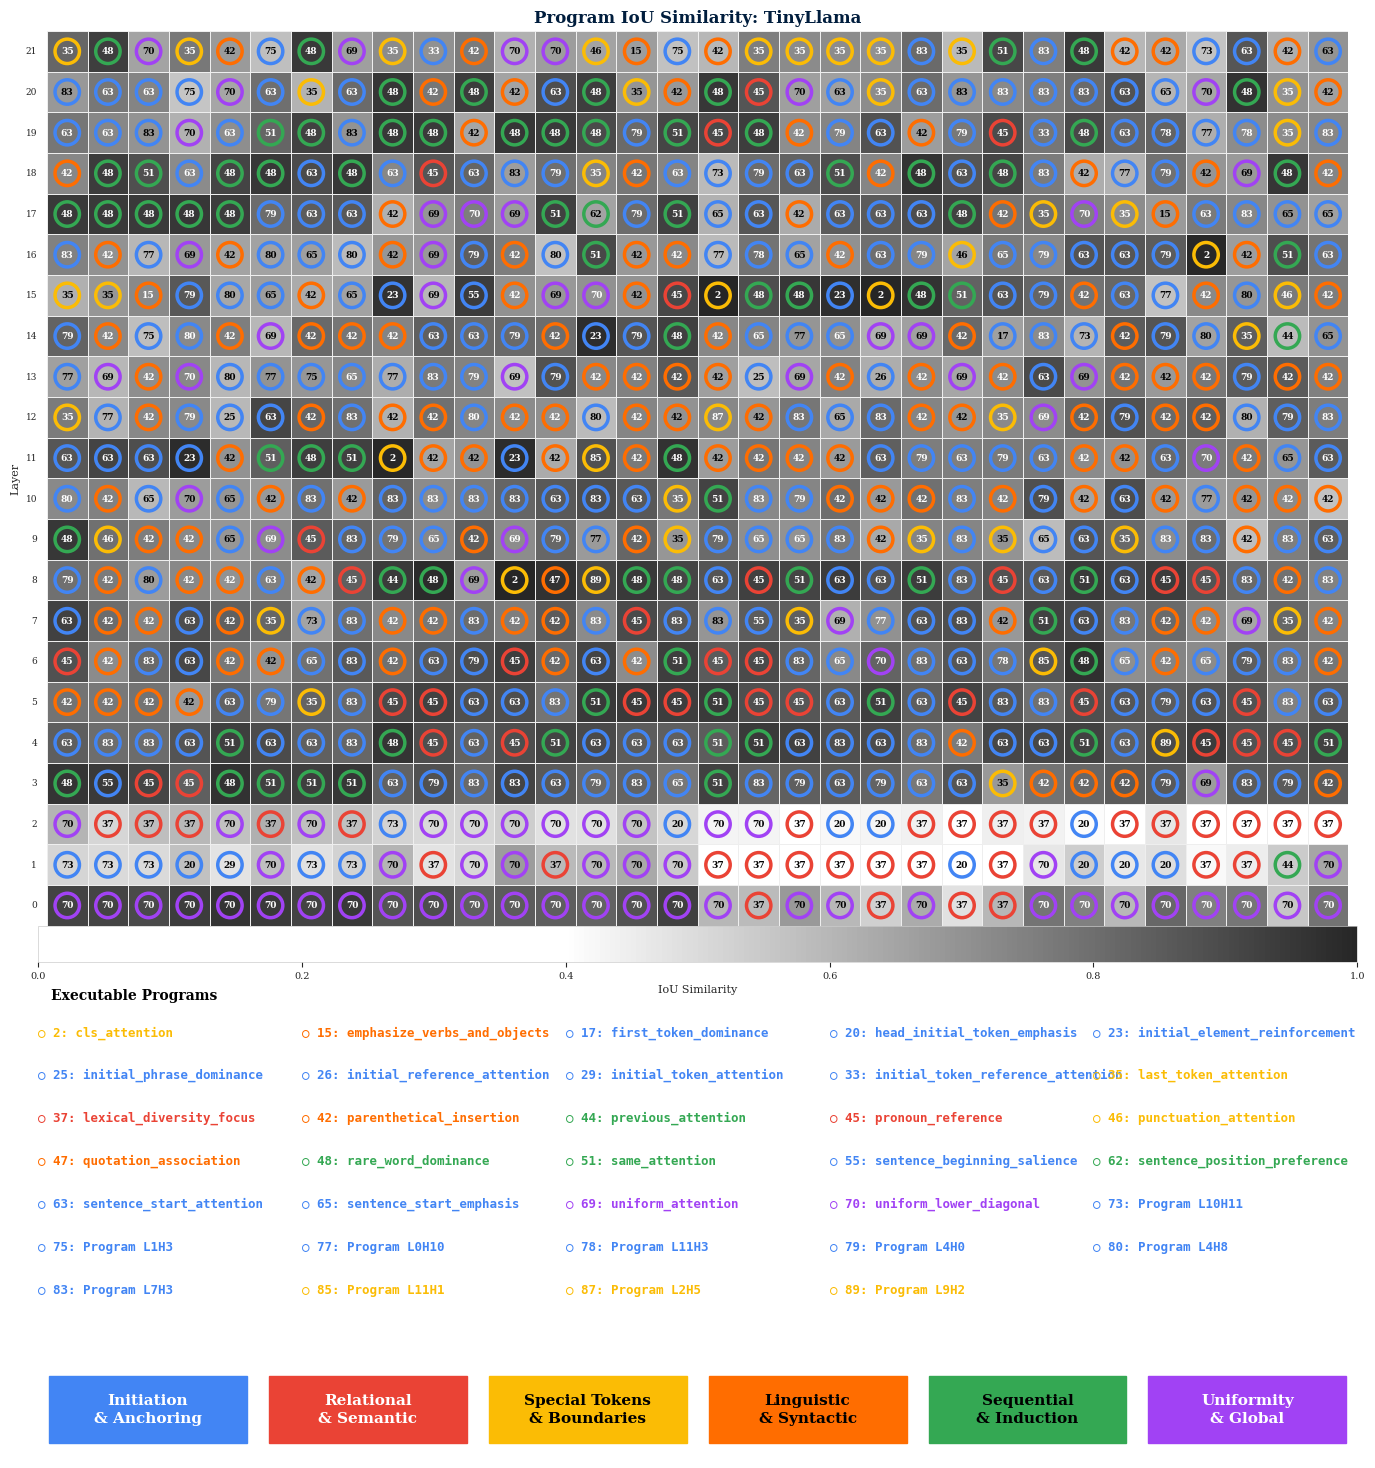

Saved → ../results/plots/figure_4_2/figure_4_2.pdf


In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import os

# ── Colormap ──
colors = [(1, 1, 1), (1, 1, 1), (0.15, 0.15, 0.15)]
nodes  = [0.0, 0.4, 1.0]
standard_prec_map = mcolors.LinearSegmentedColormap.from_list("custom_gray", list(zip(nodes, colors)))

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#4285F4",
    "relational_and_semantic":       "#EA4335",
    "special_tokens_and_boundaries": "#FBBC05",
    "linguistic_and_syntactic":      "#FF6D00",
    "sequential_and_induction":      "#34A853",
    "uniformity_and_global":         "#A142F4",
}

def get_name_to_category(categories):
    return {m: cat for cat, members in categories.items() for m in members}

def get_text_color(hex_color):
    rgb = mcolors.to_rgb(hex_color)
    luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
    return 'black' if luminance > 0.5 else 'white'

# ── Build matrix ──
def _build_matrix(best_fits, n_layers, n_heads):
    data = np.zeros((n_layers, n_heads))
    for layer, head, name, score in best_fits:
        if score is not None and layer < n_layers and head < n_heads:
            data[layer, head] = float(score)
    return data

def _ordered_fits(best_fits, n_layers, n_heads):
    grid = {}
    for layer, head, name, score in best_fits:
        grid[(layer, head)] = (name, score)
    result = []
    for l in range(n_layers):
        for h in range(n_heads):
            name, score = grid.get((l, h), (None, 0.0))
            result.append((h, name, score))
    return result

import re
def clean_program_name(name):
    """If name ends in _L#H# or similar, replace with 'Program L#H#'."""
    m = re.search(r'(L\d+H\d+)$', name, re.IGNORECASE)
    if m:
        return f"Program {m.group(1)}"
    return name

N_LAYERS, N_HEADS = 22, 32
tinyllama_data         = _build_matrix(best_fits_tinyllama, N_LAYERS, N_HEADS)
best_fits_tl_ordered   = _ordered_fits(best_fits_tinyllama, N_LAYERS, N_HEADS)
all_names              = [func.__name__ for func in all_programs]
name_to_cat            = get_name_to_category(attention_head_categories)

# ── Layout ──
# Heatmap cell size in inches
# CELL = 0.38
# hm_w = N_HEADS * CELL + 1.2
# hm_h = N_LAYERS * CELL + 0.8

# wider, slightly shorter cell
CELL = 0.38
hm_w = N_HEADS * CELL + 2.5   # was +1.2
hm_h = N_LAYERS * CELL + 0.4  # was +0.8
LEG_COLS = 5

# Estimate legend rows
appeared_names    = sorted({name for _, name, _ in best_fits_tl_ordered if name}, key=lambda n: all_names.index(n))
filtered_programs = [(all_names.index(n), n) for n in appeared_names]
# LEG_COLS = 4
leg_rows  = int(np.ceil(len(filtered_programs) / LEG_COLS))
# leg_h     = max(1.2, leg_rows * 0.32 + 0.6)
# Replace leg_h calculation
leg_h = max(1.5, leg_rows * 0.38 + 1.2)   # more space for title + items

cat_h    = 1.0
cbar_h   = 0.35
pad      = 0.15

total_h  = hm_h + cbar_h + leg_h + cat_h + pad * 4
fig = plt.figure(figsize=(hm_w, total_h))

height_ratios = [hm_h, cbar_h, leg_h, cat_h]
gs = gridspec.GridSpec(4, 1, figure=fig,
                       height_ratios=height_ratios,
                       hspace=0.0,
                       left=0.07, right=0.97,
                       top=1 - pad/total_h,
                       bottom=pad/total_h)

# ── 1. Heatmap ──
ax_hm = fig.add_subplot(gs[0])
reversed_data = tinyllama_data[::-1]
sns.heatmap(reversed_data, ax=ax_hm, cmap=standard_prec_map, cbar=False,
            linewidths=0.4, linecolor='#EEEEEE', vmin=0, vmax=1, square=True)

for i, (head_id, name, score) in enumerate(best_fits_tl_ordered):
    if not name: continue
    layer_val = i // N_HEADS
    x         = i % N_HEADS
    y_pos     = (N_LAYERS - 1) - layer_val
    cell_val  = tinyllama_data[layer_val, x]
    cat       = name_to_cat.get(name)
    color     = CATEGORY_COLORS.get(cat, "#333333")
    text_color = "white" if cell_val > 0.7 else "black"
    legend_idx = all_names.index(name) if name in all_names else head_id
    ax_hm.add_patch(plt.Circle((x + 0.5, y_pos + 0.5), radius=0.3,
                                facecolor='none', edgecolor=color,
                                linewidth=2.5, zorder=3))
    ax_hm.text(x + 0.5, y_pos + 0.5, str(legend_idx),
               ha='center', va='center', color=text_color,
               fontweight='bold', fontsize=6.5, zorder=4)

ax_hm.set_title("Program IoU Similarity: TinyLlama", fontweight='bold', fontsize=12,
                color='#001D3D', pad=6)
ax_hm.set_yticklabels(range(N_LAYERS - 1, -1, -1), rotation=0, fontsize=6.5)
ax_hm.set_xticklabels(range(N_HEADS), fontsize=6.5)
ax_hm.set_xlabel("Head", fontsize=8, labelpad=4)
ax_hm.set_ylabel("Layer", fontsize=8)

# ── 2. Colorbar ──
ax_cb = fig.add_subplot(gs[1])
norm  = mcolors.Normalize(vmin=0, vmax=1)
cb    = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=standard_prec_map),
                     cax=ax_cb, orientation='horizontal')
cb.outline.set_linewidth(0.5)
cb.ax.tick_params(labelsize=7)
cb.set_label("IoU Similarity", fontsize=8, labelpad=3)

# ── 3. Program legend ──
ax_leg = fig.add_subplot(gs[2])
ax_leg.axis('off')
ax_leg.text(0.01, 0.93, "Executable Programs",        # lower anchor (was 0.97)
            fontweight='bold', fontsize=10, color='black',
            transform=ax_leg.transAxes, va='top')

col_w = 1.0 / LEG_COLS
row_h = 1.0 / (leg_rows + 2.2)                        # +2.2 reserves space for title

for i, (original_idx, name) in enumerate(filtered_programs):
    col = i % LEG_COLS
    row = i // LEG_COLS
    x   = col * col_w
    y   = 0.82 - row * row_h
    cat   = name_to_cat.get(name)
    color = CATEGORY_COLORS.get(cat, "#333333")
    display = clean_program_name(name)                  # <--
    ax_leg.text(x, y, f"○ {original_idx}: {display}",
                color=color, fontsize=9, fontfamily='monospace',
                fontweight='bold',
                transform=ax_leg.transAxes, va='center')

# ── 4. Category color boxes ──
ax_cat = fig.add_subplot(gs[3])
ax_cat.axis('off')

n_cats = len(CATEGORY_COLORS)
box_w  = 1.0 / n_cats
margin = 0.05

for i, (group, color) in enumerate(CATEGORY_COLORS.items()):
    x0 = i * box_w + margin * box_w
    w  = box_w * (1 - 2 * margin)
    rect = mpatches.Rectangle(
        (x0, 0.15), w, 0.65,
        color=color, transform=ax_cat.transAxes, clip_on=False
    )
    ax_cat.add_patch(rect)
    clean = group.replace('_', ' ').title().replace(' And', '\n&')
    ax_cat.text(x0 + w / 2, 0.15 + 0.65 / 2, clean,
                color=get_text_color(color), ha='center', va='center',
                fontweight='bold', fontsize=11,             # was 7.5
                transform=ax_cat.transAxes, linespacing=1.4)

os.makedirs("../results/plots/figure_4_2", exist_ok=True)
out = "../results/plots/figure_4_2/figure_4_2.pdf"
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {out}")

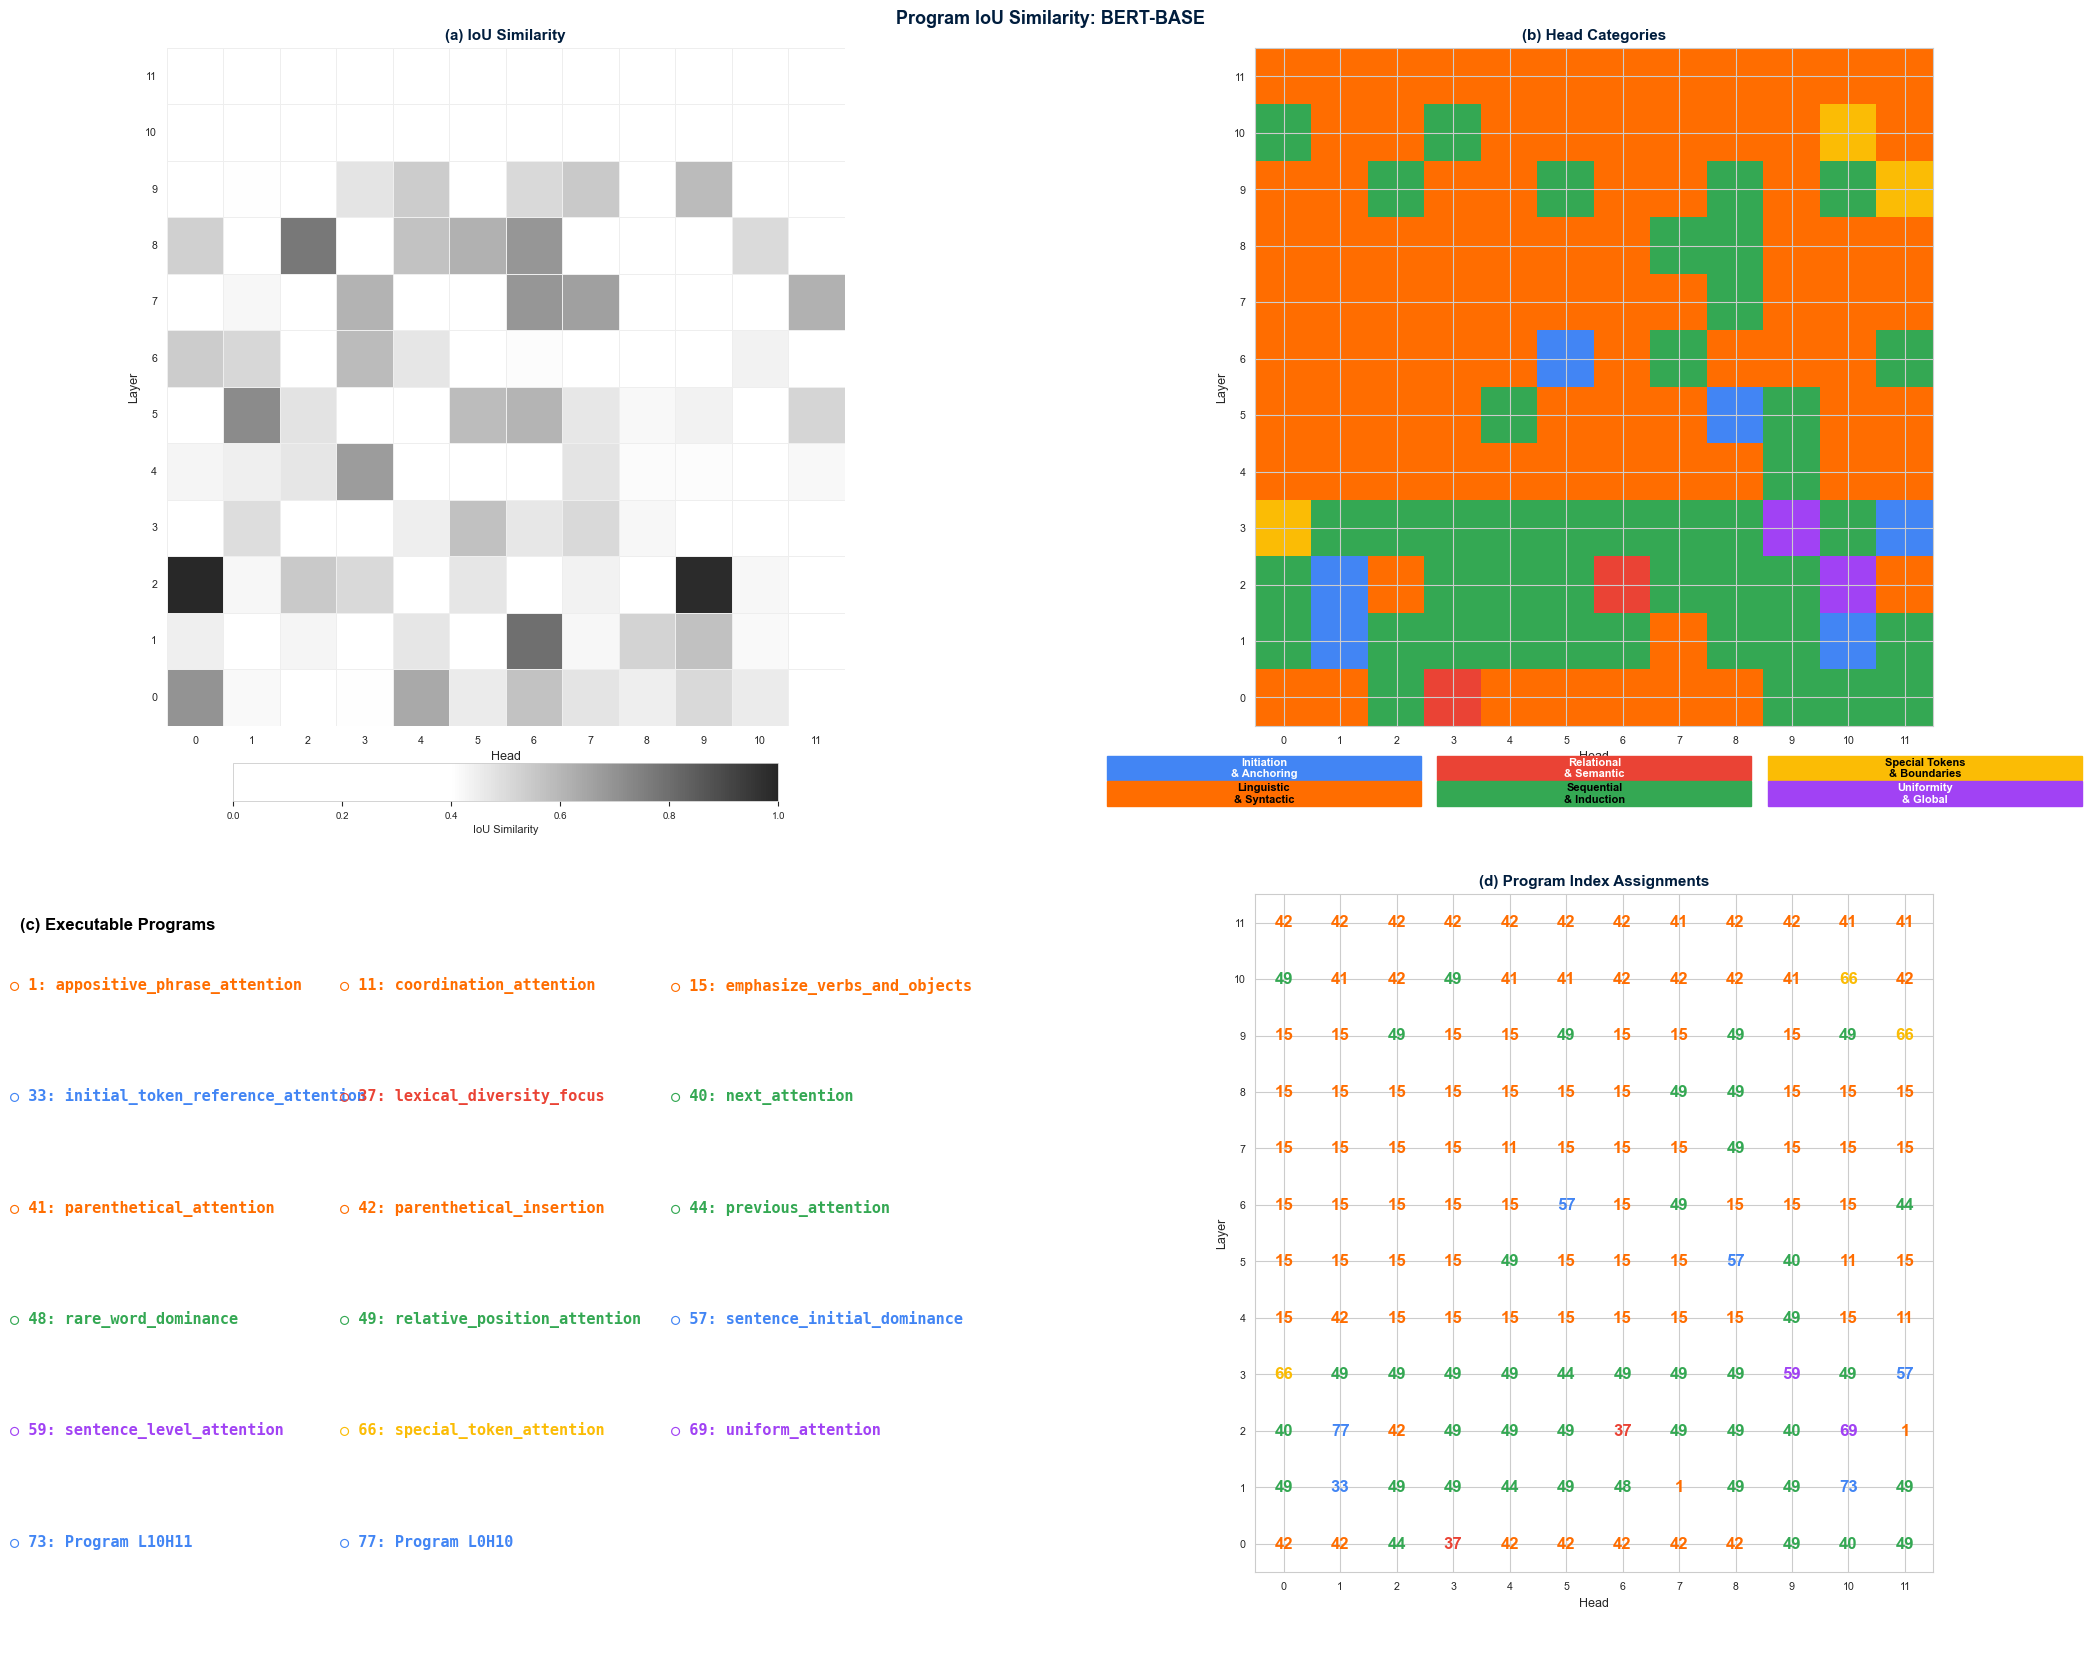

Saved → ../results/plots/figure_4_2/figure_4_2_bert_2x2.pdf


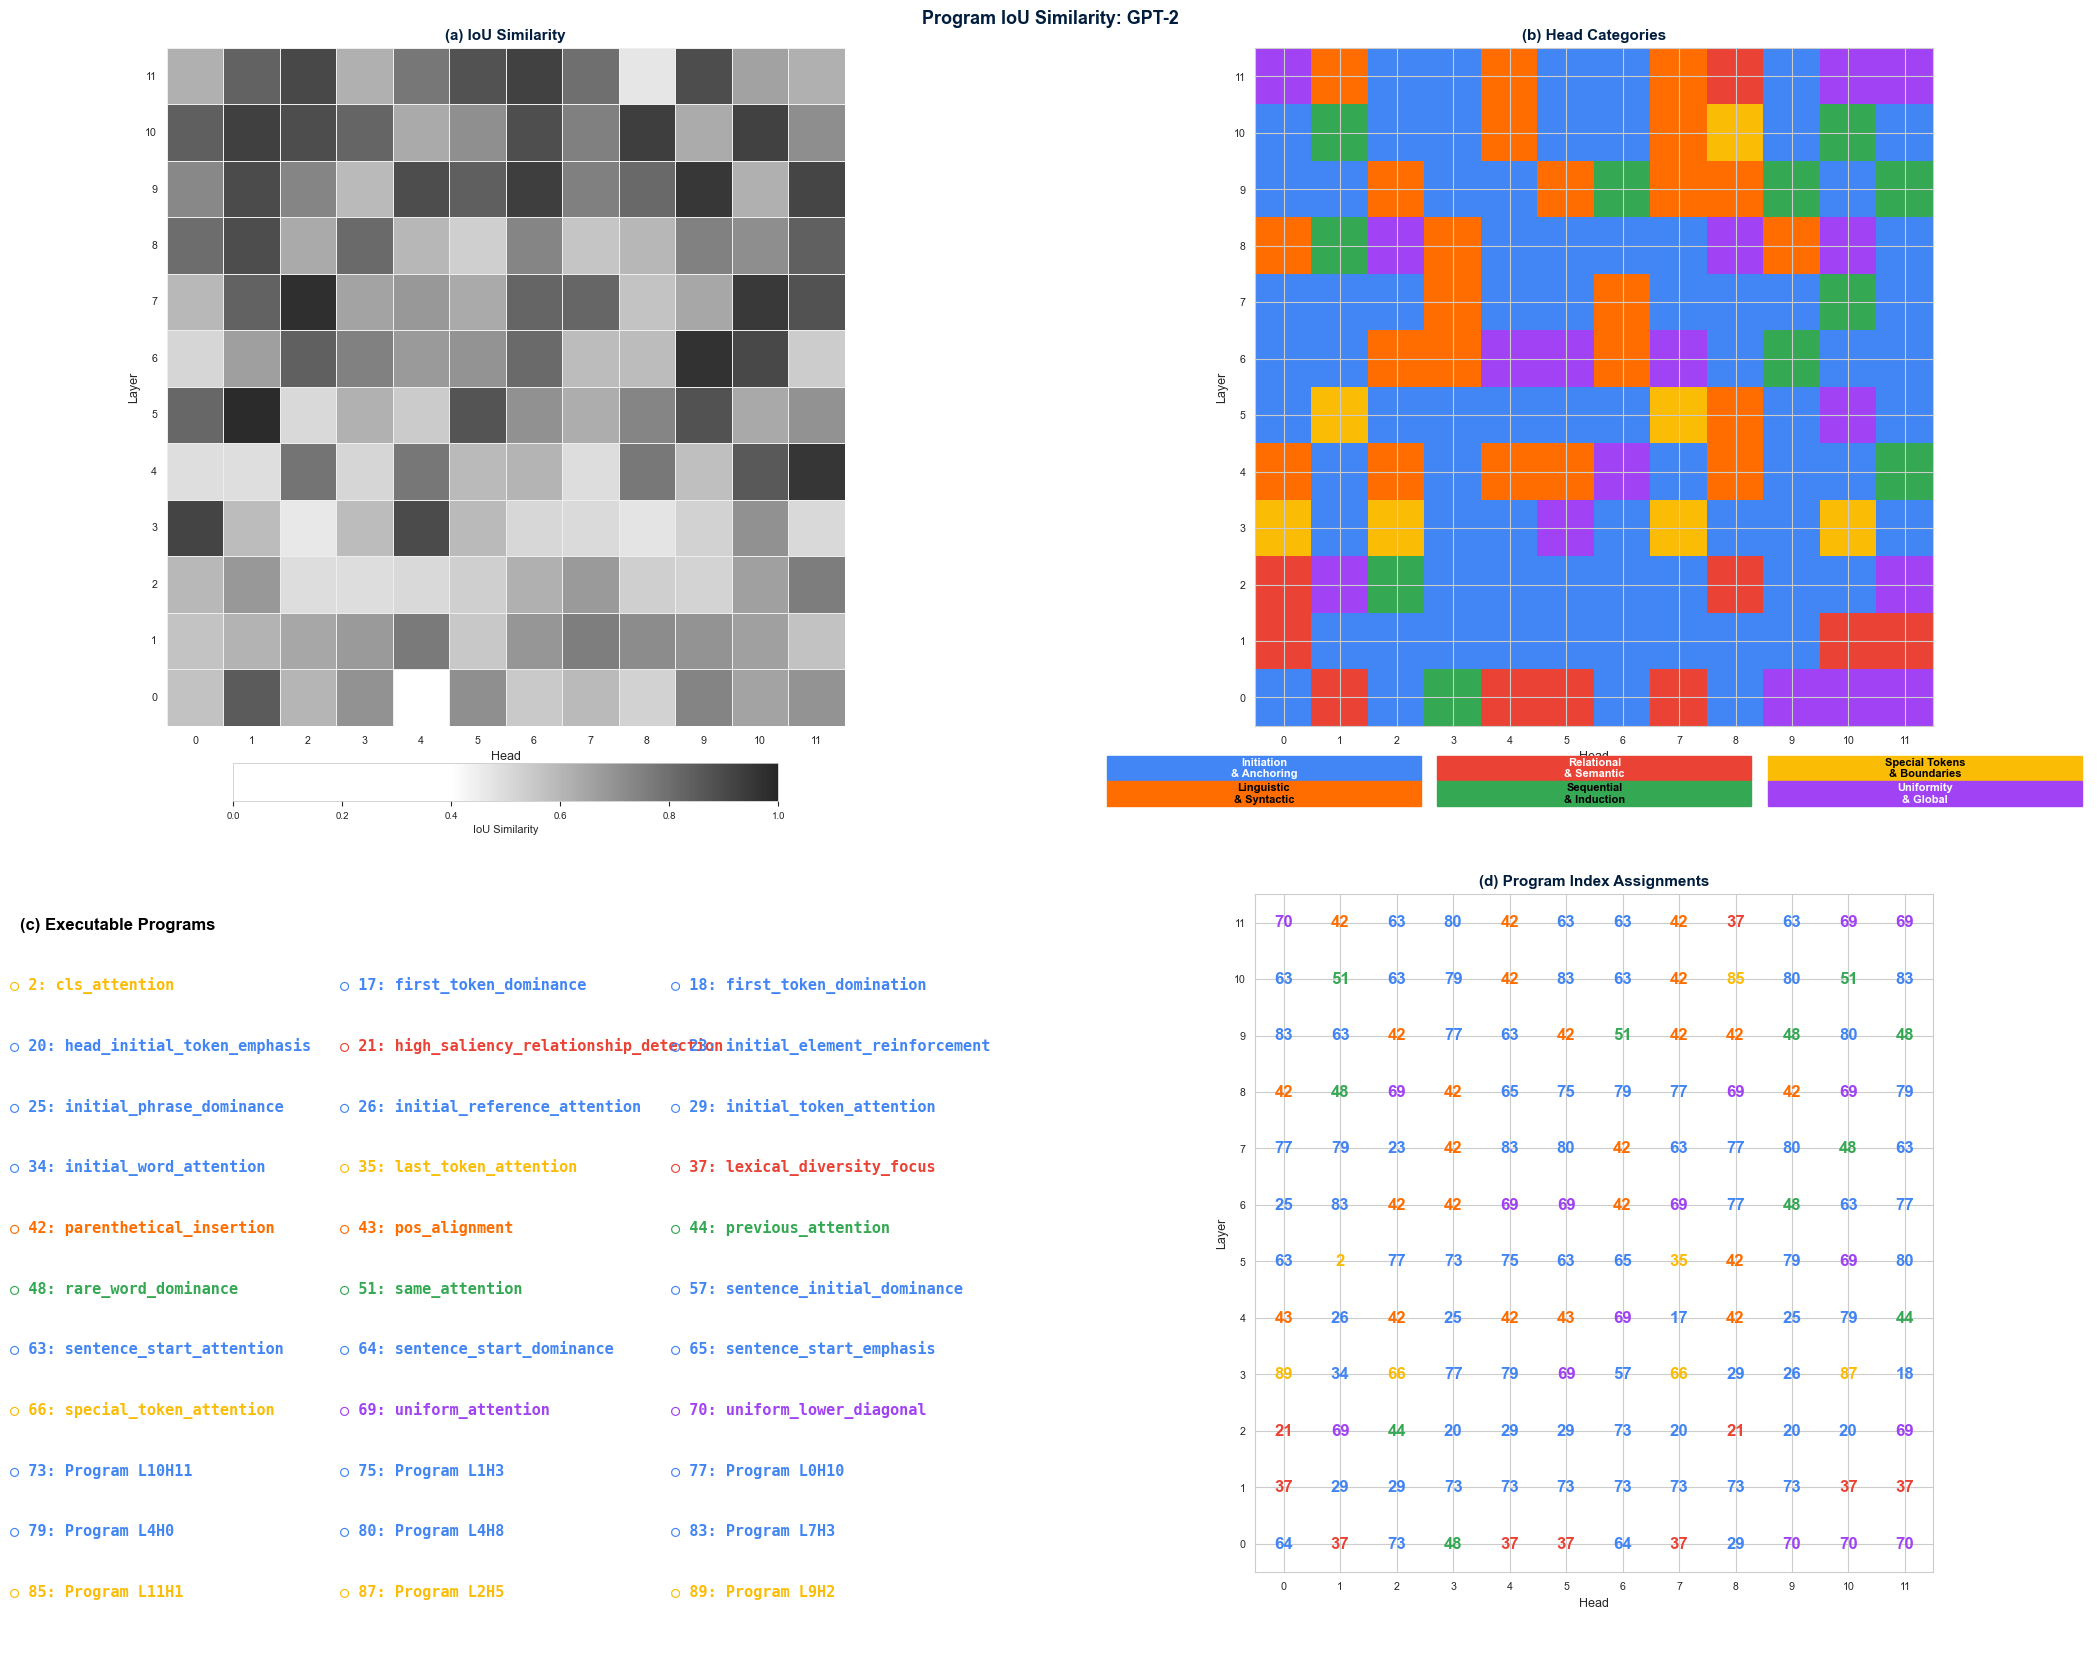

Saved → ../results/plots/figure_4_2/figure_4_2_gpt2_2x2.pdf


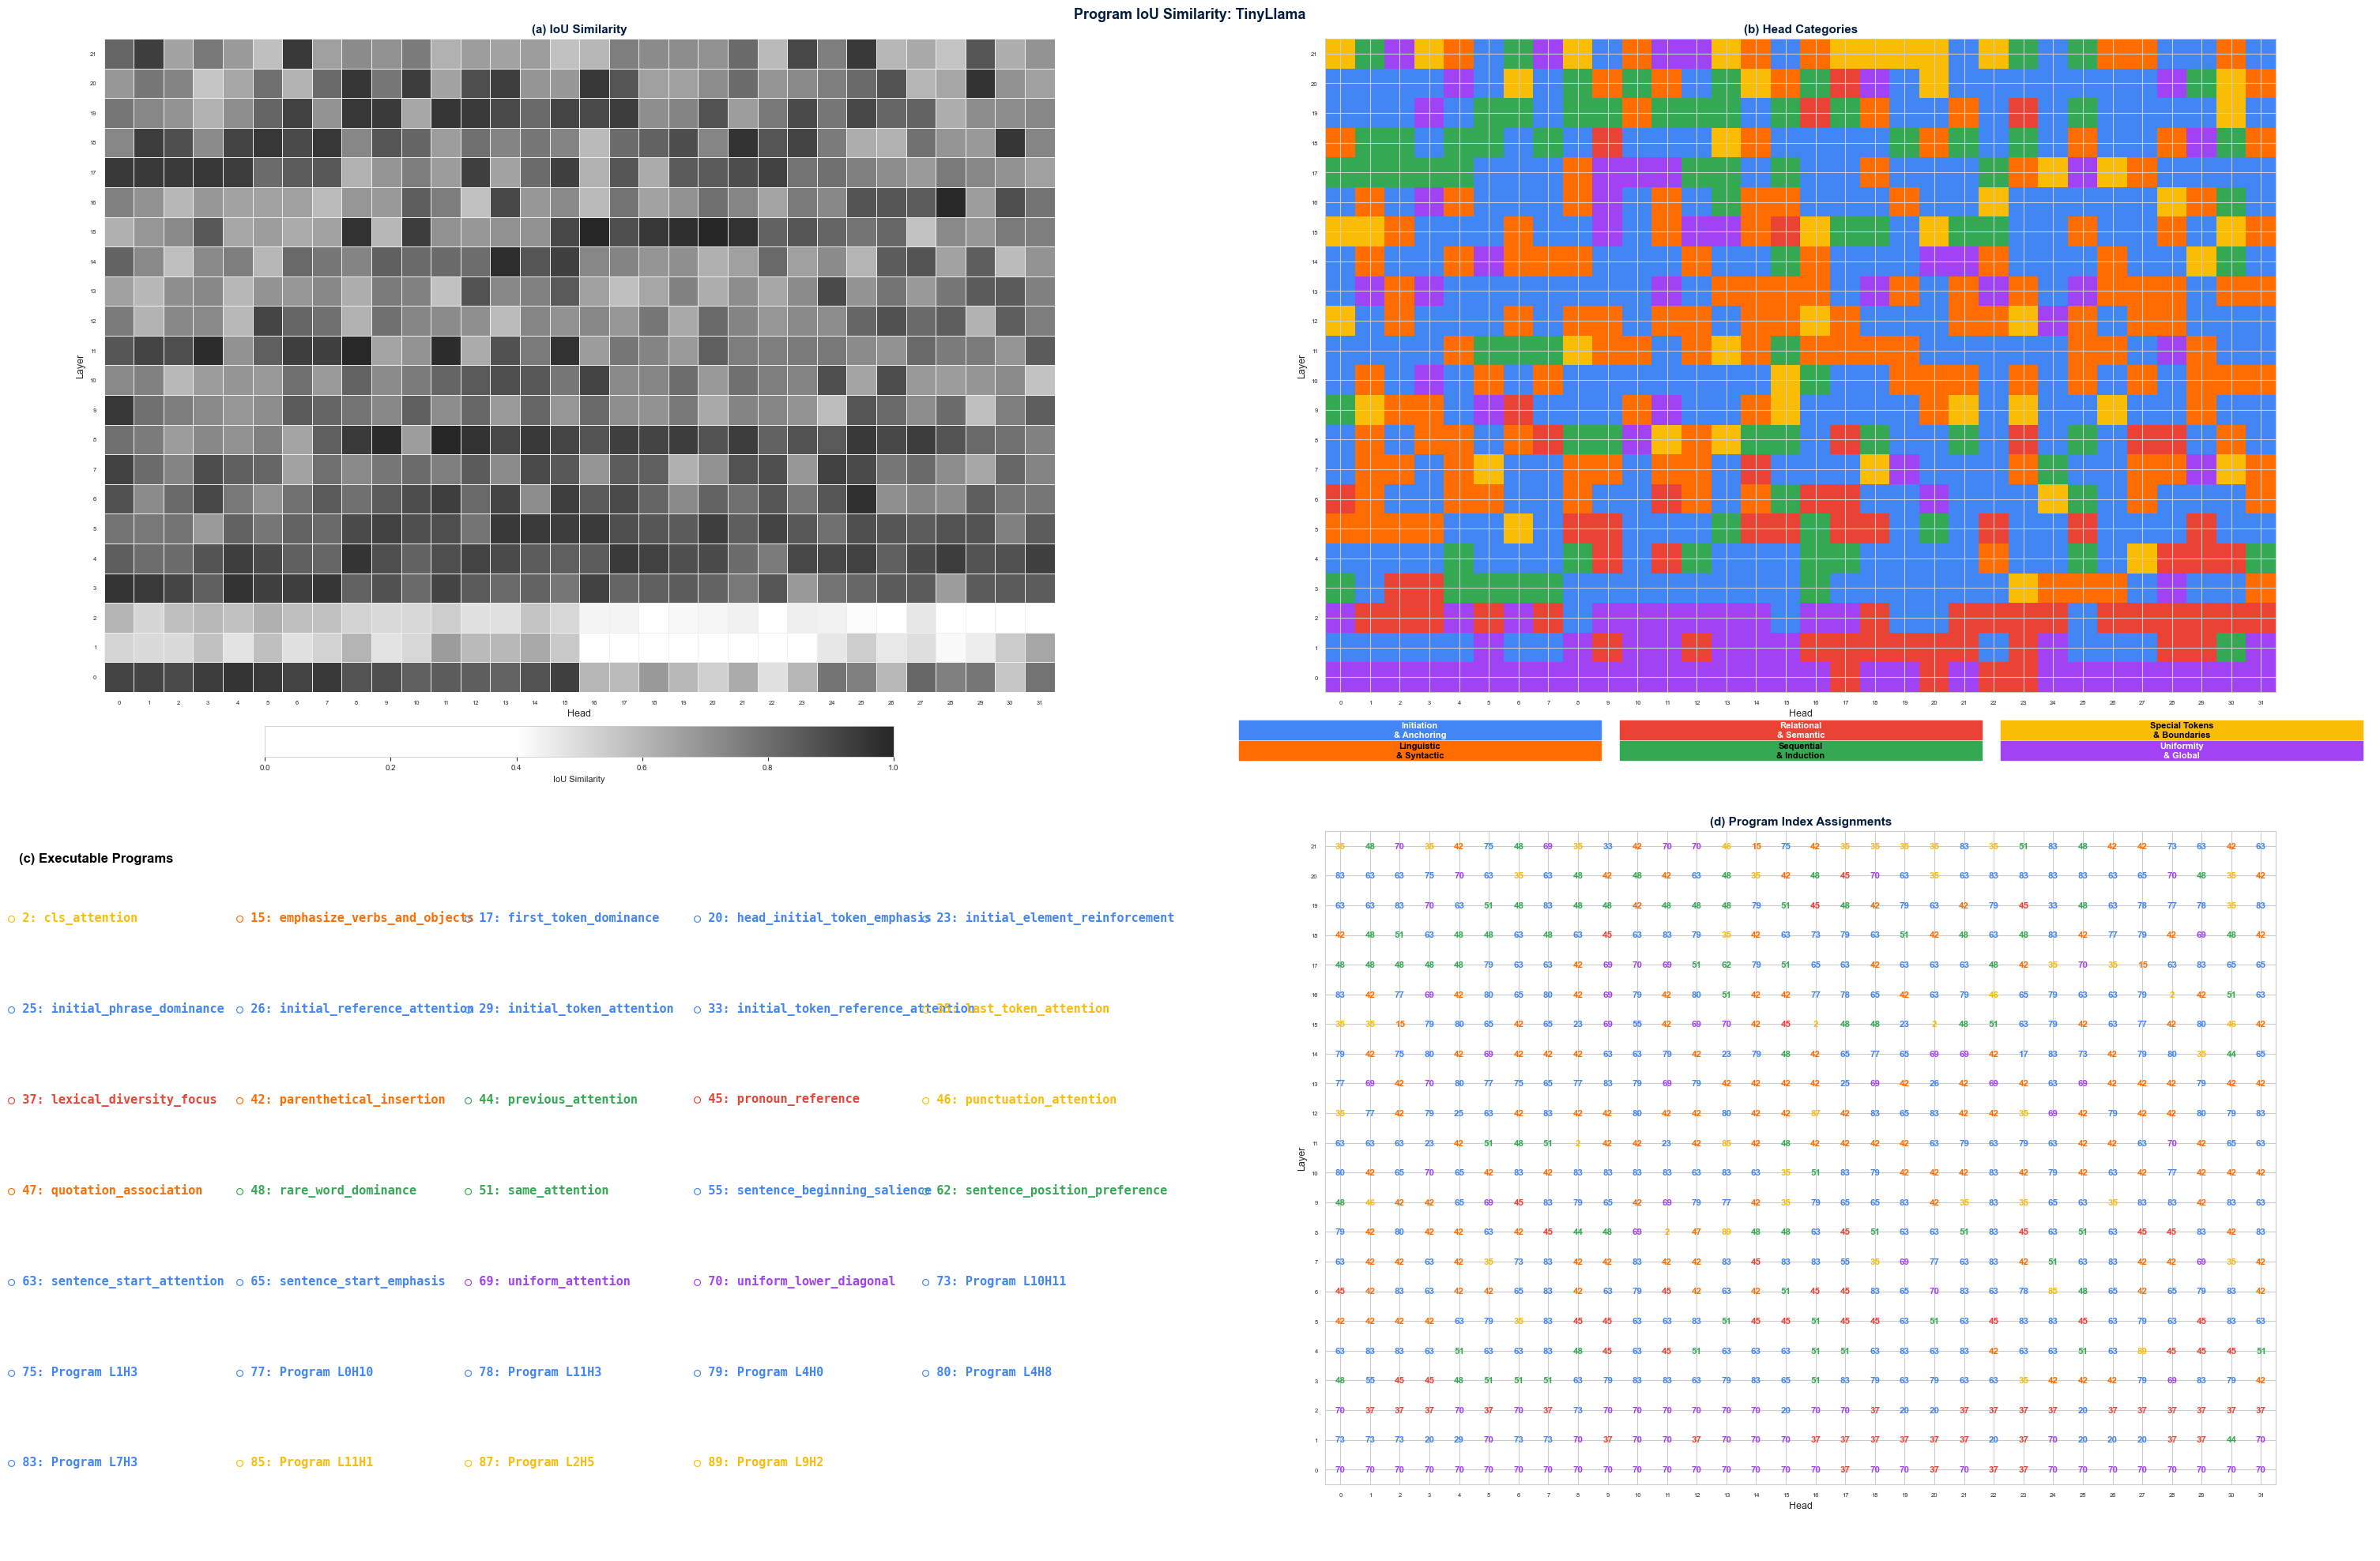

Saved → ../results/plots/figure_4_2/figure_4_2_tinyllama_2x2.pdf


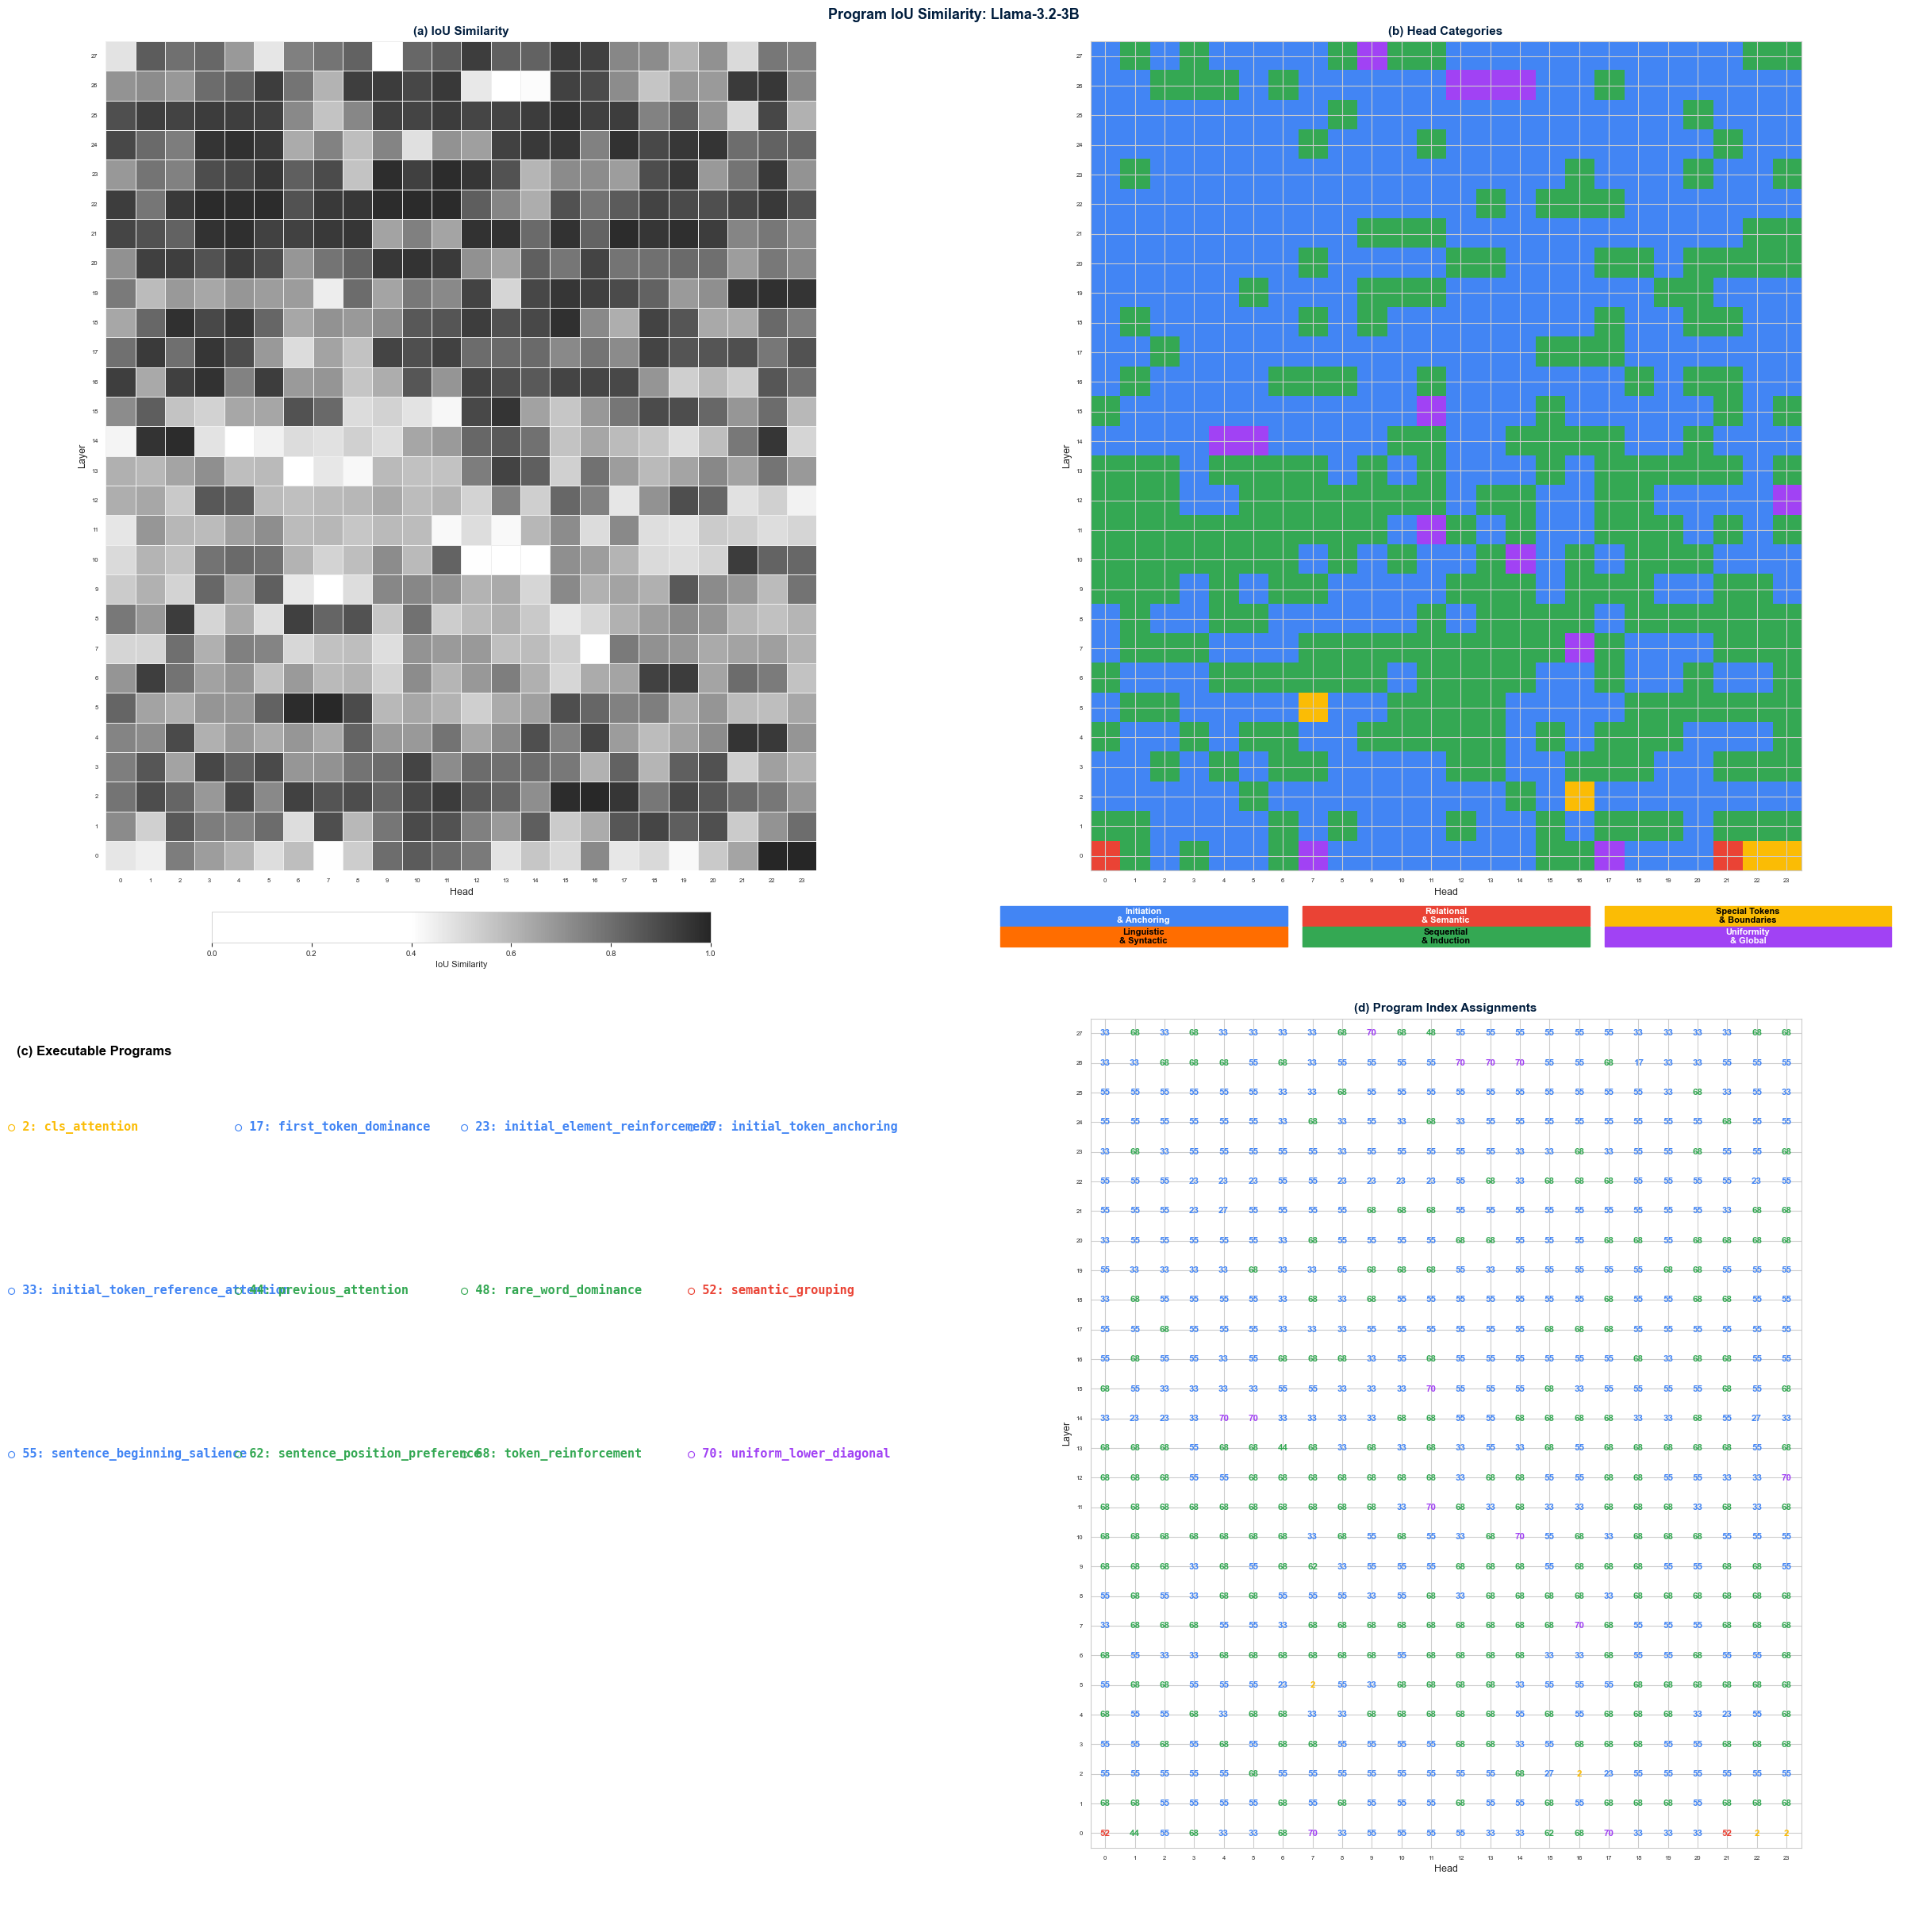

Saved → ../results/plots/figure_4_2/figure_4_2_llama3b_2x2.pdf


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import os
import re

# ── Colormap ──────────────────────────────────────────────────────────────────
colors_map = [(1, 1, 1), (1, 1, 1), (0.15, 0.15, 0.15)]
nodes      = [0.0, 0.4, 1.0]
standard_prec_map = mcolors.LinearSegmentedColormap.from_list(
    "custom_gray", list(zip(nodes, colors_map)))

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#4285F4",
    "relational_and_semantic":       "#EA4335",
    "special_tokens_and_boundaries": "#FBBC05",
    "linguistic_and_syntactic":      "#FF6D00",
    "sequential_and_induction":      "#34A853",
    "uniformity_and_global":         "#A142F4",
}

DISPLAY_CONFIG = {
    "bert":      dict(cell=0.55, w_pad=3.5, h_pad=0.6, leg_cols=3, leg_row_h=0.45),
    "gpt2":      dict(cell=0.55, w_pad=3.5, h_pad=0.6, leg_cols=3, leg_row_h=0.45),
    "tinyllama": dict(cell=0.38, w_pad=2.5, h_pad=0.4, leg_cols=5, leg_row_h=0.38),
    "llama3b":   dict(cell=0.38, w_pad=2.5, h_pad=0.4, leg_cols=4, leg_row_h=0.38),
}


def get_name_to_category(categories):
    return {m: cat for cat, members in categories.items() for m in members}

def get_text_color(hex_color):
    rgb = mcolors.to_rgb(hex_color)
    lum = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
    return 'black' if lum > 0.5 else 'white'

def clean_program_name(name):
    m = re.search(r'(L\d+H\d+)$', name, re.IGNORECASE)
    return f"Program {m.group(1)}" if m else name

def _build_matrix(best_fits, n_layers, n_heads):
    data = np.zeros((n_layers, n_heads))
    for layer, head, name, score in best_fits:
        if score is not None and layer < n_layers and head < n_heads:
            data[layer, head] = float(score)
    return data

def _ordered_fits(best_fits, n_layers, n_heads):
    grid = {(layer, head): (name, score) for layer, head, name, score in best_fits}
    return [(h, *grid.get((l, h), (None, 0.0)))
            for l in range(n_layers) for h in range(n_heads)]

def _setup_imshow_ax(ax, rgba, n_layers, n_heads, tick_fs):
    """imshow with shared axis formatting; no gridlines."""
    ax.imshow(rgba, aspect='equal', interpolation='none')
    ax.set_xlim(-0.5, n_heads - 0.5)
    ax.set_ylim(n_layers - 0.5, -0.5)
    ax.set_xticks(range(n_heads))
    ax.set_xticklabels(range(n_heads), fontsize=tick_fs)
    ax.set_yticks(range(n_layers))
    ax.set_yticklabels(range(n_layers - 1, -1, -1), rotation=0, fontsize=tick_fs)
    ax.set_xlabel("Head", fontsize=9, labelpad=4)
    ax.set_ylabel("Layer", fontsize=9)


def save_model_heatmap_2x2(
    best_fits, all_programs, categories,
    n_layers, n_heads, title, out_path, cfg,
):
    cell      = cfg["cell"]
    w_pad     = cfg["w_pad"]
    h_pad     = cfg["h_pad"]
    leg_cols  = cfg["leg_cols"]
    leg_row_h = cfg["leg_row_h"]

    all_names    = [func.__name__ for func in all_programs]
    name_to_cat  = get_name_to_category(categories)
    data         = _build_matrix(best_fits, n_layers, n_heads)
    ordered_fits = _ordered_fits(best_fits, n_layers, n_heads)

    appeared_names    = sorted(
        {name for _, name, _ in ordered_fits if name},
        key=lambda n: all_names.index(n))
    filtered_programs = [(all_names.index(n), n) for n in appeared_names]
    leg_rows = int(np.ceil(len(filtered_programs) / leg_cols))

    # ── Geometry ──────────────────────────────────────────────────────────────
    hm_w   = n_heads * cell + w_pad
    hm_h   = n_layers * cell + h_pad
    # Shared strip height below each top heatmap (colorbar left / category legend right).
    # Kept deliberately compact; the colorbar itself is further shrunk inside this space.
    strip_h = 0.55

    leg_h   = max(2.0, leg_rows * leg_row_h + 1.5)
    top_h   = hm_h + strip_h
    bot_h   = max(leg_h, hm_h + strip_h)
    gap     = 0.55
    h_gap   = 0.60
    margin  = 0.30
    fig_w   = hm_w * 2 + h_gap + margin * 2
    fig_h   = top_h + bot_h + gap + margin * 2

    fig = plt.figure(figsize=(fig_w, fig_h))
    fig.suptitle(title, fontweight='bold', fontsize=13, color='#001D3D', y=1.005)

    gs_main = gridspec.GridSpec(
        2, 2, figure=fig,
        height_ratios=[top_h, bot_h],
        hspace=gap / fig_h * 3.5,
        wspace=h_gap / fig_w * 3.5,
        left=margin / fig_w,
        right=1 - margin / fig_w,
        top=1 - margin / fig_h,
        bottom=margin / fig_h,
    )

    tick_fs = max(5.5, cell * 14)
    # BR number size: fill most of the cell
    num_fs  = max(7.5, cell * 22)
    norm    = mcolors.Normalize(vmin=0, vmax=1)

    # ── (a) TOP LEFT: pure grayscale IoU heatmap ─────────────────────────────
    gs_tl    = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=gs_main[0, 0],
        height_ratios=[hm_h, strip_h], hspace=0.08)
    ax_tl    = fig.add_subplot(gs_tl[0])
    ax_cb_tl = fig.add_subplot(gs_tl[1])

    sns.heatmap(data[::-1], ax=ax_tl, cmap=standard_prec_map, cbar=False,
                linewidths=0.4, linecolor='#EEEEEE', vmin=0, vmax=1, square=True)
    ax_tl.set_yticklabels(range(n_layers - 1, -1, -1), rotation=0, fontsize=tick_fs)
    ax_tl.set_xticklabels(range(n_heads), fontsize=tick_fs)
    ax_tl.set_xlabel("Head", fontsize=9, labelpad=4)
    ax_tl.set_ylabel("Layer", fontsize=9)
    ax_tl.set_title("(a) IoU Similarity", fontweight='bold',
                    fontsize=11, color='#001D3D', pad=6)

    # Colorbar: drawn into ax_cb_tl, then position-shrunk to ~55 % width (centered)
    # so it reads as a short, thick bar rather than a wide thin strip.
    cb = plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=standard_prec_map),
        cax=ax_cb_tl, orientation='horizontal')
    cb.outline.set_linewidth(0.6)
    cb.ax.tick_params(labelsize=7)
    cb.set_label("IoU Similarity", fontsize=8, labelpad=3)

    # Shrink colorbar axes horizontally after layout is computed
    fig.canvas.draw()
    p = ax_cb_tl.get_position()
    shrink = 0.55
    ax_cb_tl.set_position([
        p.x0 + p.width * (1 - shrink) / 2,   # center it
        p.y0 + p.height * 0.10,               # small vertical pad inside strip
        p.width * shrink,
        p.height * 0.75,                       # use 75% of strip height → thicker bar
    ])

    # ── (b) TOP RIGHT: solid category-colored cells + 3-by-2 category legend ──
    gs_tr  = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=gs_main[0, 1],
        height_ratios=[hm_h, strip_h], hspace=0.08)
    ax_tr  = fig.add_subplot(gs_tr[0])
    ax_cat = fig.add_subplot(gs_tr[1])

    # Per-cell category color matrix; unassigned → light gray
    cat_rgba = np.full((n_layers, n_heads, 4), mcolors.to_rgba('#DEDEDE'))
    for i, (_, name, _) in enumerate(ordered_fits):
        if name:
            lv, hd = divmod(i, n_heads)
            cat_rgba[lv, hd] = mcolors.to_rgba(
                CATEGORY_COLORS.get(name_to_cat.get(name), "#555555"))

    _setup_imshow_ax(ax_tr, cat_rgba[::-1], n_layers, n_heads, tick_fs)
    ax_tr.set_title("(b) Head Categories", fontweight='bold',
                    fontsize=11, color='#001D3D', pad=6)

    # 3-across × 2-row category legend crammed into the same strip_h slot
    ax_cat.axis('off')
    cat_items  = list(CATEGORY_COLORS.items())
    n_col_cat  = 3
    n_row_cat  = 2
    bm         = 0.025          # fractional margin inside each box
    cat_fs     = 8
    col_w_cat  = 1.0 / n_col_cat
    row_h_cat  = 1.0 / n_row_cat
    for idx, (group, color) in enumerate(cat_items):
        ri  = idx // n_col_cat
        ci  = idx % n_col_cat
        x0  = ci * col_w_cat + bm * col_w_cat
        y0  = (n_row_cat - 1 - ri) * row_h_cat + bm * row_h_cat  # top row first
        bw  = col_w_cat * (1 - 2 * bm)
        bh  = row_h_cat * (1 - 2 * bm)
        ax_cat.add_patch(mpatches.Rectangle(
            (x0, y0), bw, bh,
            color=color, transform=ax_cat.transAxes, clip_on=False))
        label = group.replace('_', ' ').title().replace(' And', '\n&')
        ax_cat.text(
            x0 + bw / 2, y0 + bh / 2, label,
            color=get_text_color(color), ha='center', va='center',
            fontweight='bold', fontsize=cat_fs,
            transform=ax_cat.transAxes, linespacing=1.15)

    # ── (c) BOTTOM LEFT: program legend (font +2, bold) ───────────────────────
    ax_bl = fig.add_subplot(gs_main[1, 0])
    ax_bl.axis('off')
    ax_bl.text(0.01, 0.97, "(c) Executable Programs",
               fontweight='bold', fontsize=12, color='black',
               transform=ax_bl.transAxes, va='top')

    col_w   = 1.0 / leg_cols
    row_gap = min(0.88 / max(leg_rows, 1), leg_row_h / bot_h * 5.5)
    for i, (original_idx, name) in enumerate(filtered_programs):
        cat   = name_to_cat.get(name)
        color = CATEGORY_COLORS.get(cat, "#333333")
        ax_bl.text(
            (i % leg_cols) * col_w,
            0.88 - (i // leg_cols) * row_gap,
            f"○ {original_idx}: {clean_program_name(name)}",
            color=color, fontsize=11, fontfamily='monospace',
            fontweight='bold', transform=ax_bl.transAxes, va='center')

    # ── (d) BOTTOM RIGHT: white field, large colored bold program indices ──────
    # No gridlines — numbers alone are sufficient to communicate the grid structure.
    gs_br     = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=gs_main[1, 1],
        height_ratios=[hm_h, strip_h], hspace=0.08)
    ax_br     = fig.add_subplot(gs_br[0])
    ax_br_pad = fig.add_subplot(gs_br[1])
    ax_br_pad.axis('off')   # blank spacer mirrors the TL colorbar strip height

    white_rgba = np.ones((n_layers, n_heads, 4))   # pure white
    _setup_imshow_ax(ax_br, white_rgba, n_layers, n_heads, tick_fs)
    ax_br.set_title("(d) Program Index Assignments", fontweight='bold',
                    fontsize=11, color='#001D3D', pad=6)

    for i, (_, name, _) in enumerate(ordered_fits):
        if not name:
            continue
        lv, hd = divmod(i, n_heads)
        y_disp = (n_layers - 1) - lv    # flip: layer 0 at bottom
        cat    = name_to_cat.get(name)
        color  = CATEGORY_COLORS.get(cat, "#333333")
        ax_br.text(
            hd, y_disp, str(all_names.index(name)),
            ha='center', va='center',
            color=color, fontweight='bold',
            fontsize=num_fs, zorder=3)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out_path}")
    plt.close()


# ── Model registry ────────────────────────────────────────────────────────────
MODELS = [
    dict(key="bert",      best_fits=best_fits_bert,      n_layers=12, n_heads=12,
         title="Program IoU Similarity: BERT-BASE",
         out_path="../results/plots/figure_4_2/figure_4_2_bert_2x2.pdf"),
    dict(key="gpt2",      best_fits=best_fits_gpt2,      n_layers=12, n_heads=12,
         title="Program IoU Similarity: GPT-2",
         out_path="../results/plots/figure_4_2/figure_4_2_gpt2_2x2.pdf"),
    dict(key="tinyllama", best_fits=best_fits_tinyllama, n_layers=22, n_heads=32,
         title="Program IoU Similarity: TinyLlama",
         out_path="../results/plots/figure_4_2/figure_4_2_tinyllama_2x2.pdf"),
    dict(key="llama3b",   best_fits=best_fits_llama3b,   n_layers=28, n_heads=24,
         title="Program IoU Similarity: Llama-3.2-3B",
         out_path="../results/plots/figure_4_2/figure_4_2_llama3b_2x2.pdf"),
]

for m in MODELS:
    save_model_heatmap_2x2(
        best_fits=m["best_fits"],
        all_programs=all_programs,
        categories=attention_head_categories,
        n_layers=m["n_layers"],
        n_heads=m["n_heads"],
        title=m["title"],
        out_path=m["out_path"],
        cfg=DISPLAY_CONFIG[m["key"]],
    )

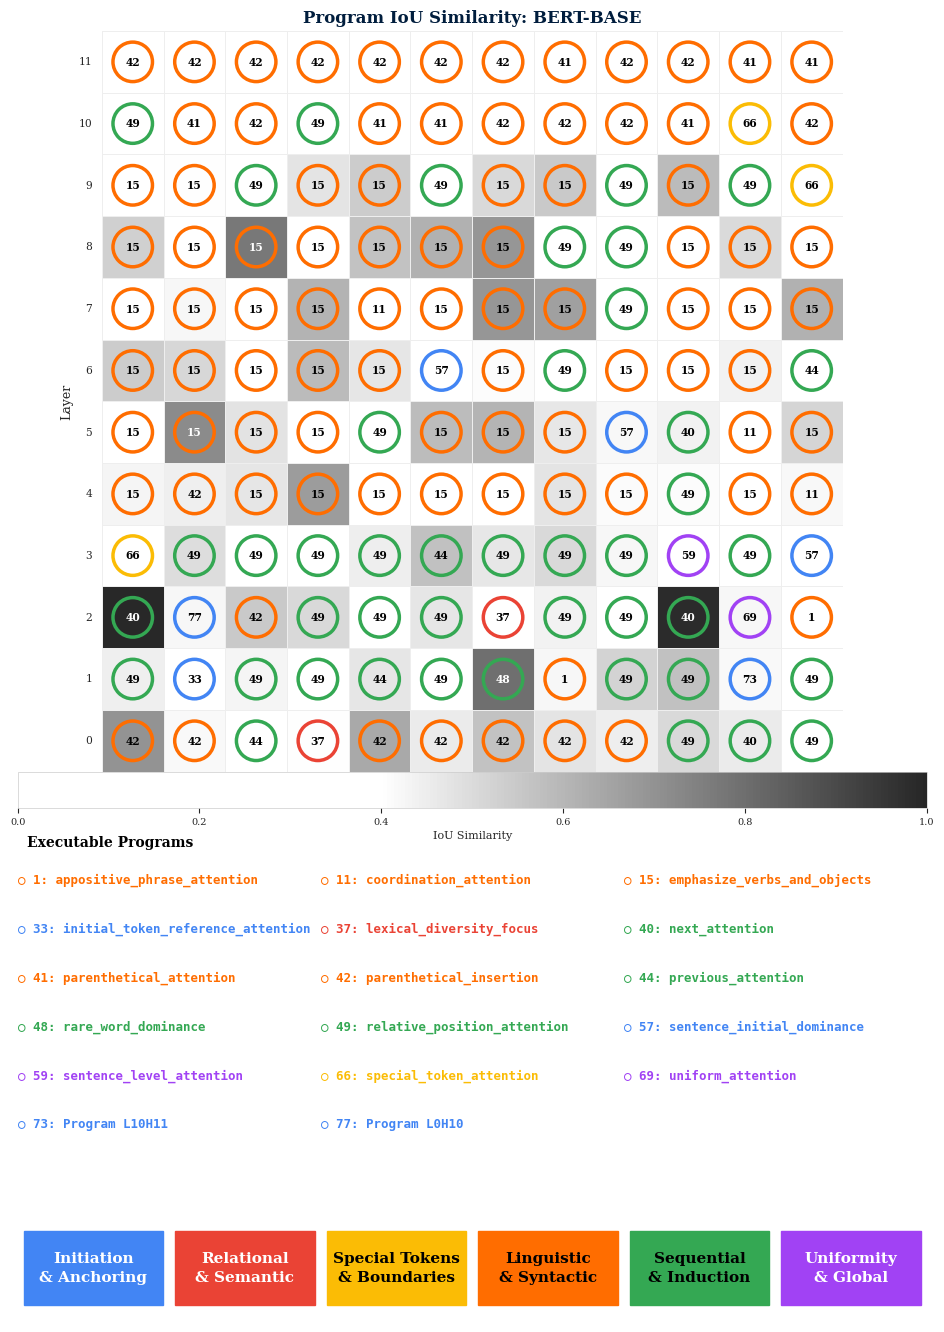

Saved → ../results/plots/figure_4_2/figure_4_2_bert.pdf


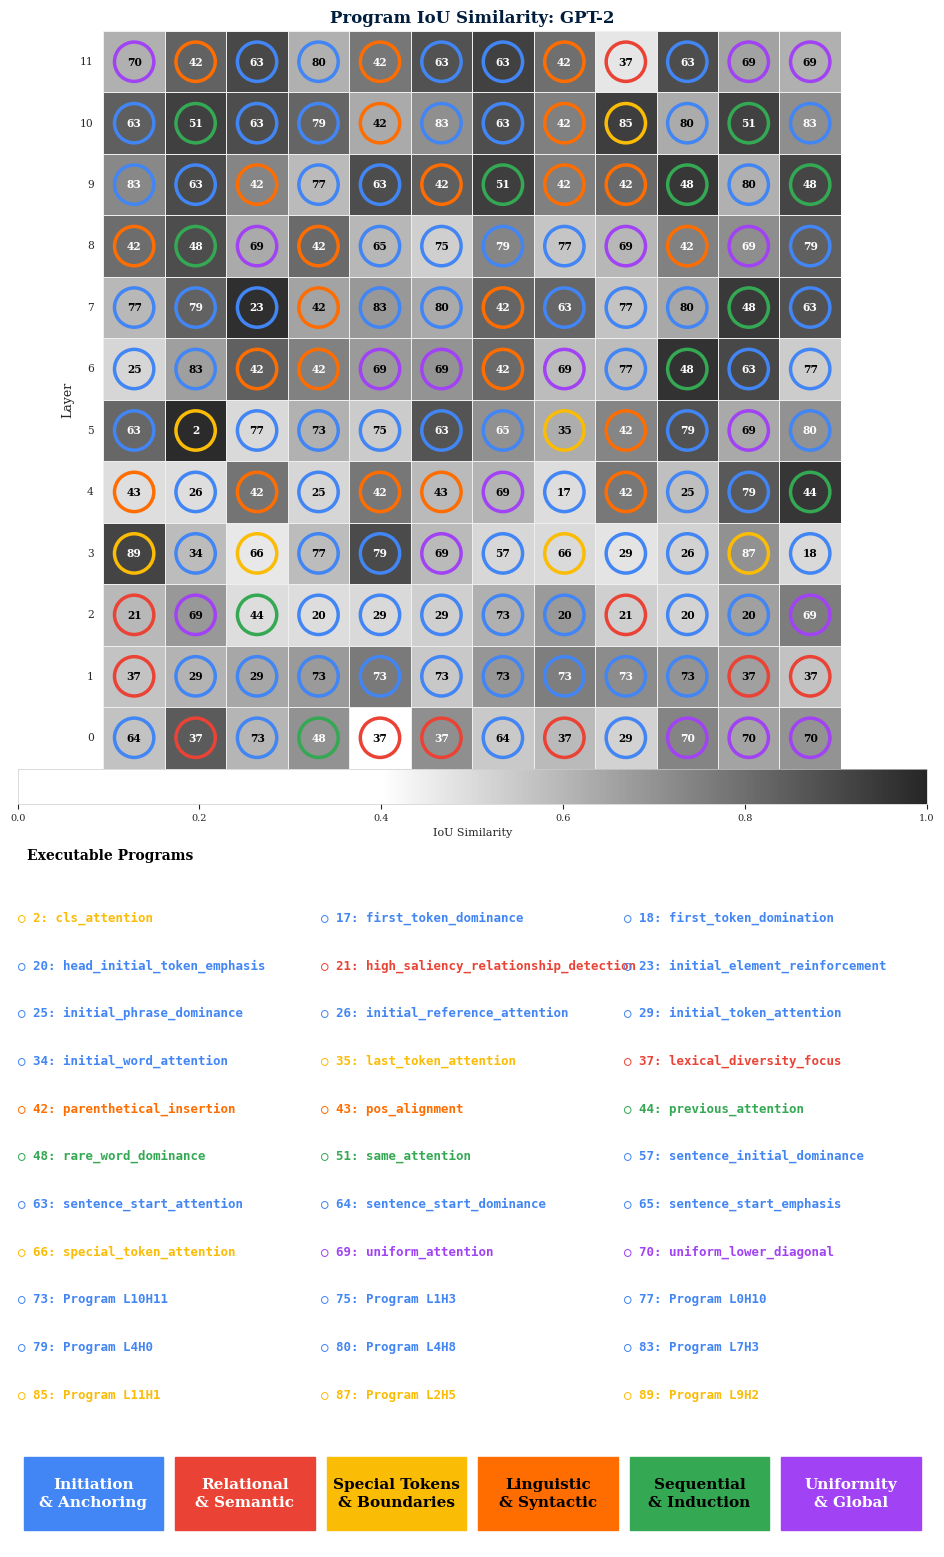

Saved → ../results/plots/figure_4_2/figure_4_2_gpt2.pdf


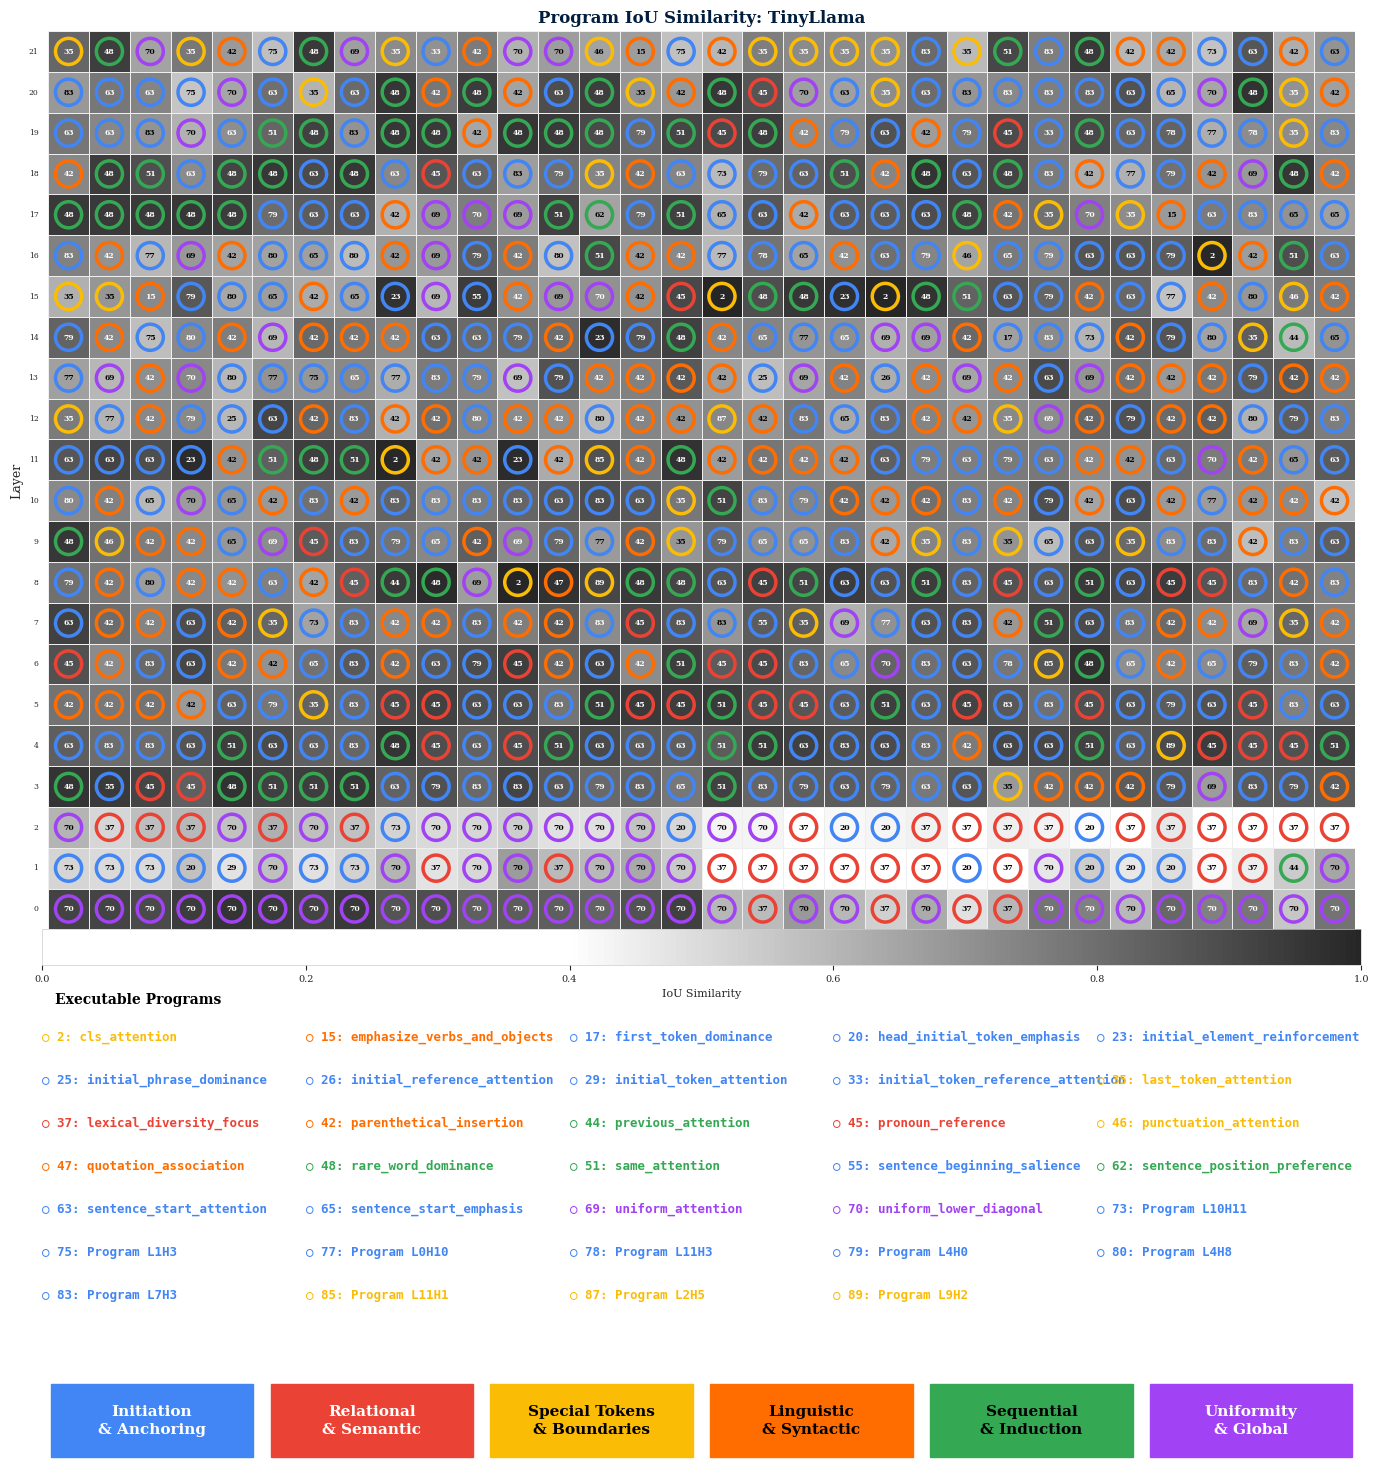

Saved → ../results/plots/figure_4_2/figure_4_2_tinyllama.pdf


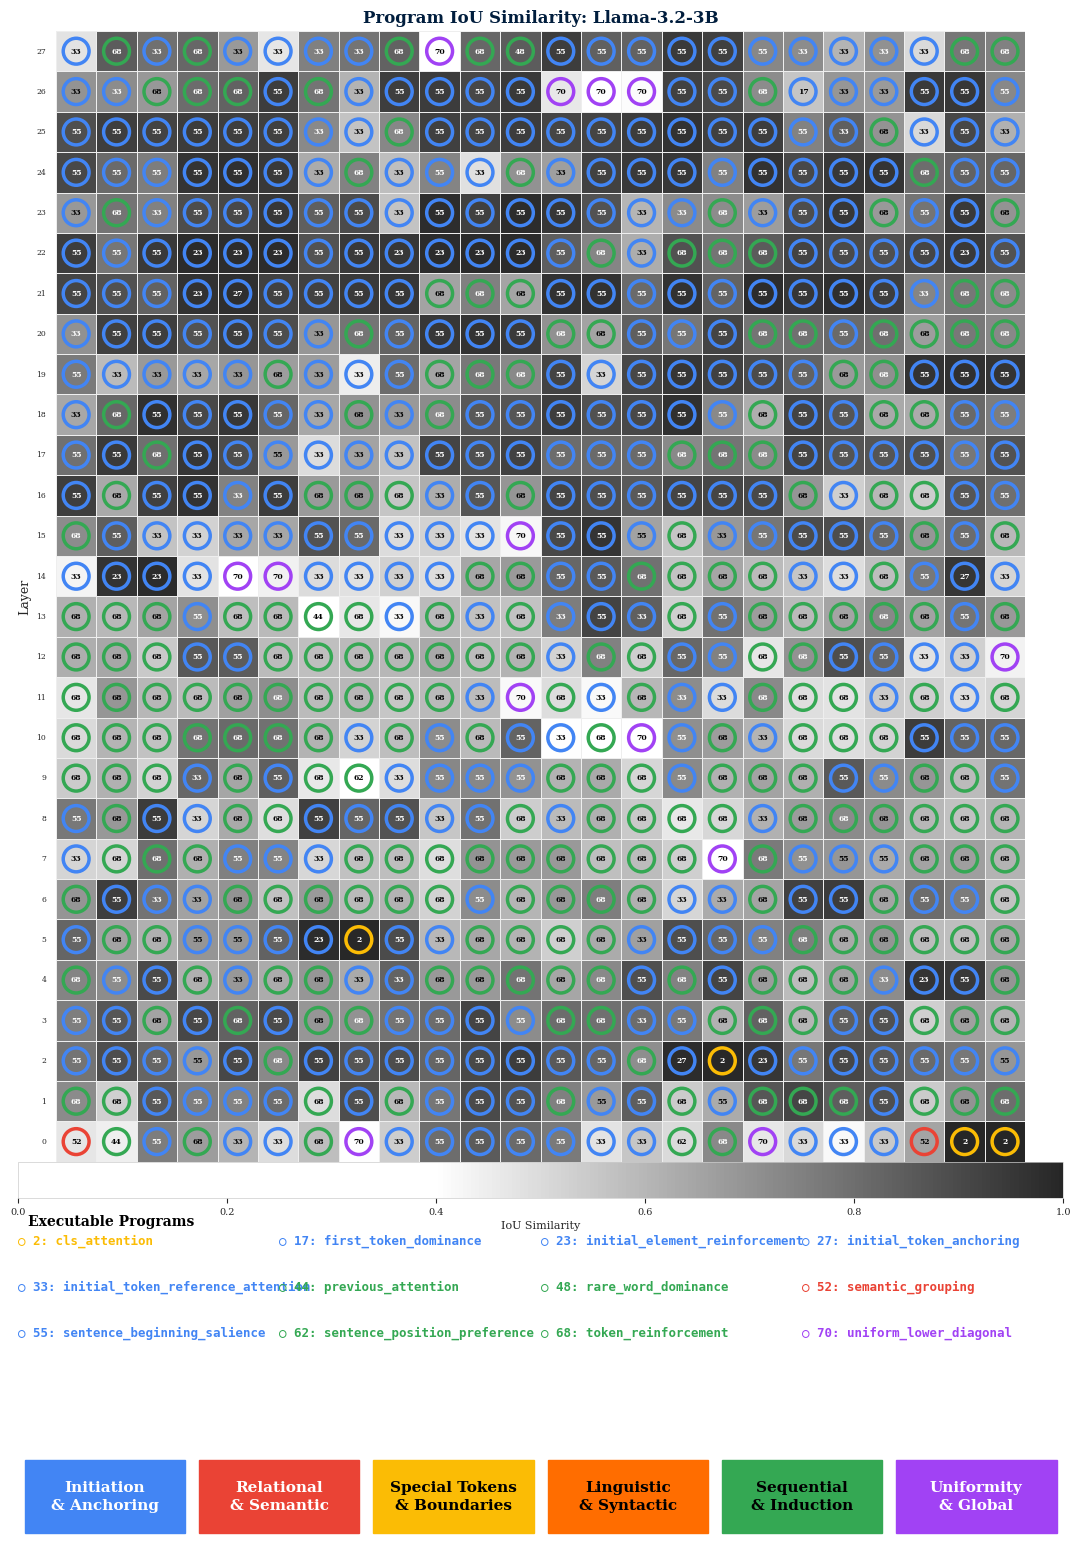

Saved → ../results/plots/figure_4_2/figure_4_2_llama3b.pdf


In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import os
import re

# ── Colormap ──
colors_map = [(1, 1, 1), (1, 1, 1), (0.15, 0.15, 0.15)]
nodes      = [0.0, 0.4, 1.0]
standard_prec_map = mcolors.LinearSegmentedColormap.from_list(
    "custom_gray", list(zip(nodes, colors_map)))

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#4285F4",
    "relational_and_semantic":       "#EA4335",
    "special_tokens_and_boundaries": "#FBBC05",
    "linguistic_and_syntactic":      "#FF6D00",
    "sequential_and_induction":      "#34A853",
    "uniformity_and_global":         "#A142F4",
}

# ── Per-model display config ──
# cell:     inches per heatmap cell
# w_pad:    extra width added beyond n_heads * cell
# h_pad:    extra height added beyond n_layers * cell
# leg_cols: legend columns
# leg_row_h: legend row height multiplier
DISPLAY_CONFIG = {
    "bert": dict(
        cell=0.55, w_pad=3.5, h_pad=0.6,
        leg_cols=3, leg_row_h=0.45,
    ),
    "gpt2": dict(
        cell=0.55, w_pad=3.5, h_pad=0.6,
        leg_cols=3, leg_row_h=0.45,
    ),
    "tinyllama": dict(
        cell=0.38, w_pad=2.5, h_pad=0.4,
        leg_cols=5, leg_row_h=0.38,
    ),
    "llama3b": dict(
        cell=0.38, w_pad=2.5, h_pad=0.4,
        leg_cols=4, leg_row_h=0.38,
    ),
}

def get_name_to_category(categories):
    return {m: cat for cat, members in categories.items() for m in members}

def get_text_color(hex_color):
    rgb = mcolors.to_rgb(hex_color)
    luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
    return 'black' if luminance > 0.5 else 'white'

def clean_program_name(name):
    m = re.search(r'(L\d+H\d+)$', name, re.IGNORECASE)
    return f"Program {m.group(1)}" if m else name

def _build_matrix(best_fits, n_layers, n_heads):
    data = np.zeros((n_layers, n_heads))
    for layer, head, name, score in best_fits:
        if score is not None and layer < n_layers and head < n_heads:
            data[layer, head] = float(score)
    return data

def _ordered_fits(best_fits, n_layers, n_heads):
    grid = {(layer, head): (name, score) for layer, head, name, score in best_fits}
    result = []
    for l in range(n_layers):
        for h in range(n_heads):
            name, score = grid.get((l, h), (None, 0.0))
            result.append((h, name, score))
    return result

def save_model_heatmap(
    best_fits, all_programs, categories,
    n_layers, n_heads, title, out_path,
    cfg,
):
    cell      = cfg["cell"]
    w_pad     = cfg["w_pad"]
    h_pad     = cfg["h_pad"]
    leg_cols  = cfg["leg_cols"]
    leg_row_h = cfg["leg_row_h"]

    all_names   = [func.__name__ for func in all_programs]
    name_to_cat = get_name_to_category(categories)

    data         = _build_matrix(best_fits, n_layers, n_heads)
    ordered_fits = _ordered_fits(best_fits, n_layers, n_heads)

    appeared_names    = sorted(
        {name for _, name, _ in ordered_fits if name},
        key=lambda n: all_names.index(n))
    filtered_programs = [(all_names.index(n), n) for n in appeared_names]

    leg_rows = int(np.ceil(len(filtered_programs) / leg_cols))
    hm_w     = n_heads * cell + w_pad
    hm_h     = n_layers * cell + h_pad
    leg_h    = max(1.5, leg_rows * leg_row_h + 1.2)
    cat_h    = 1.1
    cbar_h   = 0.35
    pad      = 0.18
    total_h  = hm_h + cbar_h + leg_h + cat_h + pad * 4

    fig = plt.figure(figsize=(hm_w, total_h))
    gs  = gridspec.GridSpec(4, 1, figure=fig,
                            height_ratios=[hm_h, cbar_h, leg_h, cat_h],
                            hspace=0.0,
                            left=0.07, right=0.97,
                            top=1 - pad/total_h,
                            bottom=pad/total_h)

    # 1. Heatmap
    ax_hm = fig.add_subplot(gs[0])
    sns.heatmap(data[::-1], ax=ax_hm, cmap=standard_prec_map, cbar=False,
                linewidths=0.4, linecolor='#EEEEEE', vmin=0, vmax=1, square=True)

    circle_r  = 0.32
    font_size = max(5.5, min(8.0, cell * 14))
    for i, (head_id, name, score) in enumerate(ordered_fits):
        if not name: continue
        layer_val  = i // n_heads
        x          = i % n_heads
        y_pos      = (n_layers - 1) - layer_val
        cell_val   = data[layer_val, x]
        cat        = name_to_cat.get(name)
        color      = CATEGORY_COLORS.get(cat, "#333333")
        text_color = "white" if cell_val > 0.7 else "black"
        legend_idx = all_names.index(name) if name in all_names else head_id
        ax_hm.add_patch(plt.Circle((x + 0.5, y_pos + 0.5), radius=circle_r,
                                    facecolor='none', edgecolor=color,
                                    linewidth=2.5, zorder=3))
        ax_hm.text(x + 0.5, y_pos + 0.5, str(legend_idx),
                   ha='center', va='center', color=text_color,
                   fontweight='bold', fontsize=font_size, zorder=4)

    ax_hm.set_title(title, fontweight='bold', fontsize=12, color='#001D3D', pad=6)
    ax_hm.set_yticklabels(range(n_layers - 1, -1, -1), rotation=0, fontsize=max(5.5, cell * 14))
    ax_hm.set_xticklabels(range(n_heads), fontsize=max(5.5, cell * 14))
    ax_hm.set_xlabel("Head", fontsize=9, labelpad=4)
    ax_hm.set_ylabel("Layer", fontsize=9)

    # 2. Colorbar
    ax_cb = fig.add_subplot(gs[1])
    norm  = mcolors.Normalize(vmin=0, vmax=1)
    cb    = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=standard_prec_map),
                         cax=ax_cb, orientation='horizontal')
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=7)
    cb.set_label("IoU Similarity", fontsize=8, labelpad=3)

    # 3. Program legend
    ax_leg = fig.add_subplot(gs[2])
    ax_leg.axis('off')
    ax_leg.text(0.01, 0.93, "Executable Programs",
                fontweight='bold', fontsize=10, color='black',
                transform=ax_leg.transAxes, va='top')

    col_w = 1.0 / leg_cols
    row_h = 1.0 / (leg_rows + 2.2)
    for i, (original_idx, name) in enumerate(filtered_programs):
        col     = i % leg_cols
        row     = i // leg_cols
        x       = col * col_w
        y       = 0.82 - row * row_h
        cat     = name_to_cat.get(name)
        color   = CATEGORY_COLORS.get(cat, "#333333")
        display = clean_program_name(name)
        ax_leg.text(x, y, f"○ {original_idx}: {display}",
                    color=color, fontsize=9, fontfamily='monospace',
                    fontweight='bold', transform=ax_leg.transAxes, va='center')

    # 4. Category boxes
    ax_cat = fig.add_subplot(gs[3])
    ax_cat.axis('off')
    n_cats = len(CATEGORY_COLORS)
    box_w  = 1.0 / n_cats
    margin = 0.04
    for i, (group, color) in enumerate(CATEGORY_COLORS.items()):
        x0 = i * box_w + margin * box_w
        w  = box_w * (1 - 2 * margin)
        ax_cat.add_patch(mpatches.Rectangle(
            (x0, 0.15), w, 0.65,
            color=color, transform=ax_cat.transAxes, clip_on=False))
        clean = group.replace('_', ' ').title().replace(' And', '\n&')
        ax_cat.text(x0 + w / 2, 0.15 + 0.65 / 2, clean,
                    color=get_text_color(color), ha='center', va='center',
                    fontweight='bold', fontsize=11,
                    transform=ax_cat.transAxes, linespacing=1.4)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out_path}")
    plt.close()

# ── Model registry ──
MODELS = [
    dict(key="bert",      best_fits=best_fits_bert,      n_layers=12, n_heads=12,
         title="Program IoU Similarity: BERT-BASE",
         out_path="../results/plots/figure_4_2/figure_4_2_bert.pdf"),
    dict(key="gpt2",      best_fits=best_fits_gpt2,      n_layers=12, n_heads=12,
         title="Program IoU Similarity: GPT-2",
         out_path="../results/plots/figure_4_2/figure_4_2_gpt2.pdf"),
    dict(key="tinyllama", best_fits=best_fits_tinyllama, n_layers=22, n_heads=32,
         title="Program IoU Similarity: TinyLlama",
         out_path="../results/plots/figure_4_2/figure_4_2_tinyllama.pdf"),
    dict(key="llama3b",   best_fits=best_fits_llama3b,   n_layers=28, n_heads=24,
         title="Program IoU Similarity: Llama-3.2-3B",
         out_path="../results/plots/figure_4_2/figure_4_2_llama3b.pdf"),
]

for m in MODELS:
    save_model_heatmap(
        best_fits=m["best_fits"],
        all_programs=all_programs,
        categories=attention_head_categories,
        n_layers=m["n_layers"],
        n_heads=m["n_heads"],
        title=m["title"],
        out_path=m["out_path"],
        cfg=DISPLAY_CONFIG[m["key"]],
    )

## Figure 4.3: Perplexity Impact of Head Replacement

Shows normalized perplexity increase as progressively more attention heads are replaced with symbolic hypothesis programs.

In [31]:
def prepare_sentence(sent, mode="random"):
    words = sent.split()
    if len(words) <= 3:
        return sent
        
    if mode == "random":
        idx = np.random.randint(3, len(words))
        return " ".join(words[:idx])
    elif mode == "last_word":
        return " ".join(words[:-1])
    else:
        return sent

def run_replacement_experiment_gpt2(
    sentences,
    best_fits_df,
    all_programs,
    strategy="baseline",
    max_heads=144,
    num_sentences=5,
    spike_threshold=50.0,
    skip_spikes=True,
    save_file=""
):
    import pathlib
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn.functional as F
    import ast
    from transformers import GPT2LMHeadModel, GPT2Tokenizer

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    eval_sentences = sentences[:num_sentences]
    experiment_results = []
    skipped_programs = []

    # --- Baseline ---
    print("Calculating baseline perplexities...")
    base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    base_model.eval()
    baseline_ppls, baseline_logits = [], []

    for sent in eval_sentences:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = base_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(outputs.loss).item())
            baseline_logits.append(outputs.logits[:, -1, :])

    del base_model
    torch.cuda.empty_cache()
    print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}")

    # --- Robust DataFrame Parsing ---
    unique_heads_mapping = []
    seen_heads = set()
    for _, row in best_fits_df.iterrows():
        if 'layer' in row and 'head' in row:
            head_tuple = (int(row['layer']), int(row['head']))
        else:
            raw_head = row['head']
            if isinstance(raw_head, str):
                head_tuple = tuple(ast.literal_eval(raw_head))
            elif hasattr(raw_head, "__iter__"):
                head_tuple = tuple(raw_head)
            else:
                head_tuple = (0, int(raw_head))
            
        if head_tuple not in seen_heads:
            try:
                p_idx = int(row['program_idx'])
                prog_name = all_programs[p_idx].__name__
                unique_heads_mapping.append((head_tuple, [prog_name]))
                seen_heads.add(head_tuple)
            except (KeyError, IndexError, ValueError):
                continue

    # --- Hook factories ---
    def make_baseline_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            mask = torch.tril(torch.ones((seq_len, seq_len), device=device))
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(mask, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None: return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception: pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_sanity_check_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            identity = torch.eye(seq_len, device=device, dtype=modified_layer.dtype)
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(identity, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    # --- Main loop ---
    print(f"Running with strategy='{strategy}', skip_spikes={skip_spikes}")
    accepted_heads_mapping = []
    k = 0

    for candidate in unique_heads_mapping:
        if k >= max_heads: break

        trial_mapping = accepted_heads_mapping + [candidate]
        trial_lookup = {tuple(map(int, item[0])): item[1][0] for item in trial_mapping}
        relevant_layers = set(idx[0] for idx in trial_lookup)

        model_k = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        model_k.eval()

        if strategy == "baseline": hook_fn = make_baseline_hook(trial_lookup)
        elif strategy == "smart": hook_fn = make_smart_hook(trial_lookup, all_programs)
        elif strategy == "sanity_check": hook_fn = make_sanity_check_hook(trial_lookup)
        else: raise ValueError(f"Unknown strategy: '{strategy}'.")

        hook_handles = []
        for l_idx in range(12):
            target = model_k.transformer.h[l_idx].attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divergences = [], []
        for i, sent in enumerate(eval_sentences):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                model_k.transformer.h[l_idx].attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out_rep = model_k(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out_rep.loss).item())
                log_probs_new = F.log_softmax(out_rep.logits[:, -1, :], dim=-1)
                probs_baseline = F.softmax(baseline_logits[i], dim=-1)
                kl_divergences.append(F.kl_div(log_probs_new, probs_baseline, reduction='batchmean').item())

        for handle in hook_handles: handle.remove()
        del model_k
        torch.cuda.empty_cache()

        mean_pct = np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)])
        prev_mean = experiment_results[-1]["increase"] if experiment_results else 0.0
        marginal = mean_pct - prev_mean
        is_spike = marginal > spike_threshold

        if is_spike and skip_spikes:
            skipped_programs.append({"head": candidate[0], "program": candidate[1][0], "marginal": marginal})
            print(f"  [SKIP] Spike detected for head {candidate[0]} with marginal increase of {marginal:.2f}%.")
            continue

        if mean_pct > 1000.0:
            print(f"Perplexity increase exceeded 1000% ({mean_pct:.2f}%). Stopping early.")
            break

        k += 1
        accepted_heads_mapping.append(candidate)
        experiment_results.append({
            "k": k, "head": str(candidate[0]), "program": candidate[1][0],
            "strategy": strategy, "increase": mean_pct, "kl_div": np.mean(kl_divergences),
            "spike": is_spike,
        })
        print(f"k={k:02d} | Head: {candidate[0]} | Program: {candidate[1][0]} | Mean PPL Inc: {mean_pct:.4f}%")

    results_df = pd.DataFrame(experiment_results)
    if save_file:
        results_df.to_csv(save_file, index=False)
    else:
        pathlib.Path("../results/replacement_run").mkdir(exist_ok=True)
        results_df.to_csv(f"../results/replacement_run/gpt2_{strategy}.csv", index=False)
    return results_df


import pathlib
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import BertForMaskedLM, AutoTokenizer, logging as hf_logging

def full_perplexity(sentence, bert_model, tokenizer, device):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    seq_len = input_ids.shape[1]
    log_probs = []
    for i in range(1, seq_len - 1):  # skip [CLS] and [SEP]
        masked = input_ids.clone()
        masked[0, i] = tokenizer.mask_token_id
        with torch.no_grad():
            logits = bert_model(masked).logits
        prob = torch.log_softmax(logits[0, i], dim=-1)[input_ids[0, i]]
        log_probs.append(prob)
    return torch.exp(-torch.stack(log_probs).mean()).item()

def run_replacement_experiment_bert(
    sentences,
    best_fits_df,
    all_programs,
    strategy="smart",
    max_heads=144,
    num_sentences=5,
    bert_model_name="bert-base-uncased",
    spike_threshold=50.0,
    skip_spikes=True,
    save_file=""
):
    import ast
    hf_logging.set_verbosity_error()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
    eval_sentences = sentences[:num_sentences]
    experiment_results = []
    skipped_programs = []
    models = {}

    # --- Baseline ---
    print("Calculating baseline pseudo-perplexities...")
    base_model = BertForMaskedLM.from_pretrained(bert_model_name).to(device)
    base_model.eval()
    baseline_ppls = [full_perplexity(s, base_model, tokenizer, device) for s in eval_sentences]
    del base_model
    torch.cuda.empty_cache()
    print(f"Baseline complete. Mean pseudo-PPL: {np.mean(baseline_ppls):.2f}")

    print(f"\n=== STRATEGY: {strategy.upper()} ===\n")

    # --- Robust DataFrame Parsing ---
    unique_heads_mapping = []
    seen_heads = set()
    for _, row in best_fits_df.iterrows():
        if 'layer' in row and 'head' in row:
            head_tuple = (int(row['layer']), int(row['head']))
        else:
            raw_head = row['head']
            if isinstance(raw_head, str):
                head_tuple = tuple(ast.literal_eval(raw_head))
            elif hasattr(raw_head, "__iter__"):
                head_tuple = tuple(raw_head)
            else:
                head_tuple = (0, int(raw_head))
            
        if head_tuple not in seen_heads:
            try:
                p_idx = int(row['program_idx'])
                prog_name = all_programs[p_idx].__name__
            except (KeyError, IndexError, ValueError) as e:
                print(f"  [WARN] Could not resolve program for head {head_tuple}: {e}")
                prog_name = None

            if prog_name:
                unique_heads_mapping.append((head_tuple, [prog_name]))
                seen_heads.add(head_tuple)

    print(f"Total heads to replace: {len(unique_heads_mapping)}")

    # --- Hook factories ---
    def make_baseline_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            attn_mask = torch.tril(torch.ones((seq_len, seq_len), device=device))
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(attn_mask, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                if hypo_tensor.shape == (seq_len, seq_len):
                                    modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_sanity_check_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            identity = torch.eye(seq_len, device=device, dtype=modified_layer.dtype)
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(identity, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    # --- Main loop ---
    print(f"Running with strategy='{strategy}', skip_spikes={skip_spikes}")
    accepted_heads_mapping = []
    k = 0

    for candidate in unique_heads_mapping:
        if k >= max_heads:
            break

        trial_mapping = accepted_heads_mapping + [candidate]
        trial_lookup = {tuple(map(int, item[0])): item[1][0] for item in trial_mapping}
        relevant_layers = set(idx[0] for idx in trial_lookup)

        model_key = f"model_v{k}"
        models[model_key] = BertForMaskedLM.from_pretrained(bert_model_name).to(device)
        models[model_key].eval()

        if strategy == "baseline":
            hook_fn = make_baseline_hook(trial_lookup)
        elif strategy == "sanity_check":
            hook_fn = make_sanity_check_hook(trial_lookup)
        else:
            hook_fn = make_smart_hook(trial_lookup, all_programs)

        hook_handles = []
        for l_idx in range(12):
            target = models[model_key].bert.encoder.layer[l_idx].attention.self
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls = []
        for sent in eval_sentences:
            for l_idx in relevant_layers:
                models[model_key].bert.encoder.layer[l_idx].attention.self._current_sentence = sent
            replaced_ppls.append(full_perplexity(sent, models[model_key], tokenizer, device))

        for handle in hook_handles:
            handle.remove()
        del models[model_key]
        torch.cuda.empty_cache()

        mean_pct = np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)])
        prev_mean = experiment_results[-1]["increase"] if experiment_results else 0.0
        marginal = mean_pct - prev_mean
        is_spike = marginal > spike_threshold

        if is_spike and skip_spikes:
            skipped_programs.append({"head": candidate[0], "program": candidate[1][0], "marginal": marginal})
            print(f"  [SKIP] Spike detected for head {candidate[0]} with marginal increase of {marginal:.2f}%.")
            continue

        if mean_pct > 1000.0:
            print(f"Perplexity increase exceeded 1000% ({mean_pct:.2f}%). Stopping early.")
            break

        k += 1
        accepted_heads_mapping.append(candidate)
        experiment_results.append({
            "k": k,
            "head": str(candidate[0]),
            "program": candidate[1][0],
            "strategy": strategy,
            "increase": mean_pct,
            "spike": is_spike,
        })
        print(f"k={k:02d} | New Head: {candidate[0]} | Program: {candidate[1][0]} | Mean PPL Inc: {mean_pct:.4f}%")

    results_df = pd.DataFrame(experiment_results)
    if save_file:
        results_df.to_csv(save_file, index=False)
    else:
        pathlib.Path("../results/replacement_run").mkdir(exist_ok=True)
        results_df.to_csv(f"../results/replacement_run/bert_{strategy}.csv", index=False)
    return results_df


def run_replacement_experiment_llama(
    sentences,
    best_fits_df,
    all_programs,
    strategy="smart",
    max_heads=250,
    num_sentences=5,
    spike_threshold=50.0,
    skip_spikes=True,
    save_file=""
):
    import copy
    import pathlib
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn.functional as F
    import ast
    from transformers import AutoTokenizer, AutoModelForCausalLM

    MODEL_ID = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
    NUM_LAYERS, NUM_HEADS, HIDDEN_SIZE = 22, 32, 2048
    HEAD_DIM = HIDDEN_SIZE // NUM_HEADS

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    eval_sentences = sentences[:num_sentences]
    experiment_results = []
    skipped_programs = []

    print("Loading reference model...")
    ref_model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(device)
    ref_model.eval()

    print("Calculating baseline perplexities...")
    baseline_ppls, baseline_logits = [], []
    for sent in eval_sentences:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = ref_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(outputs.loss).item())
            baseline_logits.append(outputs.logits[:, -1, :])
    print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}")

    # --- Robust DataFrame Parsing ---
    unique_heads_mapping = []
    seen_heads = set()
    for _, row in best_fits_df.iterrows():
        if 'layer' in row and 'head' in row:
            head_tuple = (int(row['layer']), int(row['head']))
        else:
            raw_head = row['head']
            if isinstance(raw_head, str):
                head_tuple = tuple(ast.literal_eval(raw_head))
            elif hasattr(raw_head, "__iter__"):
                head_tuple = tuple(raw_head)
            else:
                head_tuple = (0, int(raw_head))
            
        if head_tuple not in seen_heads:
            try:
                p_idx = int(row['program_idx'])
                prog_name = all_programs[p_idx].__name__
                unique_heads_mapping.append((head_tuple, [prog_name]))
                seen_heads.add(head_tuple)
            except (KeyError, IndexError, ValueError):
                continue

    # --- Hook factories ---
    def make_baseline_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            mask = torch.tril(torch.ones((seq_len, seq_len), device=device))
            for head_idx in range(NUM_HEADS):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(mask, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None: return output
            for head_idx in range(NUM_HEADS):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception: pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_sanity_check_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            identity = torch.eye(seq_len, device=device, dtype=modified_layer.dtype)
            for head_idx in range(NUM_HEADS):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(identity, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    # --- Main loop ---
    print(f"Running with strategy='{strategy}', skip_spikes={skip_spikes}")
    accepted_heads_mapping = []
    k = 0

    for candidate in unique_heads_mapping:
        if k >= max_heads:
            break

        trial_mapping = accepted_heads_mapping + [candidate]
        iteration_lookup = {tuple(map(int, item[0])): item[1][0] for item in trial_mapping}
        relevant_layers = set(idx[0] for idx in iteration_lookup)

        iter_model = copy.deepcopy(ref_model)
        iter_model.eval()

        if strategy == "smart": hook_fn = make_smart_hook(iteration_lookup, all_programs)
        elif strategy == "baseline": hook_fn = make_baseline_hook(iteration_lookup)
        elif strategy == "sanity_check": hook_fn = make_sanity_check_hook(iteration_lookup)
        else: raise ValueError(f"Unknown strategy: '{strategy}'.")

        hook_handles = []
        for l_idx in range(NUM_LAYERS):
            target = iter_model.model.layers[l_idx].self_attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divergences = [], []
        for i, sent in enumerate(eval_sentences):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                iter_model.model.layers[l_idx].self_attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out_rep = iter_model(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out_rep.loss).item())
                kl_divergences.append(F.kl_div(
                    F.log_softmax(out_rep.logits[:, -1, :], dim=-1),
                    F.softmax(baseline_logits[i], dim=-1),
                    reduction='batchmean'
                ).item())

        for handle in hook_handles: handle.remove()
        del iter_model
        torch.cuda.empty_cache()

        mean_pct = np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)])
        prev_mean = experiment_results[-1]["increase"] if experiment_results else 0.0
        marginal = mean_pct - prev_mean
        is_spike = marginal > spike_threshold

        if mean_pct > 1000.0:
            print(f"Perplexity increase exceeded 1000% ({mean_pct:.2f}%). Stopping early.")
            break

        if is_spike and skip_spikes:
            skipped_programs.append({"head": candidate[0], "program": candidate[1][0], "marginal": marginal})
            print(f"  [SKIP] Spike detected for head {candidate[0]} with marginal increase of {marginal:.2f}%.")
            continue

        k += 1
        accepted_heads_mapping.append(candidate)
        experiment_results.append({
            "k": k, "head": str(candidate[0]), "program": candidate[1][0],
            "strategy": strategy, "increase": mean_pct, "kl_div": np.mean(kl_divergences),
            "spike": is_spike,
        })
        print(f"k={k:02d} | Head: {candidate[0]} | Program: {candidate[1][0]} | Mean PPL Inc: {mean_pct:.4f}%")

    if save_file:
        pd.DataFrame(experiment_results).to_csv(save_file, index=False)
    else:
        pathlib.Path("../results/replacement_run").mkdir(exist_ok=True)
        pd.DataFrame(experiment_results).to_csv(f"../results/replacement_run/tinyllama_{strategy}.csv", index=False)
    del ref_model
    return pd.DataFrame(experiment_results)


def run_replacement_experiment_llama3b(
    sentences,
    best_fits_df,
    all_programs,
    strategy="smart",
    max_heads=250,
    num_sentences=5,
    spike_threshold=50.0,
    skip_spikes=True,
    save_file=""
):
    """Replacement experiment for Llama-3.2-3B.
    Architecture: 28 layers, 24 Q-heads, 8 KV-heads (GQA), hidden=3072, head_dim=128.
    HF expands KV→Q before returning attentions, so hook shape is always
    (batch, seq_len, hidden_dim) = (1, seq, 3072) and the head reshape is
    (batch, seq, 24, 128) — same pattern as TinyLlama, different constants.
    """
    import copy
    import pathlib
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn.functional as F
    import ast
    from transformers import AutoTokenizer, AutoModelForCausalLM

    MODEL_ID   = "meta-llama/Llama-3.2-3B"
    NUM_LAYERS = 28
    NUM_HEADS  = 24        # Q-heads (GQA: 8 KV-heads, but output is Q-head shaped)
    HIDDEN_SIZE = 3072
    HEAD_DIM   = HIDDEN_SIZE // NUM_HEADS  # 128

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    eval_sentences = sentences[:num_sentences]
    experiment_results = []
    skipped_programs = []

    print("Loading reference model (Llama-3.2-3B)...")
    ref_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto",
        attn_implementation="eager",
    )
    ref_model.eval()

    print("Calculating baseline perplexities...")
    baseline_ppls, baseline_logits = [], []
    for sent in eval_sentences:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = ref_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(outputs.loss).item())
            baseline_logits.append(outputs.logits[:, -1, :].float())
    print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}")

    # --- Parse best_fits_df ---
    unique_heads_mapping = []
    seen_heads = set()
    for _, row in best_fits_df.iterrows():
        if "layer" in row and "head" in row:
            head_tuple = (int(row["layer"]), int(row["head"]))
        else:
            raw = row["head"]
            head_tuple = tuple(ast.literal_eval(raw)) if isinstance(raw, str) else (0, int(raw))
        if head_tuple not in seen_heads:
            try:
                p_idx = int(row["program_idx"])
                prog_name = all_programs[p_idx].__name__
                unique_heads_mapping.append((head_tuple, [prog_name]))
                seen_heads.add(head_tuple)
            except (KeyError, IndexError, ValueError):
                continue

    # --- Hook factories (same structure as TinyLlama, different constants) ---
    def make_baseline_hook(lookup):
        def hook(module, input, output):
            ctx = output[0].contiguous().float()
            b, s, _ = ctx.shape
            mod = ctx.view(b, s, NUM_HEADS, HEAD_DIM).clone()
            mask = torch.tril(torch.ones((s, s), device=device))
            for h in range(NUM_HEADS):
                if (module.layer_id, h) in lookup:
                    mod[:, :, h, :] = torch.matmul(mask, mod[:, :, h, :])
            return (mod.view(b, s, HIDDEN_SIZE).to(output[0].dtype),) + output[1:]
        return hook

    def make_smart_hook(lookup, programs_list):
        def hook(module, input, output):
            ctx = output[0].contiguous().float()
            b, s, _ = ctx.shape
            mod = ctx.view(b, s, NUM_HEADS, HEAD_DIM).clone()
            cur = getattr(module, "_current_sentence", None)
            if cur is None:
                return output
            for h in range(NUM_HEADS):
                key = (module.layer_id, h)
                if key in lookup:
                    prog = next((p for p in programs_list if p.__name__ == lookup[key]), None)
                    if prog:
                        try:
                            import inspect as _insp
                            n_p = len(_insp.signature(prog).parameters)
                            _, mat = prog(cur) if n_p == 1 else prog(cur, tokenizer)
                            if mat is not None:
                                t = torch.tensor(mat, device=device, dtype=mod.dtype)
                                mod[:, :, h, :] = torch.matmul(t, mod[:, :, h, :])
                        except Exception:
                            pass
            return (mod.view(b, s, HIDDEN_SIZE).to(output[0].dtype),) + output[1:]
        return hook

    def make_sanity_check_hook(lookup):
        def hook(module, input, output):
            ctx = output[0].contiguous().float()
            b, s, _ = ctx.shape
            mod = ctx.view(b, s, NUM_HEADS, HEAD_DIM).clone()
            eye = torch.eye(s, device=device, dtype=mod.dtype)
            for h in range(NUM_HEADS):
                if (module.layer_id, h) in lookup:
                    mod[:, :, h, :] = torch.matmul(eye, mod[:, :, h, :])
            return (mod.view(b, s, HIDDEN_SIZE).to(output[0].dtype),) + output[1:]
        return hook

    # --- Main loop ---
    print(f"Running with strategy='{strategy}', skip_spikes={skip_spikes}")
    accepted_heads_mapping = []
    k = 0

    for candidate in unique_heads_mapping:
        if k >= max_heads:
            break

        trial_mapping    = accepted_heads_mapping + [candidate]
        iteration_lookup = {tuple(map(int, item[0])): item[1][0] for item in trial_mapping}
        relevant_layers  = set(idx[0] for idx in iteration_lookup)

        iter_model = copy.deepcopy(ref_model)
        iter_model.eval()

        if   strategy == "smart":         hook_fn = make_smart_hook(iteration_lookup, all_programs)
        elif strategy == "baseline":      hook_fn = make_baseline_hook(iteration_lookup)
        elif strategy == "sanity_check":  hook_fn = make_sanity_check_hook(iteration_lookup)
        else: raise ValueError(f"Unknown strategy: '{strategy}'.")

        hook_handles = []
        for l_idx in range(NUM_LAYERS):
            target = iter_model.model.layers[l_idx].self_attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divs = [], []
        for i, sent in enumerate(eval_sentences):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                iter_model.model.layers[l_idx].self_attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out = iter_model(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out.loss).item())
                kl_divs.append(F.kl_div(
                    F.log_softmax(out.logits[:, -1, :].float(), dim=-1),
                    F.softmax(baseline_logits[i], dim=-1),
                    reduction="batchmean",
                ).item())

        for h in hook_handles: h.remove()
        del iter_model
        torch.cuda.empty_cache()

        mean_pct = np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)])
        prev_mean = experiment_results[-1]["increase"] if experiment_results else 0.0
        marginal  = mean_pct - prev_mean
        is_spike  = marginal > spike_threshold

        if mean_pct > 1000.0:
            print(f"Perplexity increase exceeded 1000% ({mean_pct:.2f}%). Stopping early.")
            break

        if is_spike and skip_spikes:
            skipped_programs.append({"head": candidate[0], "program": candidate[1][0], "marginal": marginal})
            print(f"  [SKIP] Spike for head {candidate[0]} with marginal {marginal:.2f}%.")
            continue

        k += 1
        accepted_heads_mapping.append(candidate)
        experiment_results.append({
            "k": k, "head": str(candidate[0]), "program": candidate[1][0],
            "strategy": strategy, "increase": mean_pct, "kl_div": np.mean(kl_divs),
            "spike": is_spike,
        })
        print(f"k={k:02d} | Head: {candidate[0]} | Program: {candidate[1][0]} | Mean PPL Inc: {mean_pct:.4f}%")

    pathlib.Path("../results/replacement_run").mkdir(exist_ok=True)
    out_path = save_file or f"../results/replacement_run/llama3b_{strategy}.csv"
    pd.DataFrame(experiment_results).to_csv(out_path, index=False)
    del ref_model
    return pd.DataFrame(experiment_results)


In [3]:
import pandas as pd
df_generic = pd.read_json("../data/generic_sentences.json")
generic_sentences = df_generic[0].tolist()
len(generic_sentences)

100

In [32]:
# ============================================================
# Run head replacement experiments per model
# Expected paths:
#   ../results/best_fits_{model}.csv
#   ../data/generic_sentences.json
# ============================================================

df_generic = pd.read_json("../data/generic_sentences.json")
generic_sentences = df_generic[0].tolist()

for model_key, cfg in MODEL_CONFIGS.items():
    print(f"\n[INFO] Running replacement for {model_key}")
    best_fits_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    if not os.path.exists(best_fits_csv):
        print(f"[WARN] Missing: {best_fits_csv}. Skipping {model_key}.")
        continue

    existing_files = [f for f in os.listdir("../results/replacement_run") if f.startswith(model_key)]
    if existing_files:
        print(f"[INFO] Found existing replacement results for {model_key}: {existing_files}. Skipping to avoid overwrite.")
        continue

    best_fits_df = pd.read_csv(best_fits_csv)
    best_fits_df = best_fits_df.sort_values(by="iou_score", ascending=False).reset_index(drop=True)

    if model_key == "bert":
        bert_smart = run_replacement_experiment_bert(generic_sentences, best_fits_df, all_programs, strategy="smart")
        bert_baseline = run_replacement_experiment_bert(generic_sentences, best_fits_df, all_programs, strategy="baseline")
    elif model_key == "gpt2":
        gpt2_smart = run_replacement_experiment_gpt2(generic_sentences, best_fits_df, all_programs, strategy="smart")
        gpt2_baseline = run_replacement_experiment_gpt2(generic_sentences, best_fits_df, all_programs, strategy="baseline")
    elif model_key == "tinyllama":
        tinyllama_smart = run_replacement_experiment_llama(generic_sentences, best_fits_df, all_programs, strategy="smart")
        tinyllama_baseline = run_replacement_experiment_llama(generic_sentences, best_fits_df, all_programs, strategy="baseline")
    elif model_key == "llama3b":
        llama3b_smart = run_replacement_experiment_llama3b(generic_sentences, best_fits_df, all_programs, strategy="smart")
        llama3b_baseline = run_replacement_experiment_llama3b(generic_sentences, best_fits_df, all_programs, strategy="baseline")
    else:
        print(f"[WARN] No replacement function defined for {model_key}. Skipping.")

print("\n[DONE] Replacement experiment sweep complete.")


[INFO] Running replacement for bert
[INFO] Found existing replacement results for bert: ['bert_baseline.csv', 'bert_smart.csv']. Skipping to avoid overwrite.

[INFO] Running replacement for gpt2
[INFO] Found existing replacement results for gpt2: ['gpt2_baseline.csv', 'gpt2_smart.csv']. Skipping to avoid overwrite.

[INFO] Running replacement for tinyllama
[INFO] Found existing replacement results for tinyllama: ['tinyllama_baseline.csv', 'tinyllama_smart.csv']. Skipping to avoid overwrite.

[INFO] Running replacement for llama3b
Loading reference model (Llama-3.2-3B)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


Calculating baseline perplexities...
Baseline complete. Mean PPL: 32.74
Running with strategy='smart', skip_spikes=True
k=01 | Head: (0, 22) | Program: cls_attention | Mean PPL Inc: 0.2697%
k=02 | Head: (0, 23) | Program: cls_attention | Mean PPL Inc: 0.8885%
k=03 | Head: (5, 7) | Program: cls_attention | Mean PPL Inc: 1.4814%
k=04 | Head: (2, 16) | Program: cls_attention | Mean PPL Inc: 1.5181%
k=05 | Head: (22, 10) | Program: initial_element_reinforcement | Mean PPL Inc: 1.4678%
k=06 | Head: (22, 3) | Program: initial_element_reinforcement | Mean PPL Inc: 1.4138%
k=07 | Head: (22, 11) | Program: initial_element_reinforcement | Mean PPL Inc: 1.6858%


: 

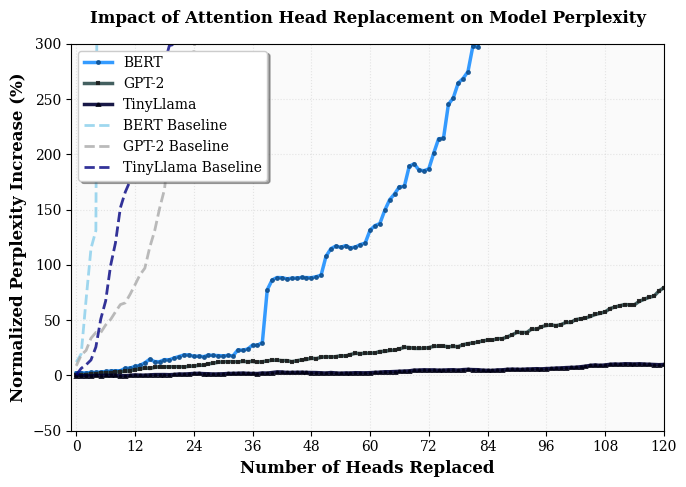

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Set publication-quality parameters
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 12
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Data points - X-axis: 0 to 35 (36 total)
MAX_X = 128
x = np.arange(MAX_X)

total_heads_bert = 144
total_heads_gpt2 = 144
total_heads_tinyllama = 704

bert_file = "../results/replacement_run/bert_smart.csv"
gpt2_file = "../results/replacement_run/gpt2_smart.csv"
tinyllama_file = "../results/replacement_run/tinyllama_smart.csv"
bert_baseline_file = "../results/replacement_run/bert_baseline.csv"
gpt2_baseline_file = "../results/replacement_run/gpt2_baseline.csv"
tinyllama_baseline_file = "../results/replacement_run/tinyllama_baseline.csv"

bert = np.pad(np.array(pd.read_csv(bert_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(bert_file)["increase"])[:MAX_X])), constant_values=1050)
gpt2 = np.pad(np.array(pd.read_csv(gpt2_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(gpt2_file)["increase"])[:MAX_X])), constant_values=1050)
tiny_llama = np.pad(np.array(pd.read_csv(tinyllama_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(tinyllama_file)["increase"])[:MAX_X])), constant_values=1050)
bert_baseline = np.pad(np.array(pd.read_csv(bert_baseline_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(bert_baseline_file)["increase"])[:MAX_X])), constant_values=1050)
gpt2_baseline = np.pad(np.array(pd.read_csv(gpt2_baseline_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(gpt2_baseline_file)["increase"])[:MAX_X])), constant_values=1050)
tinyllama_baseline = np.pad(np.array(pd.read_csv(tinyllama_baseline_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(tinyllama_baseline_file)["increase"])[:MAX_X])), constant_values=1050)

# Plotting lines
ax.plot(x, bert, color='#1E90FF', linewidth=2.5, label='BERT', marker='o',
        markersize=2, markerfacecolor='#1E90FF', markeredgewidth=1.5,
        markeredgecolor='#104E8B', alpha=0.9)

ax.plot(x, gpt2, color='#2F4F4F', linewidth=2.5, label='GPT-2', marker='s',
        markersize=2, markerfacecolor='#2F4F4F', markeredgewidth=1.5,
        markeredgecolor='#1C1C1C', alpha=0.9)

# TinyLlama (dark dark blue)
ax.plot(x, tiny_llama, color='#000033', linewidth=2.5, label='TinyLlama', marker='^',
        markersize=2, markerfacecolor='#000033', markeredgewidth=1.5,
        markeredgecolor='#000011', alpha=0.9)

# Baselines
ax.plot(x, bert_baseline, color='#87CEEB', linestyle='--', linewidth=2, label='BERT Baseline', alpha=0.8)
ax.plot(x, gpt2_baseline, color='#A9A9A9', linestyle='--', linewidth=2, label='GPT-2 Baseline', alpha=0.8)
ax.plot(x, tinyllama_baseline, color='#000080', linestyle='--', linewidth=2, label='TinyLlama Baseline', alpha=0.8)

# Labels and Title
ax.set_xlabel('Number of Heads Replaced', fontweight='bold')
ax.set_ylabel('Normalized Perplexity Increase (%)', fontweight='bold')
ax.set_title('Impact of Attention Head Replacement on Model Perplexity', fontweight='bold', pad=15)

# Limits and Grid
Y_LIM = 250
ax.set_xlim(-1, 36)
ax.set_ylim(-50, Y_LIM)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.set_axisbelow(True)

# Ticks
ax.set_xticks(np.arange(0, MAX_X + 1, 12))
ax.set_yticks(np.arange(-50, Y_LIM + 100, 50))

# Legend and background
ax.legend(loc='upper left', frameon=True, shadow=True, fancybox=True)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('../results/plots/figure_4_3.pdf', dpi=300, bbox_inches='tight', facecolor='white')

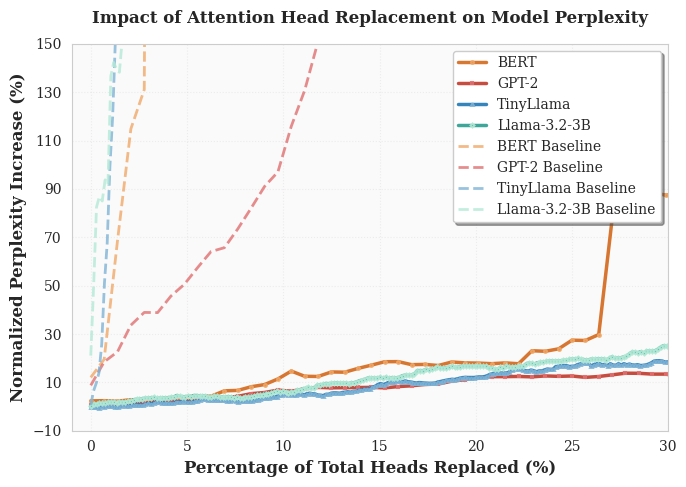

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 12
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10

ROW_COLORS = {
    "bert":      {"box": "#f0a868", "line": "#d4681a"},
    "gpt2":      {"box": "#e07070", "line": "#c0392b"},
    "tinyllama": {"box": "#7fb3d5", "line": "#1f77b4"},
    "llama3b":   {"box": "#b5ead7", "line": "#2a9d8f"},
}

fig, ax = plt.subplots(figsize=(7, 5))

MAX_X = 250
x_raw = np.arange(MAX_X)

total_heads_bert      = 144
total_heads_gpt2      = 144
total_heads_tinyllama = 704
total_heads_llama3b   = 672   # 28 layers x 24 heads

x_bert_pct      = (x_raw / total_heads_bert)      * 100
x_gpt2_pct      = (x_raw / total_heads_gpt2)      * 100
x_tinyllama_pct = (x_raw / total_heads_tinyllama)  * 100
x_llama3b_pct   = (x_raw / total_heads_llama3b)    * 100

bert_file               = "../results/replacement_run/bert_smart.csv"
gpt2_file               = "../results/replacement_run/gpt2_smart.csv"
tinyllama_file          = "../results/replacement_run/tinyllama_smart.csv"
llama3b_file            = "../results/replacement_run/llama3b_smart.csv"
bert_baseline_file      = "../results/replacement_run/bert_baseline.csv"
gpt2_baseline_file      = "../results/replacement_run/gpt2_baseline.csv"
tinyllama_baseline_file = "../results/replacement_run/tinyllama_baseline.csv"
llama3b_baseline_file   = "../results/replacement_run/llama3b_baseline.csv"

def load_data(file):
    data = pd.read_csv(file)["increase"].values[:MAX_X]
    return np.pad(data, (0, MAX_X - len(data)), constant_values=1050)

all_shuffles = {}
for f in os.listdir("../results/replacement_run/shuffles"):
    for key, prefix in [("bert", "bert_smart_shuffle"),
                         ("gpt2", "gpt2_smart_shuffle"),
                         ("tinyllama", "tinyllama_smart_shuffle"),
                         ("llama3b", "llama3b_smart_shuffle")]:
        if f.startswith(prefix) and f.endswith(".csv"):
            all_shuffles.setdefault(key, []).append(
                load_data(os.path.join("../results/replacement_run/shuffles", f)))

bert              = load_data(bert_file)
gpt2              = load_data(gpt2_file)
tiny_llama        = load_data(tinyllama_file)
llama3b           = load_data(llama3b_file)
bert_baseline     = load_data(bert_baseline_file)
gpt2_baseline     = load_data(gpt2_baseline_file)
tinyllama_baseline= load_data(tinyllama_baseline_file)
llama3b_baseline  = load_data(llama3b_baseline_file)

# ── Smart replacement lines ──
ax.plot(x_bert_pct, bert, color=ROW_COLORS["bert"]["line"], linewidth=2.5,
        label='BERT', marker='o', markersize=2,
        markerfacecolor=ROW_COLORS["bert"]["line"], markeredgewidth=1.5,
        markeredgecolor=ROW_COLORS["bert"]["box"], alpha=0.9)

ax.plot(x_gpt2_pct, gpt2, color=ROW_COLORS["gpt2"]["line"], linewidth=2.5,
        label='GPT-2', marker='s', markersize=2,
        markerfacecolor=ROW_COLORS["gpt2"]["line"], markeredgewidth=1.5,
        markeredgecolor=ROW_COLORS["gpt2"]["box"], alpha=0.9)

ax.plot(x_tinyllama_pct, tiny_llama, color=ROW_COLORS["tinyllama"]["line"], linewidth=2.5,
        label='TinyLlama', marker='^', markersize=2,
        markerfacecolor=ROW_COLORS["tinyllama"]["line"], markeredgewidth=1.5,
        markeredgecolor=ROW_COLORS["tinyllama"]["box"], alpha=0.9)

ax.plot(x_llama3b_pct, llama3b, color=ROW_COLORS["llama3b"]["line"], linewidth=2.5,
        label='Llama-3.2-3B', marker='D', markersize=2,
        markerfacecolor=ROW_COLORS["llama3b"]["line"], markeredgewidth=1.5,
        markeredgecolor=ROW_COLORS["llama3b"]["box"], alpha=0.9)

# ── Baselines ──
ax.plot(x_bert_pct,      bert_baseline,      color=ROW_COLORS["bert"]["box"],
        linestyle='--', linewidth=2, label='BERT Baseline', alpha=0.8)
ax.plot(x_gpt2_pct,      gpt2_baseline,      color=ROW_COLORS["gpt2"]["box"],
        linestyle='--', linewidth=2, label='GPT-2 Baseline', alpha=0.8)
ax.plot(x_tinyllama_pct, tinyllama_baseline, color=ROW_COLORS["tinyllama"]["box"],
        linestyle='--', linewidth=2, label='TinyLlama Baseline', alpha=0.8)
ax.plot(x_llama3b_pct,   llama3b_baseline,   color=ROW_COLORS["llama3b"]["box"],
        linestyle='--', linewidth=2, label='Llama-3.2-3B Baseline', alpha=0.8)

ax.set_xlabel('Percentage of Total Heads Replaced (%)', fontweight='bold')
ax.set_ylabel('Normalized Perplexity Increase (%)', fontweight='bold')
ax.set_title('Impact of Attention Head Replacement on Model Perplexity', fontweight='bold', pad=15)

ax.set_xlim(-1, 30)
ax.set_ylim(0, 150)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xticks(np.arange(0, 31, 5))
ax.set_yticks(np.arange(-10, 151, 20))

ax.legend(loc='upper right', frameon=True, shadow=True, fancybox=True)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('../results/plots/figure_4_3.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 4.4: Downstream Evaluation Accuracy Under Head Replacement

Reports benchmark performance across replacement settings to quantify downstream behavior changes after hypothesis-based head substitution.

In [28]:
# ============================================================
#  Run head replacement experiments
#  Assumes local data directory structure:
#    data/iou_scores_{model}.csv
#    data/generic_sentences.json
#    data/interpolation_k_{model}.csv
# ============================================================

np.random.seed(42)

def constrained_shuffle_df(df, sigma=2.0):
    """
    Shuffles the rows of a DataFrame based on their original 
    index position plus some Gaussian noise.
    """
    temp_df = df.copy().reset_index(drop=True)
    noise = np.random.normal(0, sigma, size=len(temp_df))
    temp_df['shuffle_pos'] = temp_df.index + noise
    shuffled_df = temp_df.sort_values('shuffle_pos').drop(columns=['shuffle_pos'])
    return shuffled_df.reset_index(drop=True)

n_shuffles = 10
os.makedirs("../results/replacement_run/shuffles", exist_ok=True)

for model_key in MODEL_CONFIGS.keys():
    if model_key == "bert": continue
    best_fits_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    
    if not os.path.exists(best_fits_csv):
        print(f"  [WARN] Missing: {best_fits_csv} — skipping shuffle for {model_key}")
        continue

    original_best_fits = pd.read_csv(best_fits_csv)
    # sort original best fits by best (highest) iou score to bias towards good programs
    original_best_fits = original_best_fits.sort_values(by="iou_score", ascending=False).reset_index(drop=True)
    
    for idx in range(n_shuffles):
        print(f"\n── Running replacement for {model_key} with shuffle {idx+1} ──")
        shuffled_best_fits_df = constrained_shuffle_df(original_best_fits, sigma=2.0)

        save_path = f"../results/replacement_run/shuffles/{model_key}_smart_shuffle_{idx+1}.csv"

        if model_key == "bert":
            run_replacement_experiment_bert(generic_sentences, shuffled_best_fits_df, all_programs, strategy="smart", save_file=save_path)
        elif model_key == "gpt2":
            run_replacement_experiment_gpt2(generic_sentences, shuffled_best_fits_df, all_programs, strategy="smart", save_file=save_path)
        elif model_key == "tinyllama":
            run_replacement_experiment_llama(generic_sentences, shuffled_best_fits_df, all_programs, strategy="smart", save_file=save_path)


── Running replacement for gpt2 with shuffle 1 ──
Calculating baseline perplexities...
Baseline complete. Mean PPL: 43.41
Running with strategy='smart', skip_spikes=True
k=01 | Head: (7, 2) | Program: initial_element_reinforcement | Mean PPL Inc: 0.0000%
k=02 | Head: (5, 1) | Program: cls_attention | Mean PPL Inc: 0.5649%
k=03 | Head: (6, 9) | Program: initial_element_reinforcement | Mean PPL Inc: 0.5649%
k=04 | Head: (9, 9) | Program: sentence_beginning_salience | Mean PPL Inc: 0.5127%
k=05 | Head: (7, 10) | Program: sentence_beginning_salience | Mean PPL Inc: 1.2943%
k=06 | Head: (4, 11) | Program: previous_attention | Mean PPL Inc: 2.1236%
k=07 | Head: (10, 10) | Program: sentence_beginning_salience | Mean PPL Inc: 2.6371%
k=08 | Head: (10, 8) | Program: sentence_beginning_salience | Mean PPL Inc: 2.5862%
k=09 | Head: (9, 11) | Program: sentence_beginning_salience | Mean PPL Inc: 2.6843%
k=10 | Head: (9, 6) | Program: sentence_beginning_salience | Mean PPL Inc: 2.8924%
k=11 | Head:

In [ ]:
# print best fits csv for gpt2

best_fits_gpt2 = pd.read_csv("../results/best_fits_gpt2.csv")
best_fits_gpt2 = best_fits_gpt2.sort_values(by="iou_score", ascending=False).reset_index(drop=True)
for idx, row in best_fits_gpt2.iterrows():
    print(f"L{int(row['layer'])}H{int(row['head'])} | Program: {all_programs[int(row['program_idx'])].__name__} | IOU: {row['iou_score']:.4f}")

In [33]:
# ============================================================
# Smart-Shuffle Top-3 Backtracking Experiment  (GPT-2 only)
#
# Steps 1-42 are hardcoded from the known-good run that goes
# negative. The shuffled backtracking search picks up from k=43,
# seeded with the real accepted_heads_mapping so hooks are correct.
#
# For each shuffle (steps 43+):
#   - constrained_shuffle the REMAINING heads (those not in seed)
#   - For each head try Rank-1 program (highest mean IOU).
#     If marginal PPL > 10% → try Rank-2 → Rank-3 → skip.
#   - Stop shuffle if cumulative increase > 1000%.
#
# Saves each shuffle to:
#   ../results/replacement_run/shuffles/gpt2_top3_shuffle_{idx}.csv
#
# Depends on (already defined in this notebook):
#   prepare_sentence, constrained_shuffle_df, all_programs, DATA_DIR
# ============================================================

import ast
import io
import pathlib
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# ── Config ────────────────────────────────────────────────────────────────────
N_SHUFFLES      = 32     # shuffles to run overnight
SPIKE_THRESHOLD = 8.0   # marginal % spike cutoff
CUMUL_LIMIT     = 66.0 # cumulative % that stops a shuffle early
TOP_K           = 3      # ranked fallbacks per head
SIGMA           = 30    # constrained-shuffle noise std-dev
NUM_SENTENCES   = 5
MODEL_KEY       = "gpt2"
# ──────────────────────────────────────────────────────────────────────────────

np.random.seed(42)
pathlib.Path("../results/replacement_run/shuffles").mkdir(parents=True, exist_ok=True)

# ── 1. Hardcoded seed — the 42 known-good replacements ───────────────────────
SEED_CSV = """\
k,head,program,strategy,increase,kl_div
1,"(10, 2)",initial_token_attention,smart,0.008307712197430366,0.001065253290653345
2,"(10, 1)",initial_token_attention,smart,0.008615101288974697,0.002011389515728297
3,"(6, 9)",cls_attention,smart,-0.6633480896656324,0.0035132152349979153
4,"(5, 1)",cls_attention,smart,-0.6251862761961215,0.006047547392081469
5,"(7, 2)",cls_attention,smart,-0.46079214514841105,0.007481090293440502
6,"(4, 11)",previous_attention,smart,-0.13227185889340462,0.008721561353304423
7,"(7, 1)",initial_token_attention,smart,0.17710685905574153,0.010167443108512088
8,"(11, 9)",initial_token_attention,smart,-0.21351424777165198,0.012792042766814121
9,"(10, 0)",initial_token_attention,smart,-0.20580384016925668,0.014605110042029992
10,"(11, 2)",initial_token_attention,smart,1.0038506419448705,0.017880274574272336
11,"(7, 7)",initial_token_attention,smart,0.9243134907948786,0.01833117724279873
12,"(5, 5)",initial_token_attention,smart,0.6361639857461907,0.020740094240172768
13,"(6, 6)",initial_token_attention,smart,0.4549912320044895,0.022376552417408675
14,"(10, 8)",initial_token_attention,smart,0.10113471498162603,0.024186684540472923
15,"(3, 0)",initial_token_attention,smart,-0.07333341108278439,0.024121518884785472
16,"(0, 1)",repeated_attention,smart,-0.08229663632499523,0.02414339571725577
17,"(9, 6)",initial_token_attention,smart,0.08397755045552856,0.02528198662563227
18,"(9, 9)",sentence_start_dominance,smart,0.20214879514749776,0.028346376998815686
19,"(9, 5)",sentence_initial_dominance,smart,-1.720343203993684,0.028143282887758688
20,"(8, 1)",initial_token_attention,smart,-1.9935828405133866,0.03228664654074237
21,"(10, 10)",initial_token_attention,smart,-1.8115494947969548,0.033806850896216926
22,"(9, 11)",initial_token_attention,smart,-1.4920480247818013,0.03443914557225071
23,"(3, 4)",initial_token_attention,smart,-1.6696160646077265,0.03623579588253051
24,"(11, 7)",initial_token_attention,smart,-0.7344831094723496,0.039611174650490286
25,"(11, 5)",initial_token_attention,smart,-0.2976022499177347,0.04332037792075425
26,"(9, 4)",initial_token_attention,smart,-0.3462717356001825,0.043809333558892834
27,"(7, 10)",initial_token_attention,smart,-0.1648400476295224,0.04461271269246936
28,"(6, 10)",initial_token_attention,smart,0.02574922911360261,0.04931675942847505
29,"(9, 8)",sentence_initial_dominance,smart,-1.440972483437424,0.0490389868686907
30,"(10, 6)",initial_token_attention,smart,-1.36646972737408,0.0513438879372552
31,"(11, 1)",sentence_initial_dominance,smart,-3.0456133521445476,0.051345947170630096
32,"(7, 11)",initial_token_attention,smart,-2.9486139101015043,0.054554718919098376
33,"(6, 2)",sentence_initial_dominance,smart,-4.1299547629687,0.05475393987959251
34,"(7, 6)",sentence_initial_dominance,smart,-5.068048806331123,0.054423859217204155
35,"(8, 3)",initial_token_attention,smart,-4.902484822870978,0.05675411381525919
36,"(5, 9)",sentence_initial_dominance,smart,-5.571243742067339,0.056279577629175036
37,"(10, 3)",sentence_initial_dominance,smart,-7.450234561946978,0.05592323972377926
38,"(5, 0)",initial_token_attention,smart,-7.127710350251196,0.06024578050011769
39,"(8, 11)",sentence_initial_dominance,smart,-8.657863908075072,0.060319892903789876
40,"(9, 1)",initial_token_attention,smart,-8.464149821736362,0.06372750320471823
41,"(8, 0)",sentence_initial_dominance,smart,-10.026851892198312,0.06297878146870062
42,"(4, 10)",initial_token_attention,smart,-9.929107592011958,0.06535566914826632\
"""

seed_df = pd.read_csv(io.StringIO(SEED_CSV))

# Build the seed accepted_heads_mapping: list of (head_tuple, prog_name)
# This is what the hook lookup is built from — must match original format exactly.
SEED_MAPPING = [
    (tuple(ast.literal_eval(row["head"])), row["program"])
    for _, row in seed_df.iterrows()
]
SEED_HEADS = set(h for h, _ in SEED_MAPPING)
SEED_PREV_CUMULATIVE = float(seed_df.iloc[-1]["increase"])  # -9.929...

print(f"[INFO] Seed loaded: {len(SEED_MAPPING)} hardcoded replacements.")
print(f"[INFO] Seed cumulative PPL increase: {SEED_PREV_CUMULATIVE:.4f}%")

# ── 2. Build top-3 program mapping from IOU scores ───────────────────────────
iou_csv  = f"{DATA_DIR}/iou_scores_{MODEL_KEY}.csv"
iou_df   = pd.read_csv(iou_csv)
mean_iou = (
    iou_df.groupby(["layer", "head", "program_idx"])["iou_score"]
    .mean()
    .reset_index()
)

head_program_map = {}  # (layer, head) -> [(rank, prog_name), ...]
rank1_rows       = []  # for shuffling — only non-seed heads

for (layer, head), grp in mean_iou.groupby(["layer", "head"]):
    top    = grp.nlargest(TOP_K, "iou_score").reset_index(drop=True)
    ranked = []
    for rank_idx, (_, row) in enumerate(top.iterrows(), start=1):
        p_idx     = int(row["program_idx"])
        prog_name = all_programs[p_idx].__name__
        ranked.append((rank_idx, prog_name))
        if rank_idx == 1 and (int(layer), int(head)) not in SEED_HEADS:
            rank1_rows.append({"layer": layer, "head": head, "iou_score": row["iou_score"]})
    head_program_map[(int(layer), int(head))] = ranked

# Remaining heads (not in seed), ordered by rank-1 IOU desc — this is what we shuffle
remaining_rank1_df = pd.DataFrame(rank1_rows).sort_values("iou_score", ascending=False).reset_index(drop=True)

print(f"[INFO] {len(head_program_map)} total unique heads, {len(remaining_rank1_df)} remaining after seed.")

# ── 3. Baseline (computed once, reused across all shuffles) ───────────────────
tokenizer  = GPT2Tokenizer.from_pretrained("gpt2")
eval_sents = pd.read_json("../data/generic_sentences.json")[0].tolist()[:NUM_SENTENCES]

print("Calculating baseline perplexities...")
_base  = GPT2LMHeadModel.from_pretrained("gpt2").to("cuda" if torch.cuda.is_available() else "cpu")
_base.eval()
device          = next(_base.parameters()).device
baseline_ppls   = []
baseline_logits = []

for sent in eval_sents:
    active = prepare_sentence(sent, mode="last_word")
    toks   = tokenizer(active, return_tensors="pt").to(device)
    with torch.no_grad():
        out = _base(**toks, labels=toks["input_ids"])
        baseline_ppls.append(torch.exp(out.loss).item())
        baseline_logits.append(out.logits[:, -1, :])

del _base
torch.cuda.empty_cache()
print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}\n")

# ── 4. Hook factory — copied verbatim from run_replacement_experiment_gpt2 ────
def make_smart_hook(lookup, programs_list):
    def compound_hook(module, input, output):
        context_layer = output[0]
        batch, seq_len, hidden_dim = context_layer.shape
        num_heads, head_dim = 12, hidden_dim // 12
        modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
        current_sent = getattr(module, '_current_sentence', None)
        if current_sent is None:
            return output
        for head_idx in range(num_heads):
            key = (module.layer_id, head_idx)
            if key in lookup:
                prog_name = lookup[key]
                prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                if prog:
                    try:
                        _, hypo_mat = prog(current_sent, tokenizer)
                        if hypo_mat is not None:
                            hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                            modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                    except Exception:
                        pass
        return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
    return compound_hook

# ── 5. Trial evaluator — inner loop from run_replacement_experiment_gpt2 ──────
def evaluate_candidate(accepted_heads_mapping, candidate_head, candidate_prog):
    """
    Loads a fresh GPT-2, registers hooks for all accepted heads + candidate,
    evaluates, cleans up. Returns (mean_pct_increase, mean_kl_div).

    accepted_heads_mapping: list of (head_tuple, prog_name)
    """
    trial_mapping   = accepted_heads_mapping + [(candidate_head, candidate_prog)]
    trial_lookup    = {tuple(map(int, h)): p for h, p in trial_mapping}
    relevant_layers = set(h[0] for h in trial_lookup)

    model_k = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    model_k.eval()

    hook_fn      = make_smart_hook(trial_lookup, all_programs)
    hook_handles = []
    for l_idx in range(12):
        target          = model_k.transformer.h[l_idx].attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            hook_handles.append(target.register_forward_hook(hook_fn))

    replaced_ppls, kl_divergences = [], []
    for i, sent in enumerate(eval_sents):
        active_sent = prepare_sentence(sent, mode="last_word")
        for l_idx in relevant_layers:
            model_k.transformer.h[l_idx].attn._current_sentence = active_sent
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            out_rep = model_k(**toks, labels=toks["input_ids"])
            replaced_ppls.append(torch.exp(out_rep.loss).item())
            log_probs_new  = F.log_softmax(out_rep.logits[:, -1, :], dim=-1)
            probs_baseline = F.softmax(baseline_logits[i], dim=-1)
            kl_divergences.append(F.kl_div(log_probs_new, probs_baseline, reduction='batchmean').item())

    for handle in hook_handles:
        handle.remove()
    del model_k
    torch.cuda.empty_cache()

    mean_pct = float(np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)]))
    mean_kl  = float(np.mean(kl_divergences))
    return mean_pct, mean_kl

# ── 6. Outer shuffle loop ─────────────────────────────────────────────────────
for shuffle_idx in range(1, N_SHUFFLES + 1):
    print(f"── Shuffle {shuffle_idx}/{N_SHUFFLES} ──────────────────────────────")

    # Seed results are identical across every shuffle — copy them in directly
    shuffle_results = [
        {
            "k":             int(row["k"]),
            "head":          row["head"],
            "program":       row["program"],
            "accepted_rank": 1,          # seed rows are always rank-1 by definition
            "strategy":      "smart",
            "increase":      float(row["increase"]),
            "kl_div":        float(row["kl_div"]),
            "shuffle_idx":   shuffle_idx,
        }
        for _, row in seed_df.iterrows()
    ]
    for row in shuffle_results:
        print(f"  [SEED] k={row['k']:03d} | Head {row['head']} | '{row['program']}' | cumul={row['increase']:.4f}%")

    # Seed the accepted mapping so hooks include all 42 replacements
    accepted_heads_mapping = list(SEED_MAPPING)   # copy — mutated per shuffle
    k               = len(SEED_MAPPING)           # 42
    prev_cumulative = SEED_PREV_CUMULATIVE        # -9.929...

    # Shuffle only the remaining (non-seed) heads
    shuffled_remaining = constrained_shuffle_df(remaining_rank1_df, sigma=SIGMA)
    head_order = [(int(r["layer"]), int(r["head"])) for _, r in shuffled_remaining.iterrows()]

    for head_tuple in head_order:
        candidates = head_program_map.get(head_tuple, [])
        if not candidates:
            print(f"  [WARN] No candidates for head {head_tuple}. Skipping.")
            continue

        accepted_rank = None
        accepted_prog = None
        mean_pct      = None
        mean_kl       = None

        # ── Backtracking: Rank 1 → 2 → 3 ──────────────────────────────────
        for rank, prog_name in candidates:
            mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
            marginal          = mean_pct - prev_cumulative

            if marginal > SPIKE_THRESHOLD:
                n_remaining = len(candidates) - rank
                print(
                    f"  [SPIKE] Head {head_tuple} Rank-{rank} '{prog_name}' "
                    f"marginal={marginal:.2f}%. "
                    + (f"Trying Rank-{rank+1}..." if n_remaining > 0 else "All ranks exhausted.")
                )
                torch.cuda.empty_cache()
                continue

            accepted_rank = rank
            accepted_prog = prog_name
            break

        if accepted_rank is None:
            print(f"  [SKIP] Head {head_tuple}: all {len(candidates)} programs spiked.")
            continue

        if mean_pct > CUMUL_LIMIT:
            print(f"  [STOP] Cumulative {mean_pct:.2f}% > {CUMUL_LIMIT}%. Ending shuffle {shuffle_idx} early.")
            break

        k += 1
        accepted_heads_mapping.append((head_tuple, accepted_prog))
        prev_cumulative = mean_pct

        shuffle_results.append({
            "k":             k,
            "head":          str(head_tuple),
            "program":       accepted_prog,
            "accepted_rank": accepted_rank,
            "strategy":      "smart",
            "increase":      round(mean_pct, 6),
            "kl_div":        round(mean_kl, 6),
            "shuffle_idx":   shuffle_idx,
        })
        print(f"  k={k:03d} | Head {head_tuple} | Rank-{accepted_rank} '{accepted_prog}' | cumul={mean_pct:.4f}%")

    # Save this shuffle
    save_path = f"../results/replacement_run/shuffles/{MODEL_KEY}_top3_shuffle_{shuffle_idx}.csv"
    pd.DataFrame(shuffle_results).to_csv(save_path, index=False)
    print(f"  ✓ Saved {len(shuffle_results)} rows → {save_path}\n")

print(f"[DONE] All {N_SHUFFLES} shuffles complete.")

[INFO] Seed loaded: 42 hardcoded replacements.
[INFO] Seed cumulative PPL increase: -9.9291%
[INFO] 144 total unique heads, 102 remaining after seed.
Calculating baseline perplexities...
Baseline complete. Mean PPL: 43.41

── Shuffle 1/32 ──────────────────────────────
  [SEED] k=001 | Head (10, 2) | 'initial_token_attention' | cumul=0.0083%
  [SEED] k=002 | Head (10, 1) | 'initial_token_attention' | cumul=0.0086%
  [SEED] k=003 | Head (6, 9) | 'cls_attention' | cumul=-0.6633%
  [SEED] k=004 | Head (5, 1) | 'cls_attention' | cumul=-0.6252%
  [SEED] k=005 | Head (7, 2) | 'cls_attention' | cumul=-0.4608%
  [SEED] k=006 | Head (4, 11) | 'previous_attention' | cumul=-0.1323%
  [SEED] k=007 | Head (7, 1) | 'initial_token_attention' | cumul=0.1771%
  [SEED] k=008 | Head (11, 9) | 'initial_token_attention' | cumul=-0.2135%
  [SEED] k=009 | Head (10, 0) | 'initial_token_attention' | cumul=-0.2058%
  [SEED] k=010 | Head (11, 2) | 'initial_token_attention' | cumul=1.0039%
  [SEED] k=011 | Head (

In [35]:
# ============================================================
# Smart-Shuffle Top-3 Backtracking Experiment  (GPT-2 only)
#
# Steps 1-42 are hardcoded from the known-good run that goes
# negative. The shuffled backtracking search picks up from k=43,
# seeded with the real accepted_heads_mapping so hooks are correct.
#
# For each shuffle (steps 43+):
#   - constrained_shuffle the REMAINING heads (those not in seed)
#   - For each head try Rank-1 program (highest mean IOU).
#     If marginal PPL > 10% → try Rank-2 → Rank-3 → skip.
#   - Stop shuffle if cumulative increase > 1000%.
#
# Saves each shuffle to:
#   ../results/replacement_run/shuffles/gpt2_top3_shuffle_{idx}.csv
#
# Depends on (already defined in this notebook):
#   prepare_sentence, constrained_shuffle_df, all_programs, DATA_DIR
# ============================================================

import ast
import io
import pathlib
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# ── Config ────────────────────────────────────────────────────────────────────
N_SHUFFLES      = 32     # shuffles to run overnight
SPIKE_THRESHOLD = 5.0   # marginal % spike cutoff
CUMUL_LIMIT     = 25.0 # cumulative % that stops a shuffle early
TOP_K           = 5      # ranked fallbacks per head
SIGMA           = 20    # constrained-shuffle noise std-dev
NUM_SENTENCES   = 7
MODEL_KEY       = "gpt2"
# ──────────────────────────────────────────────────────────────────────────────

np.random.seed(42)
pathlib.Path("../results/replacement_run/shuffles").mkdir(parents=True, exist_ok=True)

# ── 1. Hardcoded seed — the 42 known-good replacements ───────────────────────
SEED_CSV = """\
k,head,program,strategy,increase,kl_div
1,"(10, 2)",initial_token_attention,smart,0.008307712197430366,0.001065253290653345
2,"(10, 1)",initial_token_attention,smart,0.008615101288974697,0.002011389515728297
3,"(6, 9)",cls_attention,smart,-0.6633480896656324,0.0035132152349979153
4,"(5, 1)",cls_attention,smart,-0.6251862761961215,0.006047547392081469
5,"(7, 2)",cls_attention,smart,-0.46079214514841105,0.007481090293440502
6,"(4, 11)",previous_attention,smart,-0.13227185889340462,0.008721561353304423
7,"(7, 1)",initial_token_attention,smart,0.17710685905574153,0.010167443108512088
8,"(11, 9)",initial_token_attention,smart,-0.21351424777165198,0.012792042766814121
9,"(10, 0)",initial_token_attention,smart,-0.20580384016925668,0.014605110042029992
10,"(11, 2)",initial_token_attention,smart,1.0038506419448705,0.017880274574272336
11,"(7, 7)",initial_token_attention,smart,0.9243134907948786,0.01833117724279873
12,"(5, 5)",initial_token_attention,smart,0.6361639857461907,0.020740094240172768
13,"(6, 6)",initial_token_attention,smart,0.4549912320044895,0.022376552417408675
14,"(10, 8)",initial_token_attention,smart,0.10113471498162603,0.024186684540472923
15,"(3, 0)",initial_token_attention,smart,-0.07333341108278439,0.024121518884785472
16,"(0, 1)",repeated_attention,smart,-0.08229663632499523,0.02414339571725577
17,"(9, 6)",initial_token_attention,smart,0.08397755045552856,0.02528198662563227
18,"(9, 9)",sentence_start_dominance,smart,0.20214879514749776,0.028346376998815686
19,"(9, 5)",sentence_initial_dominance,smart,-1.720343203993684,0.028143282887758688
20,"(8, 1)",initial_token_attention,smart,-1.9935828405133866,0.03228664654074237
21,"(10, 10)",initial_token_attention,smart,-1.8115494947969548,0.033806850896216926
22,"(9, 11)",initial_token_attention,smart,-1.4920480247818013,0.03443914557225071
23,"(3, 4)",initial_token_attention,smart,-1.6696160646077265,0.03623579588253051
24,"(11, 7)",initial_token_attention,smart,-0.7344831094723496,0.039611174650490286
25,"(11, 5)",initial_token_attention,smart,-0.2976022499177347,0.04332037792075425
26,"(9, 4)",initial_token_attention,smart,-0.3462717356001825,0.043809333558892834
27,"(7, 10)",initial_token_attention,smart,-0.1648400476295224,0.04461271269246936
28,"(6, 10)",initial_token_attention,smart,0.02574922911360261,0.04931675942847505
29,"(9, 8)",sentence_initial_dominance,smart,-1.440972483437424,0.0490389868686907
30,"(10, 6)",initial_token_attention,smart,-1.36646972737408,0.0513438879372552
31,"(11, 1)",sentence_initial_dominance,smart,-3.0456133521445476,0.051345947170630096
32,"(7, 11)",initial_token_attention,smart,-2.9486139101015043,0.054554718919098376
33,"(6, 2)",sentence_initial_dominance,smart,-4.1299547629687,0.05475393987959251
34,"(7, 6)",sentence_initial_dominance,smart,-5.068048806331123,0.054423859217204155
35,"(8, 3)",initial_token_attention,smart,-4.902484822870978,0.05675411381525919
36,"(5, 9)",sentence_initial_dominance,smart,-5.571243742067339,0.056279577629175036
37,"(10, 3)",sentence_initial_dominance,smart,-7.450234561946978,0.05592323972377926
38,"(5, 0)",initial_token_attention,smart,-7.127710350251196,0.06024578050011769
39,"(8, 11)",sentence_initial_dominance,smart,-8.657863908075072,0.060319892903789876
40,"(9, 1)",initial_token_attention,smart,-8.464149821736362,0.06372750320471823
41,"(8, 0)",sentence_initial_dominance,smart,-10.026851892198312,0.06297878146870062
42,"(4, 10)",initial_token_attention,smart,-9.929107592011958,0.06535566914826632\
"""

seed_df = pd.read_csv(io.StringIO(SEED_CSV))

# Build the seed accepted_heads_mapping: list of (head_tuple, prog_name)
# This is what the hook lookup is built from — must match original format exactly.
SEED_MAPPING = [
    (tuple(ast.literal_eval(row["head"])), row["program"])
    for _, row in seed_df.iterrows()
]
SEED_HEADS = set(h for h, _ in SEED_MAPPING)
SEED_PREV_CUMULATIVE = float(seed_df.iloc[-1]["increase"])  # -9.929...

print(f"[INFO] Seed loaded: {len(SEED_MAPPING)} hardcoded replacements.")
print(f"[INFO] Seed cumulative PPL increase: {SEED_PREV_CUMULATIVE:.4f}%")

# ── 2. Build top-3 program mapping from IOU scores ───────────────────────────
iou_csv  = f"{DATA_DIR}/iou_scores_{MODEL_KEY}.csv"
iou_df   = pd.read_csv(iou_csv)
mean_iou = (
    iou_df.groupby(["layer", "head", "program_idx"])["iou_score"]
    .mean()
    .reset_index()
)

head_program_map = {}  # (layer, head) -> [(rank, prog_name), ...]
rank1_rows       = []  # for shuffling — only non-seed heads

for (layer, head), grp in mean_iou.groupby(["layer", "head"]):
    top    = grp.nlargest(TOP_K, "iou_score").reset_index(drop=True)
    ranked = []
    for rank_idx, (_, row) in enumerate(top.iterrows(), start=1):
        p_idx     = int(row["program_idx"])
        prog_name = all_programs[p_idx].__name__
        ranked.append((rank_idx, prog_name))
        if rank_idx == 1 and (int(layer), int(head)) not in SEED_HEADS:
            rank1_rows.append({"layer": layer, "head": head, "iou_score": row["iou_score"]})
    head_program_map[(int(layer), int(head))] = ranked

# Remaining heads (not in seed), ordered by rank-1 IOU desc — this is what we shuffle
remaining_rank1_df = pd.DataFrame(rank1_rows).sort_values("iou_score", ascending=False).reset_index(drop=True)

print(f"[INFO] {len(head_program_map)} total unique heads, {len(remaining_rank1_df)} remaining after seed.")

# ── 3. Baseline (computed once, reused across all shuffles) ───────────────────
tokenizer  = GPT2Tokenizer.from_pretrained("gpt2")
eval_sents = pd.read_json("../data/generic_sentences.json")[0].tolist()[:NUM_SENTENCES]

print("Calculating baseline perplexities...")
_base  = GPT2LMHeadModel.from_pretrained("gpt2").to("cuda" if torch.cuda.is_available() else "cpu")
_base.eval()
device          = next(_base.parameters()).device
baseline_ppls   = []
baseline_logits = []

for sent in eval_sents:
    active = prepare_sentence(sent, mode="last_word")
    toks   = tokenizer(active, return_tensors="pt").to(device)
    with torch.no_grad():
        out = _base(**toks, labels=toks["input_ids"])
        baseline_ppls.append(torch.exp(out.loss).item())
        baseline_logits.append(out.logits[:, -1, :])

del _base
torch.cuda.empty_cache()
print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}\n")

# ── 4. Hook factory — copied verbatim from run_replacement_experiment_gpt2 ────
def make_smart_hook(lookup, programs_list):
    def compound_hook(module, input, output):
        context_layer = output[0]
        batch, seq_len, hidden_dim = context_layer.shape
        num_heads, head_dim = 12, hidden_dim // 12
        modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
        current_sent = getattr(module, '_current_sentence', None)
        if current_sent is None:
            return output
        for head_idx in range(num_heads):
            key = (module.layer_id, head_idx)
            if key in lookup:
                prog_name = lookup[key]
                prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                if prog:
                    try:
                        _, hypo_mat = prog(current_sent, tokenizer)
                        if hypo_mat is not None:
                            hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                            modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                    except Exception:
                        pass
        return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
    return compound_hook

# ── 5. Trial evaluator — inner loop from run_replacement_experiment_gpt2 ──────
def evaluate_candidate(accepted_heads_mapping, candidate_head, candidate_prog):
    """
    Loads a fresh GPT-2, registers hooks for all accepted heads + candidate,
    evaluates, cleans up. Returns (mean_pct_increase, mean_kl_div).

    accepted_heads_mapping: list of (head_tuple, prog_name)
    """
    trial_mapping   = accepted_heads_mapping + [(candidate_head, candidate_prog)]
    trial_lookup    = {tuple(map(int, h)): p for h, p in trial_mapping}
    relevant_layers = set(h[0] for h in trial_lookup)

    model_k = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    model_k.eval()

    hook_fn      = make_smart_hook(trial_lookup, all_programs)
    hook_handles = []
    for l_idx in range(12):
        target          = model_k.transformer.h[l_idx].attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            hook_handles.append(target.register_forward_hook(hook_fn))

    replaced_ppls, kl_divergences = [], []
    for i, sent in enumerate(eval_sents):
        active_sent = prepare_sentence(sent, mode="last_word")
        for l_idx in relevant_layers:
            model_k.transformer.h[l_idx].attn._current_sentence = active_sent
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            out_rep = model_k(**toks, labels=toks["input_ids"])
            replaced_ppls.append(torch.exp(out_rep.loss).item())
            log_probs_new  = F.log_softmax(out_rep.logits[:, -1, :], dim=-1)
            probs_baseline = F.softmax(baseline_logits[i], dim=-1)
            kl_divergences.append(F.kl_div(log_probs_new, probs_baseline, reduction='batchmean').item())

    for handle in hook_handles:
        handle.remove()
    del model_k
    torch.cuda.empty_cache()

    mean_pct = float(np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)]))
    mean_kl  = float(np.mean(kl_divergences))
    return mean_pct, mean_kl

# ── 6. Outer shuffle loop ─────────────────────────────────────────────────────
for shuffle_idx in range(1, N_SHUFFLES + 1):
    print(f"── Shuffle {shuffle_idx}/{N_SHUFFLES} ──────────────────────────────")

    # Seed results are identical across every shuffle — copy them in directly
    shuffle_results = [
        {
            "k":             int(row["k"]),
            "head":          row["head"],
            "program":       row["program"],
            "accepted_rank": 1,          # seed rows are always rank-1 by definition
            "strategy":      "smart",
            "increase":      float(row["increase"]),
            "kl_div":        float(row["kl_div"]),
            "shuffle_idx":   shuffle_idx,
        }
        for _, row in seed_df.iterrows()
    ]
    for row in shuffle_results:
        print(f"  [SEED] k={row['k']:03d} | Head {row['head']} | '{row['program']}' | cumul={row['increase']:.4f}%")

    # Seed the accepted mapping so hooks include all 42 replacements
    accepted_heads_mapping = list(SEED_MAPPING)   # copy — mutated per shuffle
    k               = len(SEED_MAPPING)           # 42
    prev_cumulative = SEED_PREV_CUMULATIVE        # -9.929...

    # Shuffle only the remaining (non-seed) heads
    shuffled_remaining = constrained_shuffle_df(remaining_rank1_df, sigma=SIGMA)
    head_order = [(int(r["layer"]), int(r["head"])) for _, r in shuffled_remaining.iterrows()]

    for head_tuple in head_order:
        candidates = head_program_map.get(head_tuple, [])
        if not candidates:
            print(f"  [WARN] No candidates for head {head_tuple}. Skipping.")
            continue

        accepted_rank = None
        accepted_prog = None
        mean_pct      = None
        mean_kl       = None

        # ── Backtracking: Rank 1 → 2 → 3 ──────────────────────────────────
        for rank, prog_name in candidates:
            mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
            marginal          = mean_pct - prev_cumulative

            if marginal > SPIKE_THRESHOLD:
                n_remaining = len(candidates) - rank
                print(
                    f"  [SPIKE] Head {head_tuple} Rank-{rank} '{prog_name}' "
                    f"marginal={marginal:.2f}%. "
                    + (f"Trying Rank-{rank+1}..." if n_remaining > 0 else "All ranks exhausted.")
                )
                torch.cuda.empty_cache()
                continue

            accepted_rank = rank
            accepted_prog = prog_name
            break

        if accepted_rank is None:
            print(f"  [SKIP] Head {head_tuple}: all {len(candidates)} programs spiked.")
            continue

        if mean_pct > CUMUL_LIMIT:
            print(f"  [STOP] Cumulative {mean_pct:.2f}% > {CUMUL_LIMIT}%. Ending shuffle {shuffle_idx} early.")
            break

        k += 1
        accepted_heads_mapping.append((head_tuple, accepted_prog))
        prev_cumulative = mean_pct

        shuffle_results.append({
            "k":             k,
            "head":          str(head_tuple),
            "program":       accepted_prog,
            "accepted_rank": accepted_rank,
            "strategy":      "smart",
            "increase":      round(mean_pct, 6),
            "kl_div":        round(mean_kl, 6),
            "shuffle_idx":   shuffle_idx,
        })
        print(f"  k={k:03d} | Head {head_tuple} | Rank-{accepted_rank} '{accepted_prog}' | cumul={mean_pct:.4f}%")

    # Save this shuffle
    save_path = f"../results/replacement_run/shuffles/{MODEL_KEY}_top3_shuffle_{shuffle_idx+32}.csv"
    pd.DataFrame(shuffle_results).to_csv(save_path, index=False)
    print(f"  ✓ Saved {len(shuffle_results)} rows → {save_path}\n")

print(f"[DONE] All {N_SHUFFLES} shuffles complete.")

[INFO] Seed loaded: 42 hardcoded replacements.
[INFO] Seed cumulative PPL increase: -9.9291%
[INFO] 144 total unique heads, 102 remaining after seed.
Calculating baseline perplexities...
Baseline complete. Mean PPL: 44.11

── Shuffle 1/32 ──────────────────────────────
  [SEED] k=001 | Head (10, 2) | 'initial_token_attention' | cumul=0.0083%
  [SEED] k=002 | Head (10, 1) | 'initial_token_attention' | cumul=0.0086%
  [SEED] k=003 | Head (6, 9) | 'cls_attention' | cumul=-0.6633%
  [SEED] k=004 | Head (5, 1) | 'cls_attention' | cumul=-0.6252%
  [SEED] k=005 | Head (7, 2) | 'cls_attention' | cumul=-0.4608%
  [SEED] k=006 | Head (4, 11) | 'previous_attention' | cumul=-0.1323%
  [SEED] k=007 | Head (7, 1) | 'initial_token_attention' | cumul=0.1771%
  [SEED] k=008 | Head (11, 9) | 'initial_token_attention' | cumul=-0.2135%
  [SEED] k=009 | Head (10, 0) | 'initial_token_attention' | cumul=-0.2058%
  [SEED] k=010 | Head (11, 2) | 'initial_token_attention' | cumul=1.0039%
  [SEED] k=011 | Head (

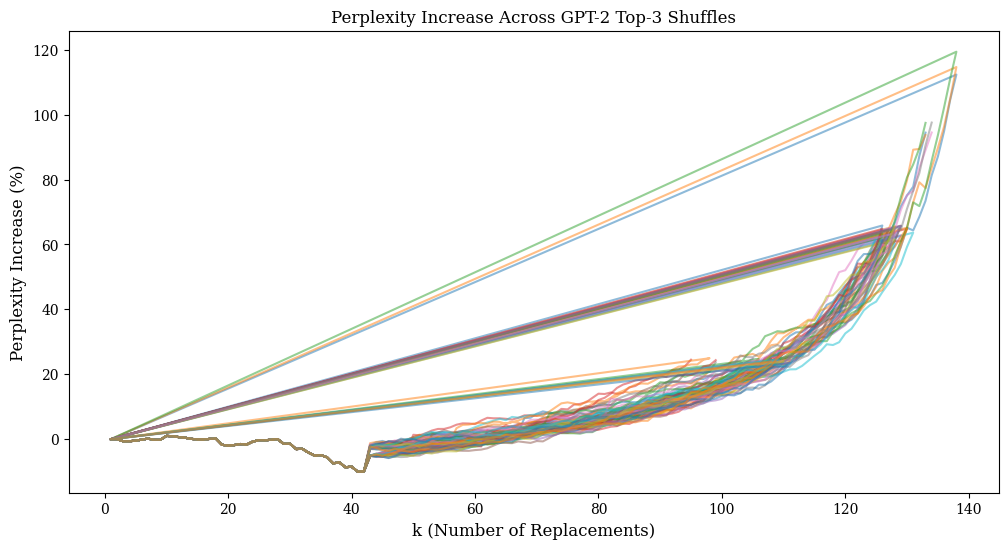

In [ ]:
# read the 72 shuffles from paper_results\results\replacement_run\shuffles\gpt2_top3_shuffle_1.csv and plot their increase on same plot, alpha 0.5, with a line for the mean increase across shuffles at each k, and a shaded area for the std deviation across shuffles at each k. Save the plot as gpt2_top3_shuffles.png

from pathlib import Path
import matplotlib.pyplot as plt

# Read all shuffle CSVs
shuffle_dir = Path("../results/replacement_run/shuffles")
shuffle_files = list(shuffle_dir.glob("gpt2_top3_shuffle_*.csv"))
all_shuffles = []
for file in shuffle_files:
    df = pd.read_csv(file)
    all_shuffles.append(df)

# Concatenate all shuffles into a single DataFrame
shuffles_df = pd.concat(all_shuffles, ignore_index=True)
# Group by 'k' to calculate mean and std deviation
grouped = shuffles_df.groupby('k')['increase'].agg(['mean', 'std']).reset_index()
# Plotting
plt.figure(figsize=(12, 6))
# Plot each shuffle with low alpha
for shuffle_idx in shuffles_df['shuffle_idx'].unique():
    subset = shuffles_df[shuffles_df['shuffle_idx'] == shuffle_idx]
    plt.plot(subset['k'], subset['increase'], alpha=0.5, label=f'Shuffle {shuffle_idx}')
# Plot mean increase with std deviation shaded area
# plt.plot(grouped['k'], grouped['mean'], color='black', label='Mean Increase', linewidth=2)
# plt.fill_between(grouped['k'], grouped['mean'] - grouped['std'], grouped['mean'] + grouped['std'], color='gray', alpha=0.3, label='Std Deviation')
plt.xlabel('k (Number of Replacements)')
plt.ylabel('Perplexity Increase (%)')
plt.title('Perplexity Increase Across GPT-2 Top-3 Shuffles')
# plt.legend()
plt.grid()

# plt.savefig("gpt2_top3_shuffles.png")
plt.show()

In [9]:
from pathlib import Path
import ast
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BertForMaskedLM, GPT2LMHeadModel, GPT2Tokenizer

import logging
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

shuffle_dir = Path("../results/replacement_run/shuffles")
best_fits_folder = Path("../results")

# file, number of heads still needed to reach 100% replacement
get_to_100percent_replacements = [
    (shuffle_dir / "gpt2_smart_shuffle_8.csv", 3),
    (shuffle_dir / "bert_smart_shuffle_5.csv", 35),
    (shuffle_dir / "tinyllama_smart_shuffle_2.csv", 454),
]

head_counts = {
    "bert": 144,
    "gpt2": 144,
    "tinyllama": 704,
}

SPIKE_THRESHOLD = 100.0
TAIL_HEADS_TO_SEARCH = 104
TAIL_CANDIDATE_LIMIT = 3
NUM_SENTENCES = 5
TINYLLAMA_MODEL_ID = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"


def _parse_model_key(csv_path: Path) -> str:
    return csv_path.name.split("_")[0].lower()


def _parse_head(raw_head):
    if isinstance(raw_head, tuple):
        return (int(raw_head[0]), int(raw_head[1]))
    if isinstance(raw_head, list):
        return (int(raw_head[0]), int(raw_head[1]))
    if isinstance(raw_head, str):
        parsed = ast.literal_eval(raw_head)
        return (int(parsed[0]), int(parsed[1]))
    raise ValueError(f"Unrecognized head format: {raw_head}")


def _load_eval_sentences():
    return pd.read_json("../data/generic_sentences.json")[0].tolist()[:NUM_SENTENCES]


def _mean_sequence_kl(logits_new, logits_base):
    return F.kl_div(
        F.log_softmax(logits_new, dim=-1),
        F.softmax(logits_base, dim=-1),
        reduction="batchmean",
    ).item()


def _build_seed_mapping(seed_df):
    return [(_parse_head(row["head"]), str(row["program"])) for _, row in seed_df.iterrows()]


def _build_head_program_candidates(model_key, top_k=TAIL_CANDIDATE_LIMIT):
    iou_csv = Path(DATA_DIR) / f"iou_scores_{model_key}.csv"
    iou_df = pd.read_csv(iou_csv)
    mean_iou = (
        iou_df.groupby(["layer", "head", "program_idx"])["iou_score"]
        .mean()
        .reset_index()
    )

    head_program_candidates = {}
    for (layer, head), grp in mean_iou.groupby(["layer", "head"]):
        top = grp.nlargest(top_k, "iou_score").reset_index(drop=True)
        head_program_candidates[(int(layer), int(head))] = [
            all_programs[int(row["program_idx"])].__name__
            for _, row in top.iterrows()
        ]
    return head_program_candidates


def _finalize_and_save(rows, seed_df, save_path):
    final_df = pd.DataFrame(rows)
    for column in seed_df.columns:
        if column not in final_df.columns:
            final_df[column] = pd.NA
    final_df = final_df.reindex(columns=list(seed_df.columns))
    final_df.to_csv(save_path, index=False)
    return final_df


def _full_perplexity(sentence, model, tokenizer, device):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    seq_len = input_ids.shape[1]
    log_probs = []
    for i in range(1, seq_len - 1):
        masked = input_ids.clone()
        masked[0, i] = tokenizer.mask_token_id
        with torch.no_grad():
            logits = model(masked).logits
        prob = torch.log_softmax(logits[0, i], dim=-1)[input_ids[0, i]]
        log_probs.append(prob)
    return torch.exp(-torch.stack(log_probs).mean()).item()


def _choose_tail_candidate(accepted_heads_mapping, head_tuple, candidate_programs, evaluate_candidate, prev_cumulative):
    candidate_programs = list(dict.fromkeys(candidate_programs))[:TAIL_CANDIDATE_LIMIT]
    best_choice = None

    for rank, prog_name in enumerate(candidate_programs, start=1):
        mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
        marginal = mean_pct - prev_cumulative

        if best_choice is None or mean_pct < best_choice["mean_pct"]:
            best_choice = {
                "rank": rank,
                "prog_name": prog_name,
                "mean_pct": mean_pct,
                "mean_kl": mean_kl,
                "marginal": marginal,
            }

        print(f"  [TAIL-TRY] Head {head_tuple} Rank-{rank} '{prog_name}' | marginal={marginal:.2f}%")

        if marginal <= SPIKE_THRESHOLD:
            return {
                "rank": rank,
                "prog_name": prog_name,
                "mean_pct": mean_pct,
                "mean_kl": mean_kl,
                "marginal": marginal,
            }

    print(f"  [TAIL] Head {head_tuple}: no candidate cleared {SPIKE_THRESHOLD:.0f}%; using best of {len(candidate_programs)} candidates.")
    return best_choice


def _continue_gpt2(seed_df, remaining_df, save_path):
    eval_sents = _load_eval_sentences()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    head_program_candidates = _build_head_program_candidates("gpt2")

    print("[INFO] GPT2: calculating baseline perplexities...")
    base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    base_model.eval()
    baseline_ppls = []
    baseline_logits = []
    for sent in eval_sents:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            out = base_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(out.loss).item())
            baseline_logits.append(out.logits[:, -1, :])
    del base_model
    torch.cuda.empty_cache()

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, "_current_sentence", None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def evaluate_candidate(accepted_heads_mapping, candidate_head, candidate_prog):
        trial_mapping = accepted_heads_mapping + [(candidate_head, candidate_prog)]
        trial_lookup = {tuple(map(int, h)): p for h, p in trial_mapping}
        relevant_layers = set(h[0] for h in trial_lookup)

        model_k = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        model_k.eval()

        hook_fn = make_smart_hook(trial_lookup, all_programs)
        hook_handles = []
        for l_idx in range(12):
            target = model_k.transformer.h[l_idx].attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divergences = [], []
        for i, sent in enumerate(eval_sents):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                model_k.transformer.h[l_idx].attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out_rep = model_k(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out_rep.loss).item())
                kl_divergences.append(_mean_sequence_kl(out_rep.logits[:, -1, :], baseline_logits[i]))

        for handle in hook_handles:
            handle.remove()
        del model_k
        torch.cuda.empty_cache()

        mean_pct = float(np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)]))
        mean_kl = float(np.mean(kl_divergences))
        return mean_pct, mean_kl

    accepted_heads_mapping = _build_seed_mapping(seed_df)
    rows = seed_df.to_dict(orient="records")
    current_k = int(seed_df.iloc[-1]["k"])
    prev_cumulative = float(seed_df.iloc[-1]["increase"])

    total_remaining = len(remaining_df)
    for idx, (_, row) in enumerate(remaining_df.iterrows()):
        head_tuple = (int(row["layer"]), int(row["head"]))
        default_prog = all_programs[int(row["program_idx"])].__name__

        if total_remaining - idx <= TAIL_HEADS_TO_SEARCH:
            candidate_programs = head_program_candidates.get(head_tuple, [])
            if default_prog not in candidate_programs:
                candidate_programs = [default_prog] + candidate_programs
            choice = _choose_tail_candidate(
                accepted_heads_mapping,
                head_tuple,
                candidate_programs,
                evaluate_candidate,
                prev_cumulative,
            )
            prog_name = choice["prog_name"]
            mean_pct = choice["mean_pct"]
            mean_kl = choice["mean_kl"]
            marginal = choice["marginal"]
            accepted_rank = choice["rank"]
        else:
            prog_name = default_prog
            mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
            marginal = mean_pct - prev_cumulative
            accepted_rank = 1

        current_k += 1
        accepted_heads_mapping.append((head_tuple, prog_name))

        new_row = {
            "k": current_k,
            "head": str(head_tuple),
            "program": prog_name,
            "strategy": "smart",
            "increase": round(mean_pct, 6),
            "spike": bool(marginal > SPIKE_THRESHOLD),
        }
        if "kl_div" in seed_df.columns:
            new_row["kl_div"] = round(mean_kl, 6)
        rows.append(new_row)
        prev_cumulative = mean_pct
        print(f"  [APPEND] k={current_k:03d} | Head {head_tuple} | Rank-{accepted_rank} '{prog_name}' | cumul={mean_pct:.4f}%")

    return _finalize_and_save(rows, seed_df, save_path)


def _continue_bert(seed_df, remaining_df, save_path):
    eval_sents = _load_eval_sentences()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    head_program_candidates = _build_head_program_candidates("bert")

    print("[INFO] BERT: calculating baseline pseudo-perplexities...")
    base_model = BertForMaskedLM.from_pretrained("bert-base-uncased").to(device)
    base_model.eval()
    baseline_ppls = [_full_perplexity(sent, base_model, tokenizer, device) for sent in eval_sents]
    del base_model
    torch.cuda.empty_cache()

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, "_current_sentence", None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def evaluate_candidate(accepted_heads_mapping, candidate_head, candidate_prog):
        trial_mapping = accepted_heads_mapping + [(candidate_head, candidate_prog)]
        trial_lookup = {tuple(map(int, h)): p for h, p in trial_mapping}
        relevant_layers = set(h[0] for h in trial_lookup)

        model_k = BertForMaskedLM.from_pretrained("bert-base-uncased").to(device)
        model_k.eval()

        hook_fn = make_smart_hook(trial_lookup, all_programs)
        hook_handles = []
        for l_idx in range(12):
            target = model_k.bert.encoder.layer[l_idx].attention.self
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls = []
        for sent in eval_sents:
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                model_k.bert.encoder.layer[l_idx].attention.self._current_sentence = active_sent
            replaced_ppls.append(_full_perplexity(active_sent, model_k, tokenizer, device))

        for handle in hook_handles:
            handle.remove()
        del model_k
        torch.cuda.empty_cache()

        mean_pct = float(np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)]))
        return mean_pct, None

    accepted_heads_mapping = _build_seed_mapping(seed_df)
    rows = seed_df.to_dict(orient="records")
    current_k = int(seed_df.iloc[-1]["k"])
    prev_cumulative = float(seed_df.iloc[-1]["increase"])

    total_remaining = len(remaining_df)
    for idx, (_, row) in enumerate(remaining_df.iterrows()):
        head_tuple = (int(row["layer"]), int(row["head"]))
        default_prog = all_programs[int(row["program_idx"])].__name__

        if total_remaining - idx <= TAIL_HEADS_TO_SEARCH:
            candidate_programs = head_program_candidates.get(head_tuple, [])
            if default_prog not in candidate_programs:
                candidate_programs = [default_prog] + candidate_programs
            choice = _choose_tail_candidate(
                accepted_heads_mapping,
                head_tuple,
                candidate_programs,
                evaluate_candidate,
                prev_cumulative,
            )
            prog_name = choice["prog_name"]
            mean_pct = choice["mean_pct"]
            mean_kl = choice["mean_kl"]
            marginal = choice["marginal"]
            accepted_rank = choice["rank"]
        else:
            prog_name = default_prog
            mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
            marginal = mean_pct - prev_cumulative
            accepted_rank = 1

        current_k += 1
        accepted_heads_mapping.append((head_tuple, prog_name))

        new_row = {
            "k": current_k,
            "head": str(head_tuple),
            "program": prog_name,
            "strategy": "smart",
            "increase": round(mean_pct, 6),
            "spike": bool(marginal > SPIKE_THRESHOLD),
        }
        rows.append(new_row)
        prev_cumulative = mean_pct
        print(f"  [APPEND] k={current_k:03d} | Head {head_tuple} | Rank-{accepted_rank} '{prog_name}' | cumul={mean_pct:.4f}%")

    return _finalize_and_save(rows, seed_df, save_path)


def _continue_tinyllama(seed_df, remaining_df, save_path):
    eval_sents = _load_eval_sentences()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(TINYLLAMA_MODEL_ID)
    head_program_candidates = _build_head_program_candidates("tinyllama")

    print("[INFO] TinyLlama: loading reference model and calculating baseline perplexities...")
    ref_model = AutoModelForCausalLM.from_pretrained(TINYLLAMA_MODEL_ID).to(device)
    ref_model.eval()

    baseline_ppls, baseline_logits = [], []
    for sent in eval_sents:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            out = ref_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(out.loss).item())
            baseline_logits.append(out.logits[:, -1, :])

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 32, hidden_dim // 32
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, "_current_sentence", None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def evaluate_candidate(accepted_heads_mapping, candidate_head, candidate_prog):
        trial_mapping = accepted_heads_mapping + [(candidate_head, candidate_prog)]
        trial_lookup = {tuple(map(int, h)): p for h, p in trial_mapping}
        relevant_layers = set(h[0] for h in trial_lookup)

        model_k = copy.deepcopy(ref_model)
        model_k.eval()

        hook_fn = make_smart_hook(trial_lookup, all_programs)
        hook_handles = []
        for l_idx in range(22):
            target = model_k.model.layers[l_idx].self_attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divergences = [], []
        for i, sent in enumerate(eval_sents):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                model_k.model.layers[l_idx].self_attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out_rep = model_k(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out_rep.loss).item())
                kl_divergences.append(_mean_sequence_kl(out_rep.logits[:, -1, :], baseline_logits[i]))

        for handle in hook_handles:
            handle.remove()
        del model_k
        torch.cuda.empty_cache()

        mean_pct = float(np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)]))
        mean_kl = float(np.mean(kl_divergences))
        return mean_pct, mean_kl

    accepted_heads_mapping = _build_seed_mapping(seed_df)
    rows = seed_df.to_dict(orient="records")
    current_k = int(seed_df.iloc[-1]["k"])
    prev_cumulative = float(seed_df.iloc[-1]["increase"])

    total_remaining = len(remaining_df)
    for idx, (_, row) in enumerate(remaining_df.iterrows()):
        head_tuple = (int(row["layer"]), int(row["head"]))
        default_prog = all_programs[int(row["program_idx"])].__name__

        if total_remaining - idx <= TAIL_HEADS_TO_SEARCH:
            candidate_programs = head_program_candidates.get(head_tuple, [])
            if default_prog not in candidate_programs:
                candidate_programs = [default_prog] + candidate_programs
            choice = _choose_tail_candidate(
                accepted_heads_mapping,
                head_tuple,
                candidate_programs,
                evaluate_candidate,
                prev_cumulative,
            )
            prog_name = choice["prog_name"]
            mean_pct = choice["mean_pct"]
            mean_kl = choice["mean_kl"]
            marginal = choice["marginal"]
            accepted_rank = choice["rank"]
        else:
            prog_name = default_prog
            mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
            marginal = mean_pct - prev_cumulative
            accepted_rank = 1

        current_k += 1
        accepted_heads_mapping.append((head_tuple, prog_name))

        new_row = {
            "k": current_k,
            "head": str(head_tuple),
            "program": prog_name,
            "strategy": "smart",
            "increase": round(mean_pct, 6),
            "kl_div": round(mean_kl, 6),
            "spike": bool(marginal > SPIKE_THRESHOLD),
        }
        rows.append(new_row)
        prev_cumulative = mean_pct
        print(f"  [APPEND] k={current_k:03d} | Head {head_tuple} | Rank-{accepted_rank} '{prog_name}' | cumul={mean_pct:.4f}%")

    del ref_model
    torch.cuda.empty_cache()
    return _finalize_and_save(rows, seed_df, save_path)


for shuffle_csv, expected_remaining in get_to_100percent_replacements:
    shuffle_csv = Path(shuffle_csv)
    model_key = _parse_model_key(shuffle_csv)

    print(f"\n[INFO] Processing {model_key}: {shuffle_csv.name}")

    if model_key not in head_counts:
        print(f"[WARN] Unknown model key '{model_key}' from {shuffle_csv.name}; skipping.")
        continue

    if not shuffle_csv.exists():
        print(f"[WARN] Missing shuffle csv: {shuffle_csv}")
        continue

    best_fits_csv = best_fits_folder / f"best_fits_{model_key}.csv"
    if not best_fits_csv.exists():
        print(f"[WARN] Missing best_fits csv: {best_fits_csv}")
        continue

    seed_df = pd.read_csv(shuffle_csv).sort_values("k").reset_index(drop=True)
    if seed_df.empty:
        print(f"[WARN] Empty shuffle csv: {shuffle_csv}; skipping.")
        continue

    replaced_heads = {
        _parse_head(r["head"])
        for _, r in seed_df.iterrows()
    }

    best_fits_df = pd.read_csv(best_fits_csv)
    best_fits_df = best_fits_df.sort_values(by="iou_score", ascending=False).reset_index(drop=True)
    remaining_df = best_fits_df[
        ~best_fits_df.apply(lambda r: (int(r["layer"]), int(r["head"])) in replaced_heads, axis=1)
    ].copy()

    print(f"[INFO] {model_key}: seed replacements={len(seed_df)}, remaining={len(remaining_df)}, expected_remaining={expected_remaining}")

    if len(remaining_df) == 0:
        print(f"[WARN] {model_key}: no remaining heads to evaluate.")
        continue

    if model_key == "bert":
        final_df = _continue_bert(seed_df, remaining_df, str(shuffle_csv))
    elif model_key == "gpt2":
        final_df = _continue_gpt2(seed_df, remaining_df, str(shuffle_csv))
    elif model_key == "tinyllama":
        final_df = _continue_tinyllama(seed_df, remaining_df, str(shuffle_csv))
    else:
        print(f"[WARN] No continuation handler for {model_key}; skipping.")
        continue

    final_k = int(final_df["k"].max()) if not final_df.empty else 0
    final_inc = float(final_df.iloc[-1]["increase"]) if not final_df.empty else float("nan")
    print(f"[DONE] {model_key}: wrote {len(final_df)} rows to {shuffle_csv.name} (final k={final_k}, final increase={final_inc:.4f}%).")

print("\n[DONE] Completion runs finished for all requested models.")


[INFO] Processing gpt2: gpt2_smart_shuffle_8.csv
[INFO] gpt2: seed replacements=144, remaining=0, expected_remaining=3
[WARN] gpt2: no remaining heads to evaluate.

[INFO] Processing bert: bert_smart_shuffle_5.csv
[INFO] bert: seed replacements=144, remaining=0, expected_remaining=35
[WARN] bert: no remaining heads to evaluate.

[INFO] Processing tinyllama: tinyllama_smart_shuffle_2.csv
[INFO] tinyllama: seed replacements=505, remaining=199, expected_remaining=454
[INFO] TinyLlama: loading reference model and calculating baseline perplexities...
  [APPEND] k=506 | Head (6, 1) | Rank-1 'initial_token_reference_attention' | cumul=279.3573%
  [APPEND] k=507 | Head (15, 11) | Rank-1 'initial_token_reference_attention' | cumul=282.1102%
  [APPEND] k=508 | Head (14, 30) | Rank-1 'previous_attention' | cumul=283.9847%
  [APPEND] k=509 | Head (13, 21) | Rank-1 'initial_token_reference_attention' | cumul=289.6705%
  [APPEND] k=510 | Head (6, 14) | Rank-1 'initial_token_reference_attention' | c

Using device: cpu
Loaded 144 program functions

######################################################################
# MODEL: GPT2
######################################################################

Evaluating: GPT2
Config: BASELINE

Running Social IQA...
  [Social IQA] Evaluated 200 examples
  Accuracy: 0.4050

  Social IQA: 0.4050

######################################################################
# MODEL: TINYLLAMA
######################################################################

Evaluating: TINYLLAMA
Config: BASELINE

Running Social IQA...
  [Social IQA] Evaluated 200 examples
  Accuracy: 0.3850

  Social IQA: 0.3850

ALL RESULTS:
       model  replacement_pct  csv_file shuffle_idx  Social IQA
0       gpt2                0  baseline    baseline       0.405
1  tinyllama                0  baseline    baseline       0.385

Results saved to: ../results/downstream_task_results.csv


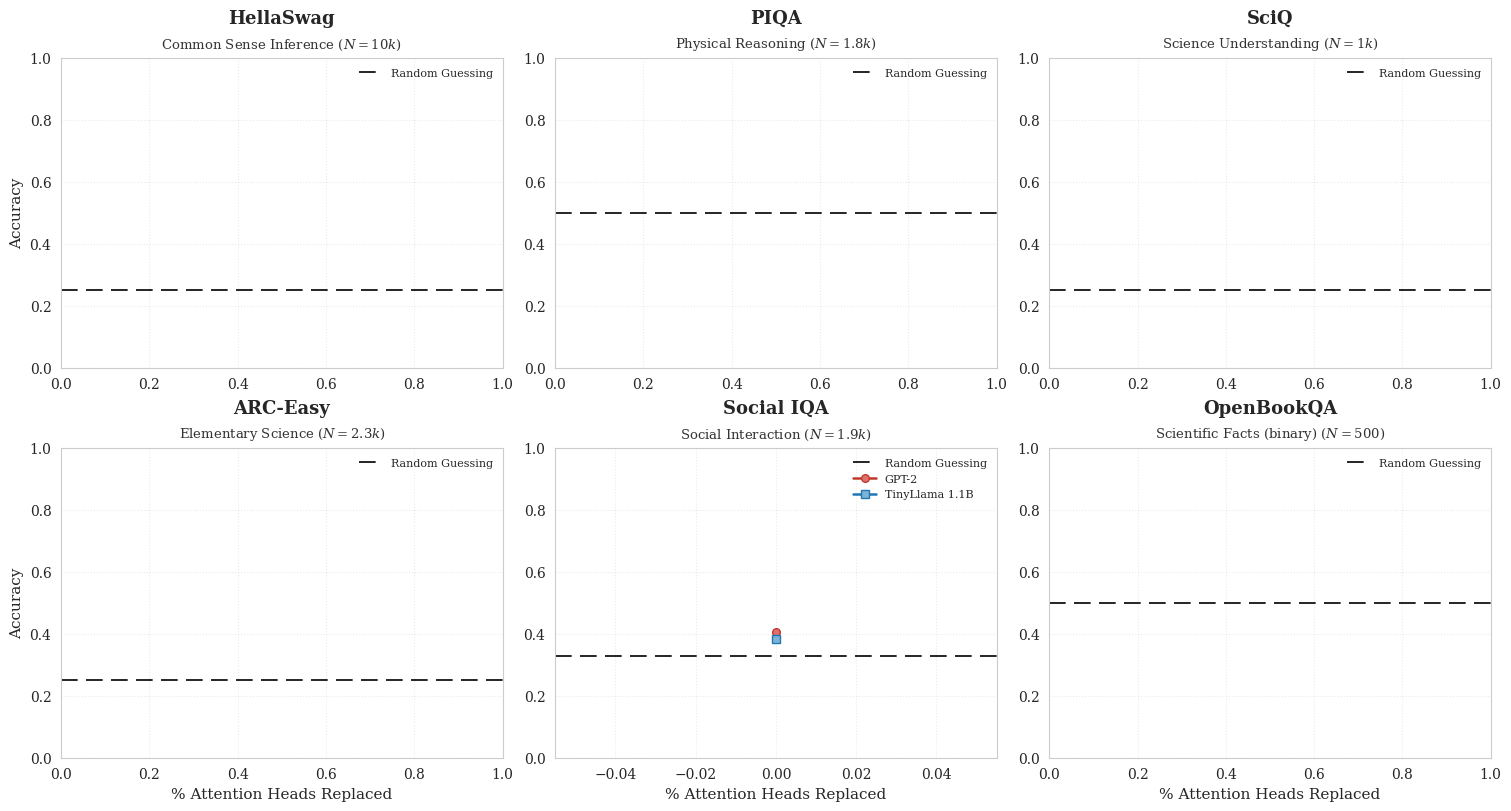


Plot saved to figure_4_4.pdf


In [ ]:
# ============================================================================
# FINAL CELL: Evaluate Models on 6 Benchmarks + Plot
# ============================================================================

import os
import json
import random
import torch
import torch.nn.functional as F
from transformers import (
    GPT2Tokenizer, GPT2LMHeadModel,
    AutoTokenizer, AutoModelForCausalLM
)
from datasets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Device Setup ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Configuration ──
N_SAMPLES = 200
REPLACEMENT_LEVELS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75, 1.00]
HEAD_COUNTS = {
    "gpt2":      144,   # 12 layers × 12 heads
    "tinyllama": 704,   # 22 layers × 32 heads
    "llama3b":   672,   # 28 layers × 24 heads
}
hardcoded_files = {
    "gpt2":      "results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv",
    "tinyllama": "results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv",
    "llama3b":   "results/replacement_run/llama3b_smart.csv",
}


# ── Model Loading ──


# ── Hook Builders ──

def build_replaced_model_gpt2(csv_file, replacement_pct):
    df = pd.read_csv(csv_file)
    target_heads = int(HEAD_COUNTS["gpt2"] * replacement_pct)
    print(f"Applying GPT-2 head replacement for {int(replacement_pct * 100)}% -> {target_heads} heads")

    if "k" not in df.columns:
        raise ValueError("Shuffle CSV is missing the 'k' column.")

    df["k"] = df["k"].astype(int)
    df = df.sort_values(by="k").head(target_heads).reset_index(drop=True)

    head_mapping = {}
    for _, row in df.iterrows():
        head_tuple = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[head_tuple] = row["program"]

    relevant_layers = set(layer for layer, _ in head_mapping.keys())
    model, tokenizer = load_model_and_tokenizer("gpt2")

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(
                                    hypo_tensor, modified_layer[:, :, head_idx, :]
                                )
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    hook_fn = make_smart_hook(head_mapping, all_programs)
    handles = []
    for l_idx in range(12):
        target = model.transformer.h[l_idx].attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            handles.append(target.register_forward_hook(hook_fn))

    return model, tokenizer, relevant_layers, handles, head_mapping


def build_replaced_model_tinyllama(csv_file, replacement_pct):
    df = pd.read_csv(csv_file)
    target_heads = int(HEAD_COUNTS["tinyllama"] * replacement_pct)
    print(f"Applying TinyLlama head replacement for {int(replacement_pct * 100)}% -> {target_heads} heads")

    if "k" not in df.columns:
        raise ValueError("Shuffle CSV is missing the 'k' column.")

    df["k"] = df["k"].astype(int)
    df = df.sort_values(by="k").head(target_heads).reset_index(drop=True)

    head_mapping = {}
    for _, row in df.iterrows():
        head_tuple = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[head_tuple] = row["program"]

    relevant_layers = set(layer for layer, _ in head_mapping.keys())
    model, tokenizer = load_model_and_tokenizer("tinyllama")

    NUM_HEADS   = 32
    NUM_LAYERS  = 22
    HIDDEN_SIZE = 2048
    HEAD_DIM    = HIDDEN_SIZE // NUM_HEADS

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(NUM_HEADS):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(
                                    hypo_tensor, modified_layer[:, :, head_idx, :]
                                )
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    hook_fn = make_smart_hook(head_mapping, all_programs)
    handles = []
    for l_idx in range(NUM_LAYERS):
        target = model.model.layers[l_idx].self_attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            handles.append(target.register_forward_hook(hook_fn))

    return model, tokenizer, relevant_layers, handles, head_mapping


def build_replaced_model_llama3b(csv_file, replacement_pct):
    NUM_HEADS   = 24
    NUM_LAYERS  = 28
    HIDDEN_SIZE = 3072
    HEAD_DIM    = HIDDEN_SIZE // NUM_HEADS

    df = pd.read_csv(csv_file)
    target_heads = int(HEAD_COUNTS["llama3b"] * replacement_pct)
    print(f"Applying Llama-3B head replacement for {int(replacement_pct * 100)}% -> {target_heads} heads")

    if "k" not in df.columns:
        raise ValueError("Shuffle CSV is missing the 'k' column.")

    df["k"] = df["k"].astype(int)
    df = df.sort_values(by="k").head(target_heads).reset_index(drop=True)

    head_mapping = {}
    for _, row in df.iterrows():
        head_tuple = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[head_tuple] = row["program"]

    relevant_layers = set(layer for layer, _ in head_mapping.keys())
    model, tokenizer = load_model_and_tokenizer("llama3b")

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(NUM_HEADS):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(
                                    hypo_tensor, modified_layer[:, :, head_idx, :]
                                )
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    hook_fn = make_smart_hook(head_mapping, all_programs)
    handles = []
    for l_idx in range(NUM_LAYERS):
        target = model.model.layers[l_idx].self_attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            handles.append(target.register_forward_hook(hook_fn))

    return model, tokenizer, relevant_layers, handles, head_mapping


def set_sentence(model, model_name, relevant_layers, sentence):
    if model_name == "gpt2":
        for l_idx in relevant_layers:
            model.transformer.h[l_idx].attn._current_sentence = sentence
    elif model_name in ("tinyllama", "llama3b"):
        for l_idx in relevant_layers:
            model.model.layers[l_idx].self_attn._current_sentence = sentence


# ── Scoring ──

def score_completion(model, tokenizer, model_name, context, completion, relevant_layers=None):
    if relevant_layers:
        set_sentence(model, model_name, relevant_layers, context + " " + completion)

    full_text = context + " " + completion
    enc     = tokenizer(full_text, return_tensors="pt").to(device)
    ctx_enc = tokenizer(context,   return_tensors="pt").to(device)
    ctx_len = ctx_enc["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model(**enc, labels=enc["input_ids"])
        logits  = outputs.logits

    log_probs = F.log_softmax(logits[0], dim=-1)
    input_ids = enc["input_ids"][0]
    scores = [log_probs[i - 1, input_ids[i]].item()
              for i in range(ctx_len, len(input_ids))]

    return np.mean(scores) if scores else -np.inf


# ── Benchmark Evaluation Functions ──

def evaluate_sciq(model, tokenizer, model_name, relevant_layers=None, n=200):
    dataset = load_dataset("sciq", split="validation")
    correct = 0
    for ex in dataset.select(range(min(n, len(dataset)))):
        choices = [ex["distractor1"], ex["distractor2"], ex["distractor3"], ex["correct_answer"]]
        scores  = [score_completion(model, tokenizer, model_name, ex["question"], c, relevant_layers)
                   for c in choices]
        if int(np.argmax(scores)) == 3:
            correct += 1
    return correct / min(n, len(dataset))


def evaluate_hellaswag(model, tokenizer, model_name, relevant_layers=None, n=200):
    dataset = load_dataset("Rowan/hellaswag", split="validation")
    correct = 0
    for ex in dataset.select(range(min(n, len(dataset)))):
        scores = [score_completion(model, tokenizer, model_name, ex["ctx"], e, relevant_layers)
                  for e in ex["endings"]]
        if int(np.argmax(scores)) == int(ex["label"]):
            correct += 1
    return correct / min(n, len(dataset))


def evaluate_piqa(model, tokenizer, model_name, relevant_layers=None, n=200):
    dataset = []
    with open("data/evaluations/piqa_val.jsonl", "r") as f:
        for line in f:
            dataset.append(json.loads(line))
            if len(dataset) >= n:
                break
    correct = 0
    for ex in dataset:
        choices = [ex["sol1"], ex["sol2"]]
        label   = int(ex["label"])
        scores  = [score_completion(model, tokenizer, model_name, ex["goal"], c, relevant_layers)
                   for c in choices]
        if int(np.argmax(scores)) == label:
            correct += 1
    return correct / len(dataset)


def evaluate_arc_easy(model, tokenizer, model_name, relevant_layers=None, n=200):
    dataset = load_dataset("allenai/ai2_arc", "ARC-Easy", split="validation")
    correct, count = 0, 0
    for ex in dataset.select(range(min(n, len(dataset)))):
        choice_texts  = ex["choices"]["text"]
        choice_labels = ex["choices"]["label"]
        answer_key    = ex["answerKey"]
        if answer_key not in choice_labels:
            continue
        label  = choice_labels.index(answer_key)
        scores = [score_completion(model, tokenizer, model_name, ex["question"], c, relevant_layers)
                  for c in choice_texts]
        if int(np.argmax(scores)) == label:
            correct += 1
        count += 1
    return correct / count if count > 0 else 0.0


def evaluate_social_iqa(model, tokenizer, model_name, relevant_layers=None, n=200):
    dataset = []
    local_path = "data/evaluations/socialIQa_v1.4/socialIQa_v1.4_dev.jsonl"
    try:
        with open(local_path, "r", encoding="utf-8") as f:
            for line in f:
                dataset.append(json.loads(line))
                if len(dataset) >= n:
                    break
    except FileNotFoundError:
        print(f"ERROR: Could not find {local_path}")
        return 0.0

    label_map = {"A": 0, "B": 1, "C": 2}
    n_correct, count = 0, 0
    for ex in dataset:
        label = label_map.get(ex["correct"])
        if label is None:
            continue
        prompt  = ex["context"].strip() + " " + ex["question"].strip()
        choices = [ex["answerA"], ex["answerB"], ex["answerC"]]
        scores  = [score_completion(model, tokenizer, model_name, prompt, c, relevant_layers)
                   for c in choices]
        if int(np.argmax(scores)) == label:
            n_correct += 1
        count += 1

    print(f"  [Social IQA] Evaluated {count} examples")
    return n_correct / count if count > 0 else 0.0


def evaluate_copa(model, tokenizer, model_name, relevant_layers=None, n=200):
    """
    2-way MC causal reasoning.
    Dataset : super_glue / copa (split: validation, 500 examples)
    Fields  : premise, question ("cause"/"effect"), choice1, choice2, label (0/1)
    Random baseline : 0.50
    """
    dataset = load_dataset("super_glue", "copa", split="validation")
    correct, count = 0, 0
    for ex in dataset.select(range(min(n, len(dataset)))):
        connective = "because" if ex["question"] == "cause" else "so"
        context    = ex["premise"].rstrip(".") + f" {connective}"
        choices    = [ex["choice1"], ex["choice2"]]
        scores     = [score_completion(model, tokenizer, model_name, context, c, relevant_layers)
                      for c in choices]
        if int(np.argmax(scores)) == ex["label"]:
            correct += 1
        count += 1
    return correct / count if count > 0 else 0.0


# ── Evaluation Suite ──

BENCHMARKS = [
    # ("HellaSwag",   evaluate_hellaswag),
    # ("PIQA",        evaluate_piqa),
    # ("SciQ",        evaluate_sciq),
    # ("ARC-Easy",    evaluate_arc_easy),
    # ("Social IQA",  evaluate_social_iqa),
    ("COPA",        evaluate_copa),
]

def run_evaluation_suite(model_name, csv_file=None, replacement_pct=None, n_samples=200):
    print(f"\n{'='*70}")
    print(f"Evaluating: {model_name.upper()}")
    if csv_file:
        print(f"Config: {os.path.basename(csv_file)} ({int(replacement_pct*100)}% replacement)")
    else:
        print("Config: BASELINE")
    print(f"{'='*70}")

    if csv_file is None:
        model, tokenizer = load_model_and_tokenizer(model_name)
        relevant_layers, handles = None, []
    else:
        if replacement_pct is None:
            raise ValueError("replacement_pct must be provided when csv_file is set")
        if model_name == "gpt2":
            model, tokenizer, relevant_layers, handles, head_mapping = \
                build_replaced_model_gpt2(csv_file, replacement_pct)
        elif model_name == "tinyllama":
            model, tokenizer, relevant_layers, handles, head_mapping = \
                build_replaced_model_tinyllama(csv_file, replacement_pct)
        elif model_name == "llama3b":
            model, tokenizer, relevant_layers, handles, head_mapping = \
                build_replaced_model_llama3b(csv_file, replacement_pct)
        print(f"Replaced {len(head_mapping)} heads across {len(relevant_layers)} layers")

    results = {}
    for name, fn in BENCHMARKS:
        print(f"\nRunning {name}...")
        results[name] = fn(model, tokenizer, model_name, relevant_layers, n_samples)
        print(f"  Accuracy: {results[name]:.4f}")

    print(f"\n{'='*70}")
    for name, val in results.items():
        print(f"  {name}: {val:.4f}")
    print(f"{'='*70}")

    for h in handles:
        h.remove()
    del model
    torch.cuda.empty_cache()
    return results


# ── Run All Evaluations ──

all_results = []

# "gpt2", "tinyllama",
for model_name in ["llama3b"]:
    print(f"\n{'#'*70}")
    print(f"# MODEL: {model_name.upper()}")
    print(f"{'#'*70}")

    baseline_results = run_evaluation_suite(model_name, csv_file=None, n_samples=N_SAMPLES)
    all_results.append({
        "model": model_name,
        "replacement_pct": 0,
        "csv_file": "baseline",
        "shuffle_idx": "baseline",
        **baseline_results
    })

    # Replacement levels (uncomment to run)
    best_file = hardcoded_files[model_name]
    for pct in REPLACEMENT_LEVELS:
        replaced_results = run_evaluation_suite(
            model_name, csv_file=best_file, replacement_pct=pct, n_samples=N_SAMPLES
        )
        all_results.append({
            "model": model_name,
            "replacement_pct": int(pct * 100),
            "csv_file": best_file,
            "shuffle_idx": "hardcoded",
            **replaced_results
        })

# ── Save Results ──

results_df = pd.DataFrame(all_results)
print("\n" + "="*70)
print("ALL RESULTS:")
print(results_df.to_string())

os.makedirs("results", exist_ok=True)
results_df.to_csv("results/downstream_task_results.csv", index=False)
print("\nResults saved to: results/downstream_task_results.csv")

# ── Build eval_results dict ──

RANDOM_BASELINES = {
    "HellaSwag":  0.25,
    "PIQA":       0.50,
    "SciQ":       0.25,
    "ARC-Easy":   0.25,
    "Social IQA": 0.33,
    "COPA":       0.50,
}

x_levels = sorted(results_df["replacement_pct"].unique().tolist())

eval_results = {}
for model_name in ["gpt2", "tinyllama", "llama3b"]:
    eval_results[model_name] = {}
    model_df = results_df[results_df["model"] == model_name].sort_values("replacement_pct")
    for benchmark, _ in BENCHMARKS:
        if benchmark not in model_df.columns:
            continue
        x_vals, y_vals = [], []
        for pct in x_levels:
            row = model_df[model_df["replacement_pct"] == pct]
            if not row.empty:
                x_vals.append(pct)
                y_vals.append(float(row[benchmark].values[0]))
        eval_results[model_name][benchmark] = {
            "baseline": RANDOM_BASELINES.get(benchmark, 0.25),
            "x": x_vals,
            "y": y_vals,
        }

# ── Plot ──

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

meta_info = {
    "HellaSwag":  {"desc": "Common Sense Inference",  "n": "10k"},
    "PIQA":       {"desc": "Physical Reasoning",       "n": "1.8k"},
    "SciQ":       {"desc": "Science Understanding",    "n": "1k"},
    "ARC-Easy":   {"desc": "Elementary Science",       "n": "2.3k"},
    "Social IQA": {"desc": "Social Interaction",       "n": "1.9k"},
    "COPA":       {"desc": "Causal Reasoning",         "n": "500"},
}

ROW_COLORS = {
    "gpt2":      {"box": "#e07070", "line": "#c0392b"},
    "tinyllama": {"box": "#7fb3d5", "line": "#1f77b4"},
    "llama3b":   {"box": "#a8d8a8", "line": "#2e7d32"},
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes_flat = axes.flatten()

for i, metric in enumerate(meta_info.keys()):
    ax = axes_flat[i]

    baseline_val = RANDOM_BASELINES.get(metric, 0.25)
    ax.axhline(y=baseline_val, color="black", linestyle="--",
               dashes=(10, 5), linewidth=1.2, label="Random Guessing")

    for model_name, marker, label in [
        ("gpt2",      "o", "GPT-2"),
        ("tinyllama", "s", "TinyLlama 1.1B"),
        ("llama3b",   "^", "Llama 3.2 3B"),
    ]:
        data = eval_results.get(model_name, {}).get(metric)
        if data is None:
            continue
        ax.plot(data["x"], data["y"],
                marker=marker, linestyle="-", linewidth=1.8, markersize=5.5,
                color=ROW_COLORS[model_name]["line"],
                markerfacecolor=ROW_COLORS[model_name]["box"],
                label=label)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

    ax.set_title(metric, fontweight="bold", fontsize=13, pad=25)
    subtitle = f"{meta_info[metric]['desc']} ($N={meta_info[metric]['n']}$)"
    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=9.5, color="#333333")

    ax.legend(fontsize=8, frameon=False, loc="upper right")
    if i >= 3:
        ax.set_xlabel("% Attention Heads Replaced", fontsize=11)
    if i % 3 == 0:
        ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle=":", alpha=0.4)

plt.savefig("figure_4_4.pdf", bbox_inches="tight")
plt.show()
print("\nPlot saved to figure_4_4.pdf")

In [ ]:
# Using device: cpu
# Loaded 144 program functions

# ######################################################################
# # MODEL: GPT2
# ######################################################################

# ======================================================================
# Evaluating: GPT2
# Config: gpt2_smart_shuffle_8.csv (5% replacement)
# ======================================================================
# Applying GPT-2 head replacement for 5% -> 7 heads
# Replaced 7 heads across 5 layers

# Running Social IQA...
# `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.4200

# ======================================================================
#   Social IQA: 0.4200
# ======================================================================

# ======================================================================
# Evaluating: GPT2
# Config: gpt2_smart_shuffle_8.csv (10% replacement)
# ======================================================================
# Applying GPT-2 head replacement for 10% -> 14 heads
# Replaced 14 heads across 8 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.4100

# ======================================================================
#   Social IQA: 0.4100
# ======================================================================

# ======================================================================
# Evaluating: GPT2
# Config: gpt2_smart_shuffle_8.csv (15% replacement)
# ======================================================================
# Applying GPT-2 head replacement for 15% -> 21 heads
# Replaced 21 heads across 10 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.4250

# ======================================================================
#   Social IQA: 0.4250
# ======================================================================

# ======================================================================
# Evaluating: GPT2
# Config: gpt2_smart_shuffle_8.csv (20% replacement)
# ======================================================================
# Applying GPT-2 head replacement for 20% -> 28 heads
# Replaced 28 heads across 10 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.4100

# ======================================================================
#   Social IQA: 0.4100
# ======================================================================

# ======================================================================
# Evaluating: GPT2
# Config: gpt2_smart_shuffle_8.csv (25% replacement)
# ======================================================================
# Applying GPT-2 head replacement for 25% -> 36 heads
# Replaced 36 heads across 10 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.4250

# ======================================================================
#   Social IQA: 0.4250
# ======================================================================

# ======================================================================
# Evaluating: GPT2
# Config: gpt2_smart_shuffle_8.csv (30% replacement)
# ======================================================================
# Applying GPT-2 head replacement for 30% -> 43 heads
# Replaced 43 heads across 10 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.4150

# ======================================================================
#   Social IQA: 0.4150
# ======================================================================

# ======================================================================
# Evaluating: GPT2
# Config: gpt2_smart_shuffle_8.csv (40% replacement)
# ======================================================================
# Applying GPT-2 head replacement for 40% -> 57 heads
# Replaced 57 heads across 10 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3950

# ======================================================================
#   Social IQA: 0.3950
# ======================================================================

# ======================================================================
# Evaluating: GPT2
# Config: gpt2_smart_shuffle_8.csv (50% replacement)
# ======================================================================
# Applying GPT-2 head replacement for 50% -> 72 heads
# Replaced 72 heads across 12 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.4100

# ======================================================================
#   Social IQA: 0.4100
# ======================================================================

# ======================================================================
# Evaluating: GPT2
# Config: gpt2_smart_shuffle_8.csv (75% replacement)
# ======================================================================
# Applying GPT-2 head replacement for 75% -> 108 heads
# Replaced 108 heads across 12 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.4100

# ======================================================================
#   Social IQA: 0.4100
# ======================================================================

# ======================================================================
# Evaluating: GPT2
# Config: gpt2_smart_shuffle_8.csv (100% replacement)
# ======================================================================
# Applying GPT-2 head replacement for 100% -> 144 heads
# Replaced 144 heads across 12 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.4100

# ======================================================================
#   Social IQA: 0.4100
# ======================================================================

# ######################################################################
# # MODEL: TINYLLAMA
# ######################################################################

# ======================================================================
# Evaluating: TINYLLAMA
# Config: tinyllama_smart_shuffle_2.csv (5% replacement)
# ======================================================================
# Applying TinyLlama head replacement for 5% -> 35 heads
# Replaced 35 heads across 13 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3800

# ======================================================================
#   Social IQA: 0.3800
# ======================================================================

# ======================================================================
# Evaluating: TINYLLAMA
# Config: tinyllama_smart_shuffle_2.csv (10% replacement)
# ======================================================================
# Applying TinyLlama head replacement for 10% -> 70 heads
# Replaced 70 heads across 16 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3900

# ======================================================================
#   Social IQA: 0.3900
# ======================================================================

# ======================================================================
# Evaluating: TINYLLAMA
# Config: tinyllama_smart_shuffle_2.csv (15% replacement)
# ======================================================================
# Applying TinyLlama head replacement for 15% -> 105 heads
# Replaced 105 heads across 18 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3900

# ======================================================================
#   Social IQA: 0.3900
# ======================================================================

# ======================================================================
# Evaluating: TINYLLAMA
# Config: tinyllama_smart_shuffle_2.csv (20% replacement)
# ======================================================================
# Applying TinyLlama head replacement for 20% -> 140 heads
# Replaced 140 heads across 19 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3700

# ======================================================================
#   Social IQA: 0.3700
# ======================================================================

# ======================================================================
# Evaluating: TINYLLAMA
# Config: tinyllama_smart_shuffle_2.csv (25% replacement)
# ======================================================================
# Applying TinyLlama head replacement for 25% -> 176 heads
# Replaced 176 heads across 19 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3900

# ======================================================================
#   Social IQA: 0.3900
# ======================================================================

# ======================================================================
# Evaluating: TINYLLAMA
# Config: tinyllama_smart_shuffle_2.csv (30% replacement)
# ======================================================================
# Applying TinyLlama head replacement for 30% -> 211 heads
# Replaced 211 heads across 20 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3850

# ======================================================================
#   Social IQA: 0.3850
# ======================================================================

# ======================================================================
# Evaluating: TINYLLAMA
# Config: tinyllama_smart_shuffle_2.csv (40% replacement)
# ======================================================================
# Applying TinyLlama head replacement for 40% -> 281 heads
# Replaced 281 heads across 20 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3900

# ======================================================================
#   Social IQA: 0.3900
# ======================================================================

# ======================================================================
# Evaluating: TINYLLAMA
# Config: tinyllama_smart_shuffle_2.csv (50% replacement)
# ======================================================================
# Applying TinyLlama head replacement for 50% -> 352 heads
# Replaced 352 heads across 20 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3550

# ======================================================================
#   Social IQA: 0.3550
# ======================================================================

# ======================================================================
# Evaluating: TINYLLAMA
# Config: tinyllama_smart_shuffle_2.csv (75% replacement)
# ======================================================================
# Applying TinyLlama head replacement for 75% -> 528 heads
# Replaced 528 heads across 21 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3800

# ======================================================================
#   Social IQA: 0.3800
# ======================================================================

# ======================================================================
# Evaluating: TINYLLAMA
# Config: tinyllama_smart_shuffle_2.csv (100% replacement)
# ======================================================================
# Applying TinyLlama head replacement for 100% -> 704 heads
# Replaced 704 heads across 22 layers

# Running Social IQA...
#   [Social IQA] Evaluated 200 examples
#   Accuracy: 0.3500

# ======================================================================
#   Social IQA: 0.3500
# ======================================================================

# ======================================================================
# ALL RESULTS:
#         model  replacement_pct                                                           csv_file shuffle_idx  Social IQA
# 0        gpt2                5       ../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv   hardcoded       0.420
# 1        gpt2               10       ../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv   hardcoded       0.410
# 2        gpt2               15       ../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv   hardcoded       0.425
# 3        gpt2               20       ../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv   hardcoded       0.410
# 4        gpt2               25       ../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv   hardcoded       0.425
# 5        gpt2               30       ../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv   hardcoded       0.415
# 6        gpt2               40       ../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv   hardcoded       0.395
# 7        gpt2               50       ../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv   hardcoded       0.410
# 8        gpt2               75       ../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv   hardcoded       0.410
# 9        gpt2              100       ../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv   hardcoded       0.410
# 10  tinyllama                5  ../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv   hardcoded       0.380
# 11  tinyllama               10  ../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv   hardcoded       0.390
# 12  tinyllama               15  ../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv   hardcoded       0.390
# 13  tinyllama               20  ../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv   hardcoded       0.370
# 14  tinyllama               25  ../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv   hardcoded       0.390
# 15  tinyllama               30  ../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv   hardcoded       0.385
# 16  tinyllama               40  ../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv   hardcoded       0.390
# 17  tinyllama               50  ../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv   hardcoded       0.355
# 18  tinyllama               75  ../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv   hardcoded       0.380
# 19  tinyllama              100  ../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv   hardcoded       0.350

# Results saved to: ../results/downstream_task_results.csv

In [21]:
# Try this if the above fails
dataset = load_dataset("json", data_files="https://huggingface.co/datasets/allenai/social_i_qa/resolve/main/data/validation-00000-of-00001.parquet", split="train")

FileNotFoundError: Unable to find 'hf://datasets/allenai/social_i_qa@main/data/validation-00000-of-00001.parquet'

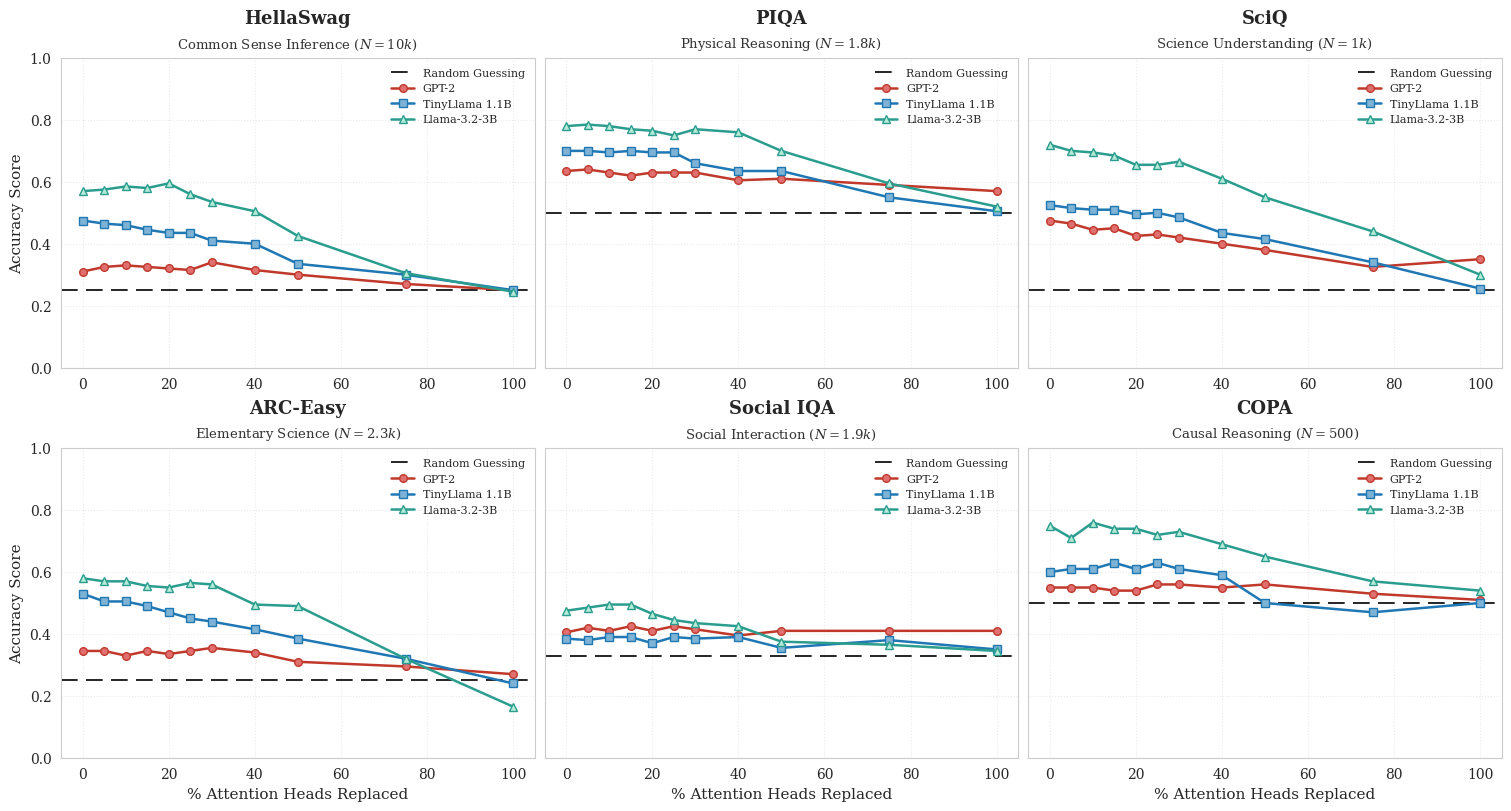

In [48]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

# 1. DATA DICTIONARY
eval_results = {
    "gpt2": {
        "HellaSwag": {
            "baseline": 0.25,
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100],
            "y": [0.310, 0.325, 0.330, 0.325, 0.320, 0.315, 0.340, 0.315, 0.300, 0.270, 0.250]
        },
        "PIQA": {
            "baseline": 0.50, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100],
            "y": [0.635, 0.640, 0.630, 0.620, 0.630, 0.630, 0.630, 0.605, 0.610, 0.590, 0.570]
        },
        "SciQ": {
            "baseline": 0.25,
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100],
            "y": [0.475, 0.465, 0.445, 0.450, 0.425, 0.430, 0.420, 0.400, 0.380, 0.325, 0.350]
        },
        "ARC-Easy": {
            "baseline": 0.25, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.345, 0.345, 0.330, 0.345, 0.335, 0.345, 0.355, 0.340, 0.310, 0.295, 0.270]
        },
        "Social IQA": {
            "baseline": 0.33, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.405, 0.420, 0.410, 0.425, 0.410, 0.425, 0.415, 0.395, 0.410, 0.410, 0.410]
        },
        "COPA": {
            "baseline": 0.50, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.55, 0.55, 0.55, 0.54, 0.54, 0.56, 0.56, 0.55, 0.56, 0.53, 0.51]
        }
    },
    "tinyllama": {
        "HellaSwag": {
            "baseline": 0.25,
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100],
            "y": [0.475, 0.465, 0.460, 0.445, 0.435, 0.435, 0.410, 0.400, 0.335, 0.300, 0.250]
        },
        "PIQA": {
            "baseline": 0.25,
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100],
            "y": [0.700, 0.700, 0.695, 0.700, 0.695, 0.695, 0.660, 0.635, 0.635, 0.550, 0.505]
        },
        "SciQ": {
            "baseline": 0.25,
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100],
            "y": [0.525, 0.515, 0.510, 0.510, 0.495, 0.500, 0.485, 0.435, 0.415, 0.340, 0.255]
        },
        "ARC-Easy": {
            "baseline": 0.25, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.530, 0.505, 0.505, 0.490, 0.470, 0.450, 0.440, 0.415, 0.385, 0.320, 0.240]
        },
        "Social IQA": {
            "baseline": 0.33, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.385, 0.380, 0.390, 0.390, 0.370, 0.390, 0.385, 0.390, 0.355, 0.380, 0.350]
        },
        "COPA": {
            "baseline": 0.50, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.60, 0.61, 0.61, 0.63, 0.61, 0.63, 0.61, 0.59, 0.50, 0.47, 0.50]
        }
    },
    "llama3b": {
        "HellaSwag": {
            "baseline": 0.25, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.570, 0.575, 0.585, 0.580, 0.595, 0.560, 0.535, 0.505, 0.425, 0.305, 0.245]
        },
        "PIQA": {
            "baseline": 0.50, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.780, 0.785, 0.780, 0.770, 0.765, 0.750, 0.770, 0.760, 0.700, 0.595, 0.520]
        },
        "SciQ": {
            "baseline": 0.25, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.720, 0.700, 0.695, 0.685, 0.655, 0.655, 0.665, 0.610, 0.550, 0.440, 0.300]
        },
        "ARC-Easy": {
            "baseline": 0.25, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.580, 0.570, 0.570, 0.555, 0.550, 0.565, 0.560, 0.495, 0.490, 0.320, 0.165]
        },
        "Social IQA": {
            "baseline": 0.33, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.475, 0.485, 0.495, 0.495, 0.465, 0.445, 0.435, 0.425, 0.375, 0.365, 0.345]
        },
        "COPA": {
            "baseline": 0.50, 
            "x": [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100], 
            "y": [0.75, 0.71, 0.76, 0.74, 0.74, 0.72, 0.73, 0.69, 0.65, 0.57, 0.54]
        }
    }
}

# Metadata for labels
meta_info = {
    "HellaSwag":  {"desc": "Common Sense Inference",  "n": "10k"},
    "PIQA":       {"desc": "Physical Reasoning",       "n": "1.8k"},
    "SciQ":       {"desc": "Science Understanding",    "n": "1k"},
    "ARC-Easy":   {"desc": "Elementary Science",       "n": "2.3k"},
    "Social IQA": {"desc": "Social Interaction",       "n": "1.9k"},
    "COPA":       {"desc": "Causal Reasoning",         "n": "500"},
}

ROW_COLORS = {
    "gpt2":      {"box": "#e07070", "line": "#c0392b"},
    "tinyllama": {"box": "#7fb3d5", "line": "#1f77b4"},
    "llama3b":   {"box": "#b5ead7", "line": "#2a9d8f"},
}

# 2. PLOTTING LOGIC
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True, constrained_layout=True)
axes_flat = axes.flatten()

for i, metric in enumerate(meta_info.keys()):
    ax = axes_flat[i]
    
    # Plot random baseline first
    baseline_val = eval_results["gpt2"][metric]["baseline"]
    ax.axhline(y=baseline_val, color='black', linestyle='--', 
               dashes=(10, 5), linewidth=1.2, label="Random Guessing")
    
    for model_name in ["gpt2", "tinyllama", "llama3b"]:
        data = eval_results[model_name][metric]
        marker = "o" if model_name == "gpt2" else ("s" if model_name == "tinyllama" else "^")
        label  = "GPT-2" if model_name == "gpt2" else ("TinyLlama 1.1B" if model_name == "tinyllama" else "Llama-3.2-3B")
        
        ax.plot(data["x"], data["y"], marker=marker, linestyle='-', linewidth=1.8, 
                markersize=5.5, color=ROW_COLORS[model_name]["line"], 
                markerfacecolor=ROW_COLORS[model_name]["box"], label=label)
    
    # Subtitle and Title formatting
    ax.set_title(metric, fontweight='bold', fontsize=13, pad=25)
    subtitle_text = f"{meta_info[metric]['desc']} ($N={meta_info[metric]['n']}$)"
    ax.text(0.5, 1.02, subtitle_text, transform=ax.transAxes, ha='center', 
            va='bottom', fontsize=9.5, fontweight='normal', color='#333333')
    
    # Legend per plot
    ax.legend(fontsize=8, frameon=False, loc='upper right')
    
    # Axis formatting
    if i >= 3: ax.set_xlabel("% Attention Heads Replaced", fontsize=11)
    if i % 3 == 0: ax.set_ylabel("Accuracy Score", fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.savefig("figure_4_4.pdf")
plt.show()

In [14]:
import pandas as pd

# Pull the validation split from the processed parquet mirror
# This version definitely has labels
df = pd.read_parquet("hf://datasets/ybisk/piqa@refs/convert/parquet/plain_text/validation/0000.parquet")

# Save it to your local repo
df.to_json("../data/evaluations/piqa_val.jsonl", orient="records", lines=True)
print("Saved 1,838 labeled examples to data/evaluations/piqa_val.jsonl")

Saved 1,838 labeled examples to data/evaluations/piqa_val.jsonl


In [36]:
all_results = [
    # GPT-2
    {'model': 'gpt2', 'replacement_pct':   0, 'HellaSwag': 0.310, 'PIQA': 0.635, 'SciQ': 0.475, 'ARC-Easy': 0.345, 'Social IQA': 0.405, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct':   5, 'HellaSwag': 0.320, 'PIQA': 0.630, 'SciQ': 0.480, 'ARC-Easy': 0.360, 'Social IQA': 0.410, 'COPA': 0.54},
    {'model': 'gpt2', 'replacement_pct':  10, 'HellaSwag': 0.325, 'PIQA': 0.615, 'SciQ': 0.455, 'ARC-Easy': 0.350, 'Social IQA': 0.415, 'COPA': 0.54},
    {'model': 'gpt2', 'replacement_pct':  15, 'HellaSwag': 0.340, 'PIQA': 0.620, 'SciQ': 0.450, 'ARC-Easy': 0.345, 'Social IQA': 0.405, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct':  20, 'HellaSwag': 0.340, 'PIQA': 0.630, 'SciQ': 0.450, 'ARC-Easy': 0.340, 'Social IQA': 0.405, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct':  25, 'HellaSwag': 0.330, 'PIQA': 0.635, 'SciQ': 0.435, 'ARC-Easy': 0.360, 'Social IQA': 0.420, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct':  30, 'HellaSwag': 0.315, 'PIQA': 0.610, 'SciQ': 0.430, 'ARC-Easy': 0.350, 'Social IQA': 0.400, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct':  40, 'HellaSwag': 0.300, 'PIQA': 0.605, 'SciQ': 0.395, 'ARC-Easy': 0.320, 'Social IQA': 0.380, 'COPA': 0.56},
    {'model': 'gpt2', 'replacement_pct':  50, 'HellaSwag': 0.305, 'PIQA': 0.615, 'SciQ': 0.385, 'ARC-Easy': 0.330, 'Social IQA': 0.380, 'COPA': 0.56},
    {'model': 'gpt2', 'replacement_pct':  75, 'HellaSwag': 0.275, 'PIQA': 0.585, 'SciQ': 0.340, 'ARC-Easy': 0.290, 'Social IQA': 0.385, 'COPA': 0.54},
    {'model': 'gpt2', 'replacement_pct': 100, 'HellaSwag': 0.255, 'PIQA': 0.525, 'SciQ': 0.315, 'ARC-Easy': 0.280, 'Social IQA': 0.375, 'COPA': 0.50},

    # Llama-3B
    {'model': 'llama3b', 'replacement_pct': 0, 'HellaSwag': 0.570, 'PIQA': 0.780, 'SciQ': 0.720, 'ARC-Easy': 0.580, 'Social IQA': 0.475, 'COPA': 0.750},
    {'model': 'llama3b', 'replacement_pct':  5, 'HellaSwag': 0.575, 'PIQA': 0.785, 'SciQ': 0.705, 'ARC-Easy': 0.590, 'Social IQA': 0.480, 'COPA': 0.730},
    {'model': 'llama3b', 'replacement_pct': 10, 'HellaSwag': 0.590, 'PIQA': 0.785, 'SciQ': 0.690, 'ARC-Easy': 0.575, 'Social IQA': 0.480, 'COPA': 0.740},
    {'model': 'llama3b', 'replacement_pct': 15, 'HellaSwag': 0.585, 'PIQA': 0.775, 'SciQ': 0.690, 'ARC-Easy': 0.570, 'Social IQA': 0.480, 'COPA': 0.720},
    {'model': 'llama3b', 'replacement_pct': 20, 'HellaSwag': 0.585, 'PIQA': 0.750, 'SciQ': 0.665, 'ARC-Easy': 0.560, 'Social IQA': 0.465, 'COPA': 0.740},
    {'model': 'llama3b', 'replacement_pct': 25, 'HellaSwag': 0.555, 'PIQA': 0.755, 'SciQ': 0.655, 'ARC-Easy': 0.570, 'Social IQA': 0.450, 'COPA': 0.730},
    {'model': 'llama3b', 'replacement_pct': 30, 'HellaSwag': 0.535, 'PIQA': 0.760, 'SciQ': 0.650, 'ARC-Easy': 0.570, 'Social IQA': 0.435, 'COPA': 0.720},
    {'model': 'llama3b', 'replacement_pct': 40, 'HellaSwag': 0.500, 'PIQA': 0.750, 'SciQ': 0.645, 'ARC-Easy': 0.550, 'Social IQA': 0.450, 'COPA': 0.700},

    # TinyLlama
    {'model': 'tinyllama', 'replacement_pct':  5, 'HellaSwag': 0.470, 'PIQA': 0.710, 'SciQ': 0.515, 'ARC-Easy': 0.510, 'Social IQA': 0.400, 'COPA': 0.630},
    {'model': 'tinyllama', 'replacement_pct': 10, 'HellaSwag': 0.465, 'PIQA': 0.690, 'SciQ': 0.510, 'ARC-Easy': 0.505, 'Social IQA': 0.400, 'COPA': 0.630},
    {'model': 'tinyllama', 'replacement_pct': 0, 'HellaSwag': 0.475, 'PIQA': 0.700, 'SciQ': 0.525, 'ARC-Easy': 0.530, 'Social IQA': 0.385, 'COPA': 0.600},
]

results_df = pd.DataFrame(all_results)

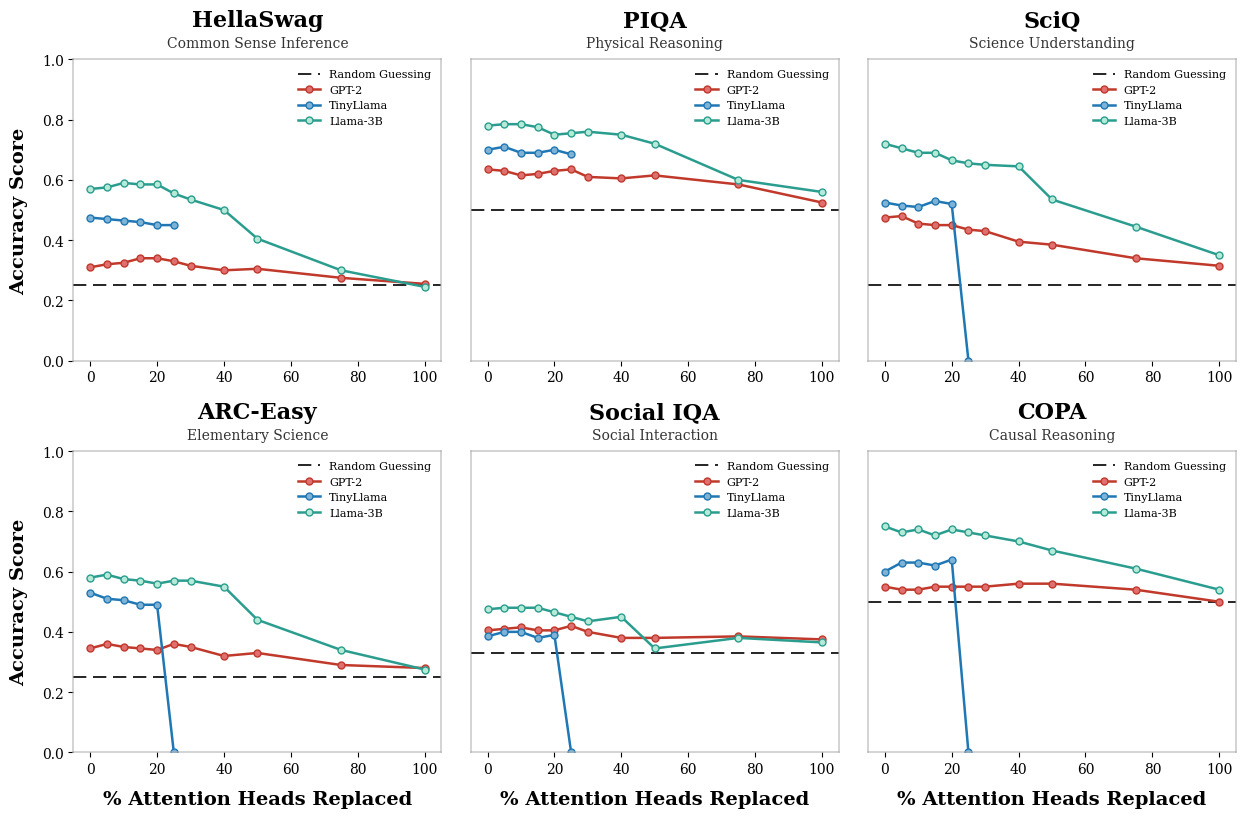

[DONE] Figure 7 saved.


In [ ]:
# ── 22. Figure 7 — Downstream task accuracy vs heads replaced ────────────────

all_results = [
    # GPT-2
    {'model': 'gpt2', 'replacement_pct':   0, 'HellaSwag': 0.310, 'PIQA': 0.635, 'SciQ': 0.475, 'ARC-Easy': 0.345, 'Social IQA': 0.405, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct':   5, 'HellaSwag': 0.320, 'PIQA': 0.630, 'SciQ': 0.480, 'ARC-Easy': 0.360, 'Social IQA': 0.410, 'COPA': 0.54},
    {'model': 'gpt2', 'replacement_pct':  10, 'HellaSwag': 0.325, 'PIQA': 0.615, 'SciQ': 0.455, 'ARC-Easy': 0.350, 'Social IQA': 0.415, 'COPA': 0.54},
    {'model': 'gpt2', 'replacement_pct':  15, 'HellaSwag': 0.340, 'PIQA': 0.620, 'SciQ': 0.450, 'ARC-Easy': 0.345, 'Social IQA': 0.405, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct':  20, 'HellaSwag': 0.340, 'PIQA': 0.630, 'SciQ': 0.450, 'ARC-Easy': 0.340, 'Social IQA': 0.405, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct':  25, 'HellaSwag': 0.330, 'PIQA': 0.635, 'SciQ': 0.435, 'ARC-Easy': 0.360, 'Social IQA': 0.420, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct':  30, 'HellaSwag': 0.315, 'PIQA': 0.610, 'SciQ': 0.430, 'ARC-Easy': 0.350, 'Social IQA': 0.400, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct':  40, 'HellaSwag': 0.300, 'PIQA': 0.605, 'SciQ': 0.395, 'ARC-Easy': 0.320, 'Social IQA': 0.380, 'COPA': 0.56},
    {'model': 'gpt2', 'replacement_pct':  50, 'HellaSwag': 0.305, 'PIQA': 0.615, 'SciQ': 0.385, 'ARC-Easy': 0.330, 'Social IQA': 0.380, 'COPA': 0.56},
    {'model': 'gpt2', 'replacement_pct':  75, 'HellaSwag': 0.275, 'PIQA': 0.585, 'SciQ': 0.340, 'ARC-Easy': 0.290, 'Social IQA': 0.385, 'COPA': 0.54},
    {'model': 'gpt2', 'replacement_pct': 100, 'HellaSwag': 0.255, 'PIQA': 0.525, 'SciQ': 0.315, 'ARC-Easy': 0.280, 'Social IQA': 0.375, 'COPA': 0.50},

    # Llama-3B
    {'model': 'llama3b', 'replacement_pct': 0, 'HellaSwag': 0.570, 'PIQA': 0.780, 'SciQ': 0.720, 'ARC-Easy': 0.580, 'Social IQA': 0.475, 'COPA': 0.750},
    {'model': 'llama3b', 'replacement_pct':  5, 'HellaSwag': 0.575, 'PIQA': 0.785, 'SciQ': 0.705, 'ARC-Easy': 0.590, 'Social IQA': 0.480, 'COPA': 0.730},
    {'model': 'llama3b', 'replacement_pct': 10, 'HellaSwag': 0.590, 'PIQA': 0.785, 'SciQ': 0.690, 'ARC-Easy': 0.575, 'Social IQA': 0.480, 'COPA': 0.740},
    {'model': 'llama3b', 'replacement_pct': 15, 'HellaSwag': 0.585, 'PIQA': 0.775, 'SciQ': 0.690, 'ARC-Easy': 0.570, 'Social IQA': 0.480, 'COPA': 0.720},
    {'model': 'llama3b', 'replacement_pct': 20, 'HellaSwag': 0.585, 'PIQA': 0.750, 'SciQ': 0.665, 'ARC-Easy': 0.560, 'Social IQA': 0.465, 'COPA': 0.740},
    {'model': 'llama3b', 'replacement_pct': 25, 'HellaSwag': 0.555, 'PIQA': 0.755, 'SciQ': 0.655, 'ARC-Easy': 0.570, 'Social IQA': 0.450, 'COPA': 0.730},
    {'model': 'llama3b', 'replacement_pct': 30, 'HellaSwag': 0.535, 'PIQA': 0.760, 'SciQ': 0.650, 'ARC-Easy': 0.570, 'Social IQA': 0.435, 'COPA': 0.720},
    {'model': 'llama3b', 'replacement_pct': 40, 'HellaSwag': 0.500, 'PIQA': 0.750, 'SciQ': 0.645, 'ARC-Easy': 0.550, 'Social IQA': 0.450, 'COPA': 0.700},
    {'model': 'llama3b', 'replacement_pct': 50, 'HellaSwag': 0.405, 'PIQA': 0.720, 'SciQ': 0.535, 'ARC-Easy': 0.440, 'Social IQA': 0.345, 'COPA': 0.670},
    {'model': 'llama3b', 'replacement_pct': 75, 'HellaSwag': 0.300, 'PIQA': 0.600, 'SciQ': 0.445, 'ARC-Easy': 0.340, 'Social IQA': 0.380, 'COPA': 0.610},
    {'model': 'llama3b', 'replacement_pct': 100, 'HellaSwag': 0.245, 'PIQA': 0.560, 'SciQ': 0.350, 'ARC-Easy': 0.275, 'Social IQA': 0.365, 'COPA': 0.540},

    # TinyLlama
    {'model': 'tinyllama', 'replacement_pct': 0, 'HellaSwag': 0.475, 'PIQA': 0.700, 'SciQ': 0.525, 'ARC-Easy': 0.530, 'Social IQA': 0.385, 'COPA': 0.600},
    {'model': 'tinyllama', 'replacement_pct':  5, 'HellaSwag': 0.470, 'PIQA': 0.710, 'SciQ': 0.515, 'ARC-Easy': 0.510, 'Social IQA': 0.400, 'COPA': 0.630},
    {'model': 'tinyllama', 'replacement_pct': 10, 'HellaSwag': 0.465, 'PIQA': 0.690, 'SciQ': 0.510, 'ARC-Easy': 0.505, 'Social IQA': 0.400, 'COPA': 0.630},
    {'model': 'tinyllama', 'replacement_pct': 15, 'HellaSwag': 0.460, 'PIQA': 0.690, 'SciQ': 0.530, 'ARC-Easy': 0.490, 'Social IQA': 0.380, 'COPA': 0.620},
    {'model': 'tinyllama', 'replacement_pct': 20, 'HellaSwag': 0.450, 'PIQA': 0.700, 'SciQ': 0.520, 'ARC-Easy': 0.490, 'Social IQA': 0.390, 'COPA': 0.640},
    {'model': 'tinyllama', 'replacement_pct': 25, 'HellaSwag': 0.450, 'PIQA': 0.685, 'SciQ': 0, 'ARC-Easy': 0, 'Social IQA': 0, 'COPA': 0},
]

results_df = pd.DataFrame(all_results)
import matplotlib.pyplot as plt
REPLACEMENT_LEVELS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75, 1.00]
plt.rcParams["font.family"] = "serif"

META = {
    "HellaSwag":  {"desc": "Common Sense Inference",  "n": "10k"},
    "PIQA":       {"desc": "Physical Reasoning",       "n": "1.8k"},
    "SciQ":       {"desc": "Science Understanding",    "n": "1k"},
    "ARC-Easy":   {"desc": "Elementary Science",       "n": "2.3k"},
    "Social IQA": {"desc": "Social Interaction",       "n": "1.9k"},
    "COPA":       {"desc": "Causal Reasoning",         "n": "500"},
}

ROW_COLORS = {
    "gpt2":      {"box": "#e07070", "line": "#c0392b"},
    "tinyllama": {"box": "#7fb3d5", "line": "#1f77b4"},
    "llama3b":   {"box": "#b5ead7", "line": "#2a9d8f"},
}

MODEL_LABELS = {
    "gpt2": "GPT-2",
    "tinyllama": "TinyLlama",
    "llama3b": "Llama-3B",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.subplots_adjust(hspace=0.3, wspace=0.08)

RANDOM_BASELINES = {
    "HellaSwag":  0.25, "PIQA": 0.50, "SciQ": 0.25,
    "ARC-Easy":   0.25, "Social IQA": 0.33, "COPA": 0.50,
}

for i, (ax, (metric, meta)) in enumerate(zip(axes.flatten(), META.items())):
    row, col = divmod(i, 3)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("#aaaaaa")
        spine.set_linewidth(1.2)
        spine.set_alpha(0.6)

    baseline = RANDOM_BASELINES[metric]
    ax.axhline(baseline, color="black", linestyle="--", dashes=(8, 4),
               linewidth=1.2, label="Random Guessing")

    if metric in results_df.columns:
        for model, colors in ROW_COLORS.items():
            sub = results_df[results_df["model"] == model].sort_values("replacement_pct")
            if sub.empty:
                continue
            ax.plot(sub["replacement_pct"], sub[metric],
                    marker="o", linewidth=1.8, markersize=5,
                    color=colors["line"],
                    markerfacecolor=colors["box"],
                    label=MODEL_LABELS[model])

    ax.set_title(metric, fontweight="bold", fontsize=16, pad=24)
    ax.text(0.5, 1.03, f'{meta["desc"]}', #($N={meta["n"]}$)
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=10, color="#333333")
    ax.set_ylim(0, 1.0)
    ax.set_xlim(-5, 105)
    ax.set_xticks(range(0, 101, 20))
    ax.legend(fontsize=8, frameon=False)

    if row == 1:
        ax.set_xlabel("% Attention Heads Replaced", fontsize=14, fontweight="bold", labelpad=10)
    else:
        ax.set_xlabel("")

    if col == 0:
        ax.set_ylabel("Accuracy Score", fontsize=14, fontweight="bold", labelpad=10)
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", left=False, labelleft=False)

# plt.suptitle("Effect of Replacing Attention Heads on Downstream Model Evaluations",
            #  fontsize=18, fontweight="bold")
plt.savefig(f'../results/plots/figure_7_downstream.pdf', bbox_inches="tight", dpi=150)
# plt.savefig(f'{RESULTS_DIR}/plots/figure_7_downstream.png', bbox_inches="tight", dpi=150)
plt.show()
print("[DONE] Figure 7 saved.")

In [134]:
# ── Find high-IoU programs for algorithm showcase ─────────────────────────────
# Looks across all best_fits CSVs for programs with IoU >= 0.90,
# prints source code of top candidates so you can pick 3 for the appendix.

import inspect

THRESHOLD = 0.9

candidates = []
for mk in ['bert', 'gpt2', 'tinyllama', 'llama3b']:
    bf_path = f'../results/best_fits_{mk}_new.csv'
    if not os.path.exists(bf_path):
        print(f'[SKIP] {mk}: no best_fits csv')
        continue
    bf = pd.read_csv(bf_path)
    high = bf[bf['best_iou'] >= THRESHOLD].copy()
    high['model'] = mk
    candidates.append(high)
    print(f'{mk}: {len(high)} heads with IoU >= {THRESHOLD}')

if not candidates:
    print('No candidates — try lowering THRESHOLD to 0.85')
else:
    all_high = (pd.concat(candidates)
                .sort_values('best_iou', ascending=False)
                .drop_duplicates('best_program'))  # one entry per unique program
    print(f'\nTotal unique programs at >= {THRESHOLD}: {len(all_high)}')
    print(all_high[['model','layer','head','best_iou','best_program']].head(20).to_string())

    # Print source for top 10 unique programs
    print('\n' + '='*70)
    print('PROGRAM SOURCE CODE')
    print('='*70)
    shown = 0
    for _, row in all_high.iterrows():
        if shown >= 15: break
        prog = next((p for p in MODEL_PROGRAMS.get(row['model'], [])
                     if p.__name__ == row['best_program']), None)
        if prog is None: continue
        src = inspect.getsource(prog)
        # Skip very long programs (> 40 lines) — prefer concise ones for paper
        if src.count('\n') > 25:
            continue
        print(f'\n--- {row["best_program"]}')
        print(f'    model={row["model"]}  L{int(row["layer"])}H{int(row["head"])}  IoU={row["best_iou"]:.3f}')
        print(src)
        shown += 1

bert: 0 heads with IoU >= 0.9
gpt2: 14 heads with IoU >= 0.9
tinyllama: 64 heads with IoU >= 0.9
llama3b: 147 heads with IoU >= 0.9

Total unique programs at >= 0.9: 20
         model  layer  head  best_iou                         best_program
22     llama3b      0    22  0.999345                            prog_L7H4
64     llama3b      2    16  0.993015                          prog_L16H14
538    llama3b     22    10  0.984901                          prog_L19H18
61        gpt2      5     1  0.977850                first_token_bias_L6H9
59     llama3b      2    11  0.949795                           prog_L3H13
94        gpt2      7    10  0.946805                first_token_bias_L7H2
496  tinyllama     15    16  0.943953                          prog_L14H29
128       gpt2     10     8  0.939998                first_token_bias_L9H6
409    llama3b     17     1  0.939458                          prog_L19H16
612    llama3b     25    12  0.933798                          prog_L19H14
203  t

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.colorbar as mcolorbar
import seaborn as sns
import importlib
import inspect
import re
import json
import os

CATEGORY_COLORS = {
    'initiation_and_anchoring':      '#4285F4',
    'relational_and_semantic':       '#EA4335',
    'special_tokens_and_boundaries': '#FBBC05',
    'linguistic_and_syntactic':      '#FF6D00',
    'sequential_and_induction':      '#34A853',
    'uniformity_and_global':         '#A142F4',
}

CATEGORIES = [
    'initiation_and_anchoring',       # first token, sentence start, CLS emphasis
    'relational_and_semantic',         # coreference, semantic similarity, entity tracking
    'special_tokens_and_boundaries',   # punctuation, clause boundaries, separators
    'linguistic_and_syntactic',        # POS, dependency, syntactic structure
    'sequential_and_induction',        # previous token, next token, induction, copying
    'uniformity_and_global',           # uniform attention, lower diagonal, global patterns
]

# ── 5. Model configs ──────────────────────────────────────────────────────────
MODEL_CONFIGS = {
    'bert': {
        'display':  'BERT-BASE',
        'hf_name':  'bert-base-uncased',
        'fp16':     False,
        'hf_token': None,
    },
    'gpt2': {
        'display':  'GPT-2',
        'hf_name':  'openai-community/gpt2',
        'fp16':     False,
        'hf_token': None,
    },
    'tinyllama': {
        'display':  'TinyLlama',
        'hf_name':  'TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T',
        'fp16':     True,
        'hf_token': None,
    },
    'llama3b': {
        'display':  'Llama-3.2-3B',
        'hf_name':  'meta-llama/Llama-3.2-3B',
        'fp16':     True,
        'hf_token': None,  # uses global login above
    },
}

import os
RESULTS_DIR = "../"
DATA_DIR = "../data/"

def load_programs_for_model(model_key):
    prog_file = f'{DATA_DIR}/{model_key}_programs.py'
    if not os.path.exists(prog_file):
        print(f'[WARN] {prog_file} not found — skipping {model_key}')
        return []
    spec = importlib.util.spec_from_file_location(f'{model_key}_programs', prog_file)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    progs = [
        obj for _, obj in inspect.getmembers(mod, inspect.isfunction)
        if re.search(r'_[Ll]\d+[Hh]\d+$', obj.__name__)  # only L#H# programs
    ]
    return progs

# Load per-model program sets
MODEL_PROGRAMS = {}
for mk in ['bert', 'gpt2', 'tinyllama', 'llama3b']:
    progs = load_programs_for_model(mk)
    MODEL_PROGRAMS[mk] = progs
    print(f'{mk:12s}: {len(progs)} programs loaded')

MODEL_PROGRAM_CATEGORIES = {}

for model_key, progs in MODEL_PROGRAMS.items():
    if not progs:
        print(f'[SKIP] {model_key}: no programs')
        continue

    # cat_path = f'{RESULTS_DIR}/{model_key}_program_categories.json'
    cat_path = f'../results/{model_key}_program_categories.json'

    if os.path.exists(cat_path):
        with open(cat_path) as f:
            MODEL_PROGRAM_CATEGORIES[model_key] = json.load(f)
        total = sum(len(v) for v in MODEL_PROGRAM_CATEGORIES[model_key].values())
        print(f'[LOAD] {model_key}: {total} programs categorized from {cat_path}')
        continue

    print(f'\n[INFO] Categorizing {len(progs)} programs for {model_key} via GPT-4o...')
    cats = {c: [] for c in CATEGORIES}
    n = len(progs)

    for i, prog in enumerate(progs):
        cat = categorize_program(prog)
        cats[cat].append(prog.__name__)
        if (i + 1) % 10 == 0 or (i + 1) == n:
            print(f'  {i+1}/{n} categorized...')

    MODEL_PROGRAM_CATEGORIES[model_key] = cats
    with open(cat_path, 'w') as f:
        json.dump(cats, f, indent=2)
    print(f'  Saved → {cat_path}')
    for cat, names in cats.items():
        if names:
            print(f'    {cat}: {len(names)}')

for model_key, progs in MODEL_PROGRAMS.items():
    if model_key != "tinyllama":   # ← add this
        print(f'[SKIP] only doing tinyllama!')
        continue
    if not progs:
        print(f'[SKIP] {model_key}: no programs')
        continue

    cat_path = f'../results/tinyllama_program_categories.json'
    if model_key != "tinyllama":
        continue

    if os.path.exists(cat_path):
        with open(cat_path) as f:
            MODEL_PROGRAM_CATEGORIES[model_key] = json.load(f)
        total = sum(len(v) for v in MODEL_PROGRAM_CATEGORIES[model_key].values())
        print(f'[LOAD] {model_key}: {total} programs categorized from {cat_path}')
        continue

    print(f'\n[INFO] Categorizing {len(progs)} programs for {model_key} via GPT-4o...')
    cats = {c: [] for c in CATEGORIES}
    n = len(progs)

    for i, prog in enumerate(progs):
        cat = categorize_program(prog)
        cats[cat].append(prog.__name__)
        if (i + 1) % 10 == 0 or (i + 1) == n:
            print(f'  {i+1}/{n} categorized...')

    MODEL_PROGRAM_CATEGORIES[model_key] = cats
    with open(cat_path, 'w') as f:
        json.dump(cats, f, indent=2)
    print(f'  Saved → {cat_path}')
    for cat, names in cats.items():
        if names:
            print(f'    {cat}: {len(names)}')

PROG_TO_CAT_BY_MODEL = {}
for model_key, cats in MODEL_PROGRAM_CATEGORIES.items():
    PROG_TO_CAT_BY_MODEL[model_key] = {
        name: cat
        for cat, names in cats.items()
        for name in names
    }

print('\n[DONE] Program categories ready.')
print('PROG_TO_CAT_BY_MODEL keys:', list(PROG_TO_CAT_BY_MODEL.keys()))

HEATMAP_CMAP = mcolors.LinearSegmentedColormap.from_list(
    'custom_gray',
    list(zip([0.0, 0.4, 1.0], [(1,1,1), (1,1,1), (0.15,0.15,0.15)]))
)

def get_cat_for_model(model_key, prog_name):
    return PROG_TO_CAT_BY_MODEL.get(model_key, {}).get(prog_name, 'uniformity_and_global')

def get_text_color(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    return 'black' if (0.2126*r + 0.7152*g + 0.0722*b) > 0.5 else 'white'

def get_prog_index(prog_name, model_key):
    for i, p in enumerate(MODEL_PROGRAMS.get(model_key, [])):
        if p.__name__ == prog_name:
            return i + 1
    return 0

def load_best_fits(model_key):
    bf_path = f'../results/best_fits_{model_key}_new.csv'
    if not os.path.exists(bf_path):
        print(f'[SKIP] {model_key} — best_fits not found')
        return None, None, None, None
    bf = pd.read_csv(bf_path)
    n_layers = int(bf['layer'].max()) + 1
    n_heads  = int(bf['head'].max()) + 1
    score_mat = np.zeros((n_layers, n_heads))
    name_mat  = np.full((n_layers, n_heads), '', dtype=object)
    for _, row in bf.iterrows():
        l, h = int(row['layer']), int(row['head'])
        score_mat[l, h] = row['best_iou'] if not pd.isna(row['best_iou']) else 0.0
        name_mat[l, h]  = str(row['best_program']) if 'best_program' in row else ''
    return bf, n_layers, n_heads, score_mat, name_mat

In [109]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.colorbar as mcolorbar
import seaborn as sns
import importlib
import inspect
import re
import json
import os

CATEGORY_COLORS = {
    'initiation_and_anchoring':      '#4285F4',
    'relational_and_semantic':       '#EA4335',
    'special_tokens_and_boundaries': '#FBBC05',
    'linguistic_and_syntactic':      '#FF6D00',
    'sequential_and_induction':      '#34A853',
    'uniformity_and_global':         '#A142F4',
}

CATEGORIES = [
    'initiation_and_anchoring',
    'relational_and_semantic',
    'special_tokens_and_boundaries',
    'linguistic_and_syntactic',
    'sequential_and_induction',
    'uniformity_and_global',
]

MODEL_CONFIGS = {
    'bert': {
        'display':  'BERT-BASE',
        'hf_name':  'bert-base-uncased',
        'fp16':     False,
        'hf_token': None,
    },
    'gpt2': {
        'display':  'GPT-2',
        'hf_name':  'openai-community/gpt2',
        'fp16':     False,
        'hf_token': None,
    },
    'tinyllama': {
        'display':  'TinyLlama',
        'hf_name':  'TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T',
        'fp16':     True,
        'hf_token': None,
    },
    'llama3b': {
        'display':  'Llama-3.2-3B',
        'hf_name':  'meta-llama/Llama-3.2-3B',
        'fp16':     True,
        'hf_token': None,
    },
}

RESULTS_DIR = "../"
DATA_DIR = "../data/"

def load_programs_for_model(model_key):
    prog_file = f'{DATA_DIR}/{model_key}_programs.py'
    if not os.path.exists(prog_file):
        print(f'[WARN] {prog_file} not found — skipping {model_key}')
        return []
    spec = importlib.util.spec_from_file_location(f'{model_key}_programs', prog_file)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    progs = [
        obj for _, obj in inspect.getmembers(mod, inspect.isfunction)
        if re.search(r'_[Ll]\d+[Hh]\d+$', obj.__name__)
    ]
    return progs

MODEL_PROGRAMS = {}
for mk in ['bert', 'gpt2', 'tinyllama', 'llama3b']:
    progs = load_programs_for_model(mk)
    MODEL_PROGRAMS[mk] = progs
    print(f'{mk:12s}: {len(progs)} programs loaded')

MODEL_PROGRAM_CATEGORIES = {}

for model_key, progs in MODEL_PROGRAMS.items():
    if not progs:
        print(f'[SKIP] {model_key}: no programs')
        continue

    cat_path = f'../results/{model_key}_program_categories.json'

    if os.path.exists(cat_path):
        with open(cat_path) as f:
            MODEL_PROGRAM_CATEGORIES[model_key] = json.load(f)
        total = sum(len(v) for v in MODEL_PROGRAM_CATEGORIES[model_key].values())
        print(f'[LOAD] {model_key}: {total} programs categorized from {cat_path}')
        continue

    print(f'\n[INFO] Categorizing {len(progs)} programs for {model_key} via GPT-4o...')
    cats = {c: [] for c in CATEGORIES}
    n = len(progs)

    for i, prog in enumerate(progs):
        cat = categorize_program(prog)
        cats[cat].append(prog.__name__)
        if (i + 1) % 10 == 0 or (i + 1) == n:
            print(f'  {i+1}/{n} categorized...')

    MODEL_PROGRAM_CATEGORIES[model_key] = cats
    with open(cat_path, 'w') as f:
        json.dump(cats, f, indent=2)
    print(f'  Saved → {cat_path}')
    for cat, names in cats.items():
        if names:
            print(f'    {cat}: {len(names)}')

PROG_TO_CAT_BY_MODEL = {}
for model_key, cats in MODEL_PROGRAM_CATEGORIES.items():
    PROG_TO_CAT_BY_MODEL[model_key] = {
        name: cat
        for cat, names in cats.items()
        for name in names
    }

print('\n[DONE] Program categories ready.')
print('PROG_TO_CAT_BY_MODEL keys:', list(PROG_TO_CAT_BY_MODEL.keys()))

HEATMAP_CMAP = mcolors.LinearSegmentedColormap.from_list(
    'custom_gray',
    list(zip([0.0, 0.4, 1.0], [(1,1,1), (1,1,1), (0.15,0.15,0.15)]))
)

def get_cat_for_model(model_key, prog_name):
    return PROG_TO_CAT_BY_MODEL.get(model_key, {}).get(prog_name, 'uniformity_and_global')

def get_text_color(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    return 'black' if (0.2126*r + 0.7152*g + 0.0722*b) > 0.5 else 'white'

def get_prog_index(prog_name, model_key):
    for i, p in enumerate(MODEL_PROGRAMS.get(model_key, [])):
        if p.__name__ == prog_name:
            return i + 1
    return 0

def load_best_fits(model_key):
    bf_path = f'../results/best_fits_{model_key}_new.csv'
    if not os.path.exists(bf_path):
        print(f'[SKIP] {model_key} — best_fits not found')
        return None, None, None, None
    bf = pd.read_csv(bf_path)
    n_layers = int(bf['layer'].max()) + 1
    n_heads  = int(bf['head'].max()) + 1
    score_mat = np.zeros((n_layers, n_heads))
    name_mat  = np.full((n_layers, n_heads), '', dtype=object)
    for _, row in bf.iterrows():
        l, h = int(row['layer']), int(row['head'])
        score_mat[l, h] = row['best_iou'] if not pd.isna(row['best_iou']) else 0.0
        name_mat[l, h]  = str(row['best_program']) if 'best_program' in row else ''
    return bf, n_layers, n_heads, score_mat, name_mat

bert        : 144 programs loaded
gpt2        : 144 programs loaded
tinyllama   : 704 programs loaded
llama3b     : 672 programs loaded
[LOAD] bert: 144 programs categorized from ../results/bert_program_categories.json
[LOAD] gpt2: 144 programs categorized from ../results/gpt2_program_categories.json
[LOAD] tinyllama: 704 programs categorized from ../results/tinyllama_program_categories.json
[LOAD] llama3b: 672 programs categorized from ../results/llama3b_program_categories.json

[DONE] Program categories ready.
PROG_TO_CAT_BY_MODEL keys: ['bert', 'gpt2', 'tinyllama', 'llama3b']


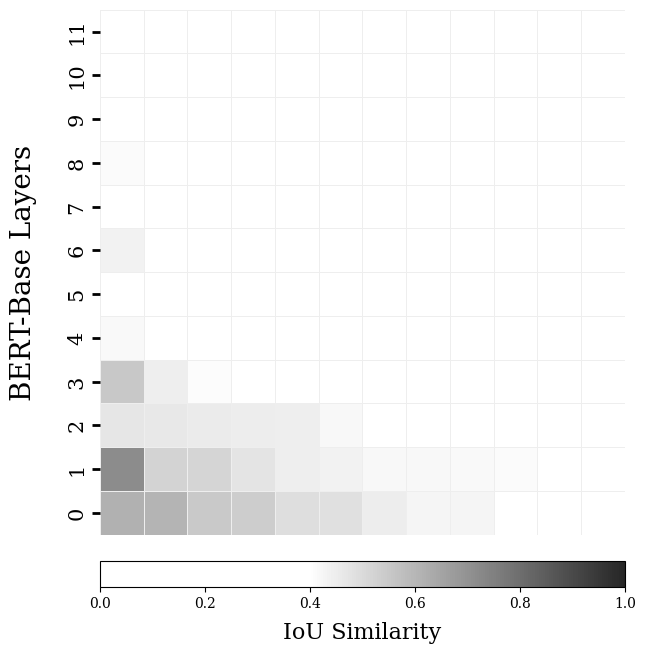

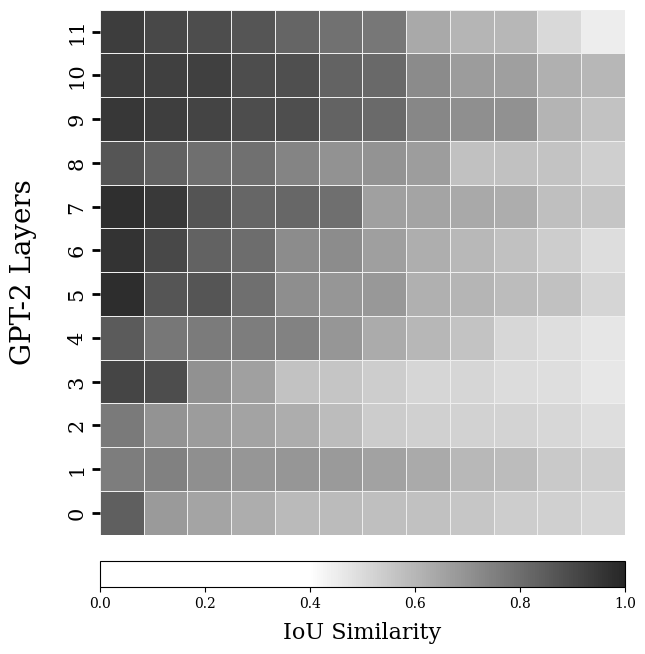

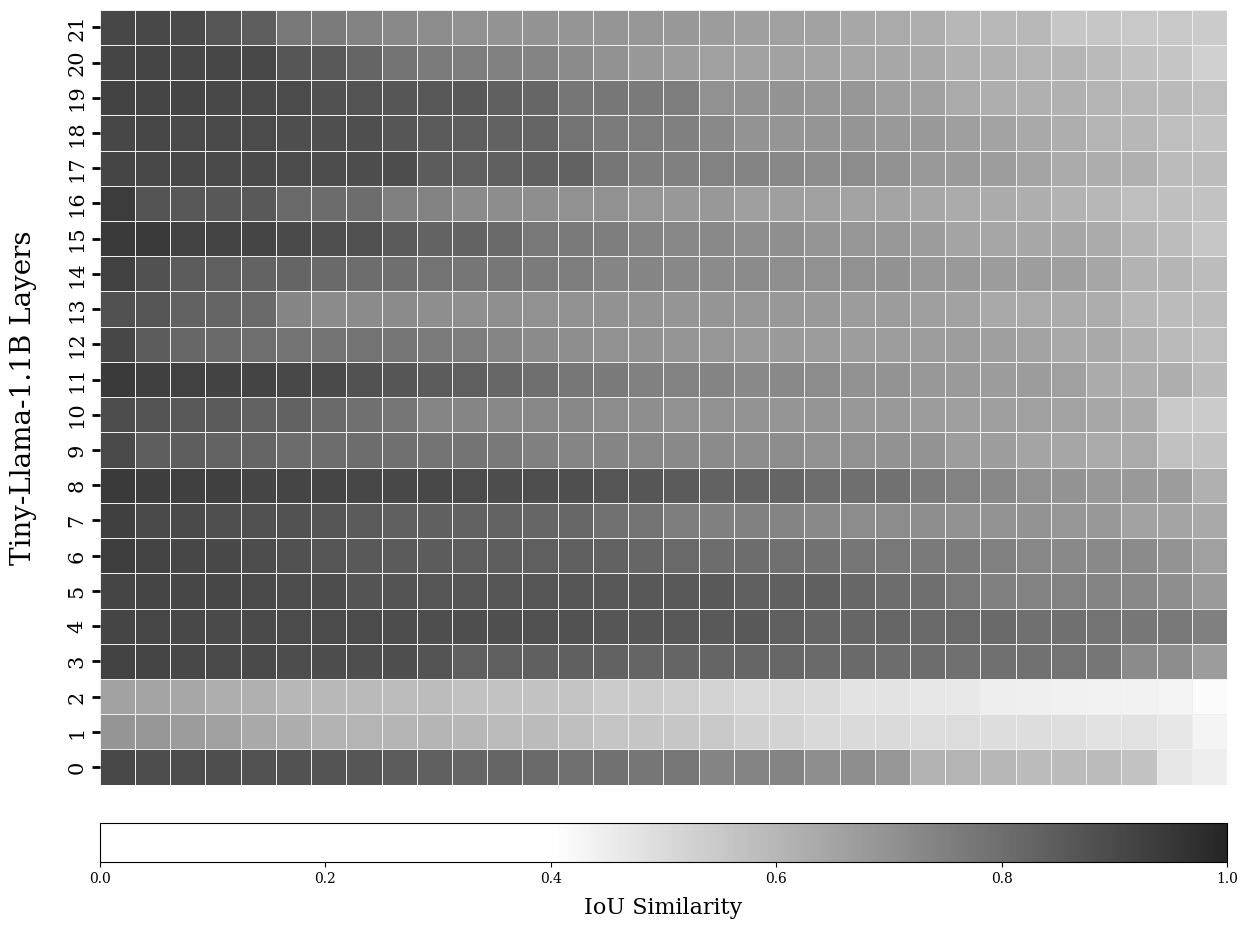

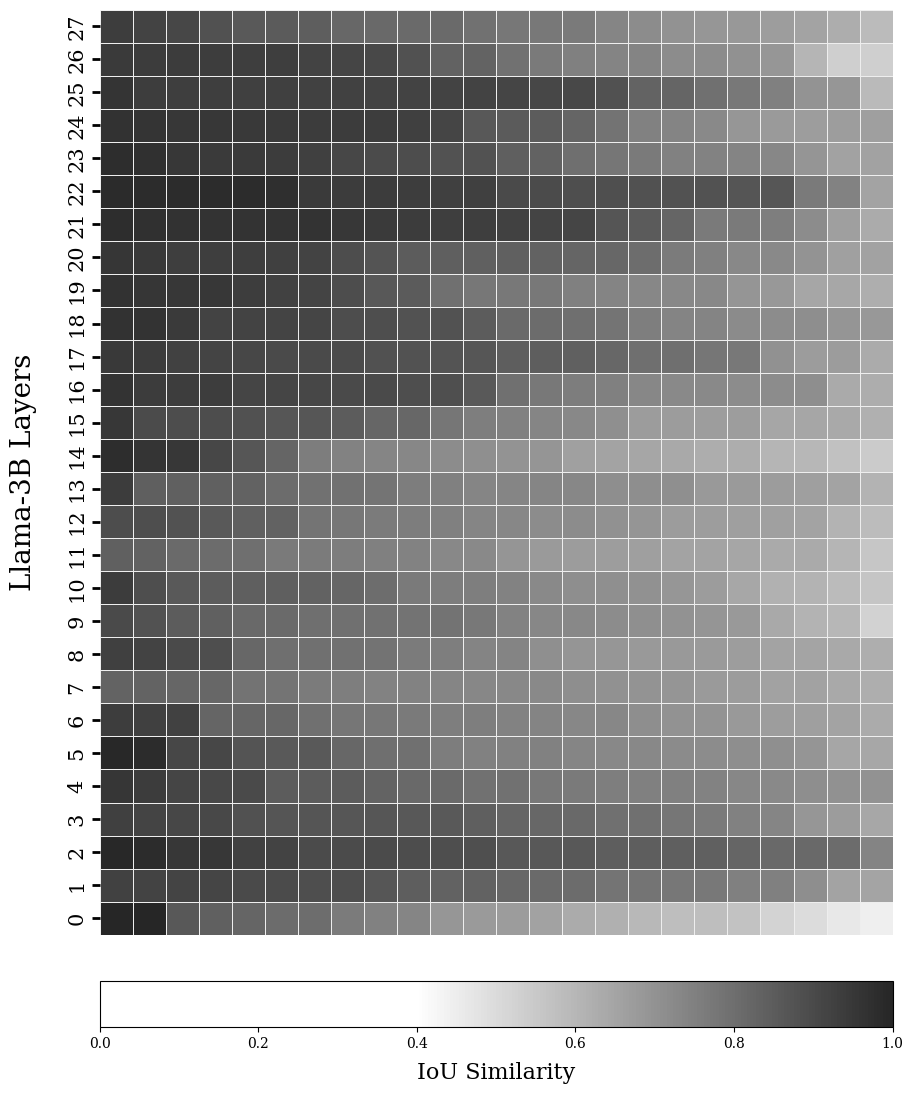

In [125]:
# ── Figure A: Grayscale IoU heatmap + colorbar ────────────────────────────────
def plot_heatmap_iou(model_key, cfg):
    result = load_best_fits(model_key)
    if result[0] is None: return
    bf, n_layers, n_heads, score_mat, name_mat = result

    cell  = 0.5
    fig_w = n_heads * cell + 2.5
    fig_h = n_layers * cell + 4.5
    fig = plt.figure(figsize=(fig_w, fig_h))

    gs = fig.add_gridspec(1, 1, left=0.15, right=0.85, top=0.9, bottom=0.4)
    ax = fig.add_subplot(gs[0])

    # sort rows by highest scores
    score_mat_sorted = np.sort(score_mat, axis=1)[:, ::-1]

    sns.heatmap(score_mat_sorted, ax=ax, cmap=HEATMAP_CMAP, cbar=False,
                linewidths=0.4, linecolor='#EEEEEE',
                vmin=0, vmax=1, square=True, xticklabels=False)

    ax.invert_yaxis()
    ax.set_ylim(0, n_layers)
    # ax.set_xlabel('Head', fontsize=14, labelpad=14)
    # Change labelsize to make text bigger/smaller
    # Change width/length to adjust the actual tick marks
    ax.tick_params(axis='y', labelsize=15, width=2, length=6)
    names = {
        "tinyllama": "Tiny-Llama-1.1B Layers",
        "gpt2": "GPT-2 Layers",
        "bert": "BERT-Base Layers",
        "llama3b": "Llama-3B Layers"
    }
    ax.set_ylabel(f'{names[model_key]}', fontsize=20, labelpad=22)

    plt.draw()
    pos = ax.get_position()

    cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.05, pos.width, 0.025])
    sm = plt.cm.ScalarMappable(cmap=HEATMAP_CMAP, norm=mcolors.Normalize(vmin=0, vmax=1))
    cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cb.set_label('IoU Similarity', fontsize=16, labelpad=8)
    # cb.ax.tick_params(labelsize=7)

    out = f'{RESULTS_DIR}/figure_4_{model_key}_2a'
    plt.savefig(out + '.pdf', bbox_inches='tight', dpi=800)
    plt.show()

for model_key, cfg in MODEL_CONFIGS.items():
    # if model_key == "tinyllama":
        # plot_heatmap_iou(model_key, cfg)
        # plot_heatmap_categories(model_key, cfg)
    plot_heatmap_iou(model_key, cfg)

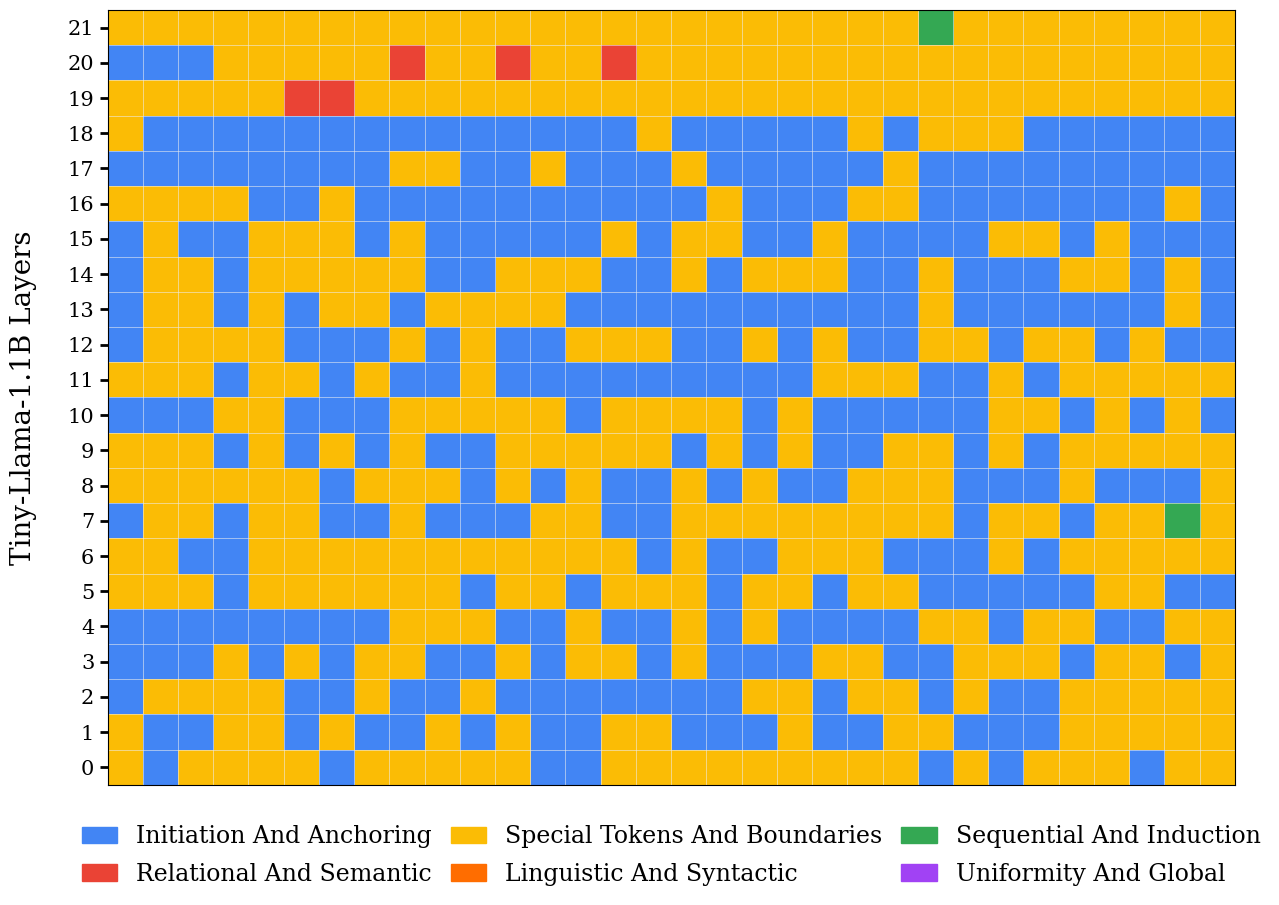

In [ ]:
# ── Figure B: Category color heatmap + legend ─────────────────────────────────
def plot_heatmap_categories(model_key, cfg):
    result = load_best_fits(model_key)
    if result[0] is None: return
    bf, n_layers, n_heads, score_mat, name_mat = result

    # Build category color matrix
    cat_mat = np.zeros((n_layers, n_heads, 4))  # RGBA
    for l in range(n_layers):
        for h in range(n_heads):
            name = name_mat[l, h]
            if name:
                cat   = get_cat_for_model(model_key, name)
                color = CATEGORY_COLORS.get(cat, '#888888')
            else:
                color = '#FFFFFF'
            cat_mat[l, h] = mcolors.to_rgba(color)

    cell  = 0.5
    fig_w = n_heads * cell + 2.5
    fig_h = n_layers * cell + 4.5
    fig = plt.figure(figsize=(fig_w, fig_h))

    gs = fig.add_gridspec(1, 1, left=0.15, right=0.85, top=0.9, bottom=0.4)
    ax = fig.add_subplot(gs[0])

    ax.imshow(cat_mat, aspect='equal', interpolation='nearest',
              origin='upper', extent=[0, n_heads, 0, n_layers])

    # Grid lines to match heatmap style
    for x in range(n_heads + 1):
        ax.axvline(x, color='#EEEEEE', linewidth=0.4)
    for y in range(n_layers + 1):
        ax.axhline(y, color='#EEEEEE', linewidth=0.4)

    ax.set_xlim(0, n_heads)
    ax.set_ylim(0, n_layers)
    # Force a tick at every integer (layer)
    ax.set_yticks(np.arange(n_layers) + 0.5)

    # Set the labels to be the layer numbers (0 to N-1)
    ax.set_yticklabels(range(n_layers))
    # ax.set_xlabel(f'{cfg["display"]} Head', fontsize=14, labelpad=14)
    ax.tick_params(axis='y', labelsize=15, width=2, length=6)
    ax.set_ylabel(f'Tiny-Llama-1.1B Layers', fontsize=20, labelpad=22)
    ax.set_xticks([])

    plt.draw()
    pos = ax.get_position()

    leg_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.05])
    leg_ax.axis('off')

    cat_patches = [
        mpatches.Patch(color=v, label=k.replace('_', ' ').title())
        for k, v in CATEGORY_COLORS.items()
    ]
    leg = leg_ax.legend(
        handles=cat_patches,
        loc='upper center',
        ncol=3,
        fontsize=17,
        frameon=False,
        handlelength=1.5,
        columnspacing=0.8,
        labelspacing=0.6,
        borderaxespad=0.0,
    )
    leg._legend_box.sep = 10

    out = f'{RESULTS_DIR}/figure_4_{model_key}_2b'
    plt.savefig(out + '.pdf', bbox_inches='tight', dpi=800)
    plt.show()

for model_key, cfg in MODEL_CONFIGS.items():
    if model_key == "tinyllama":
        # plot_heatmap_iou(model_key, cfg)
        plot_heatmap_categories(model_key, cfg)

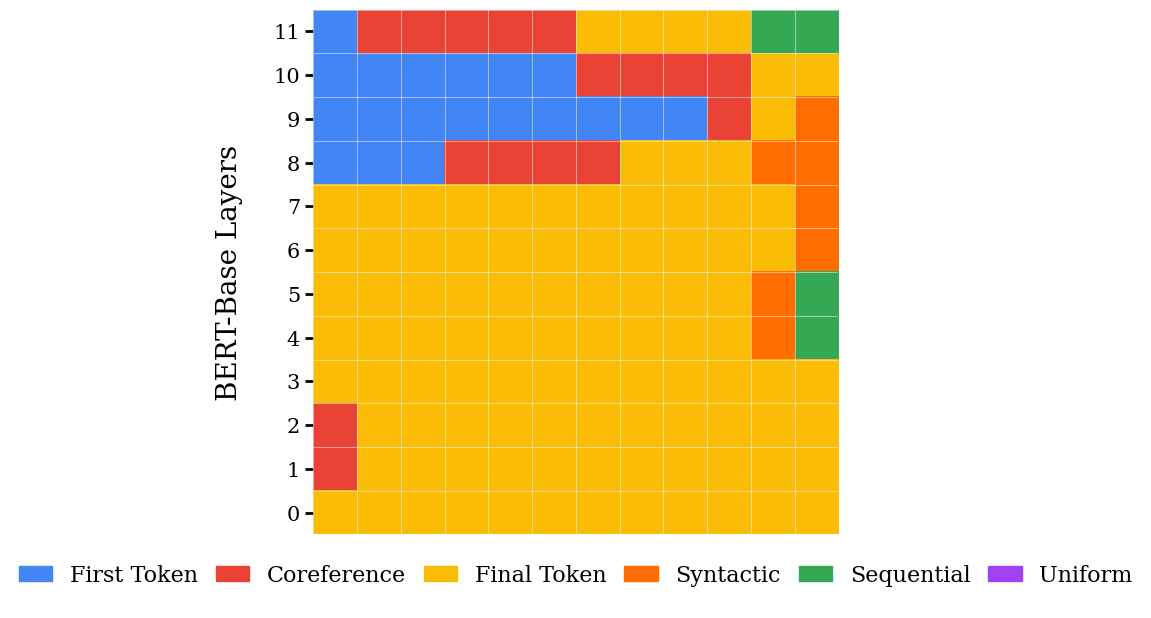

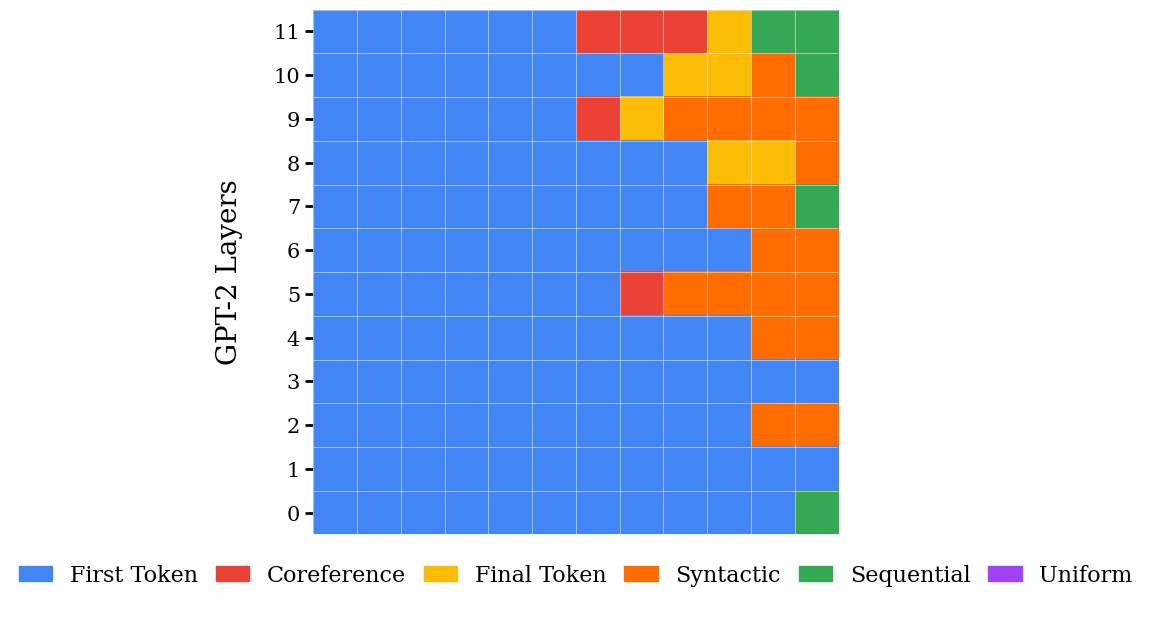

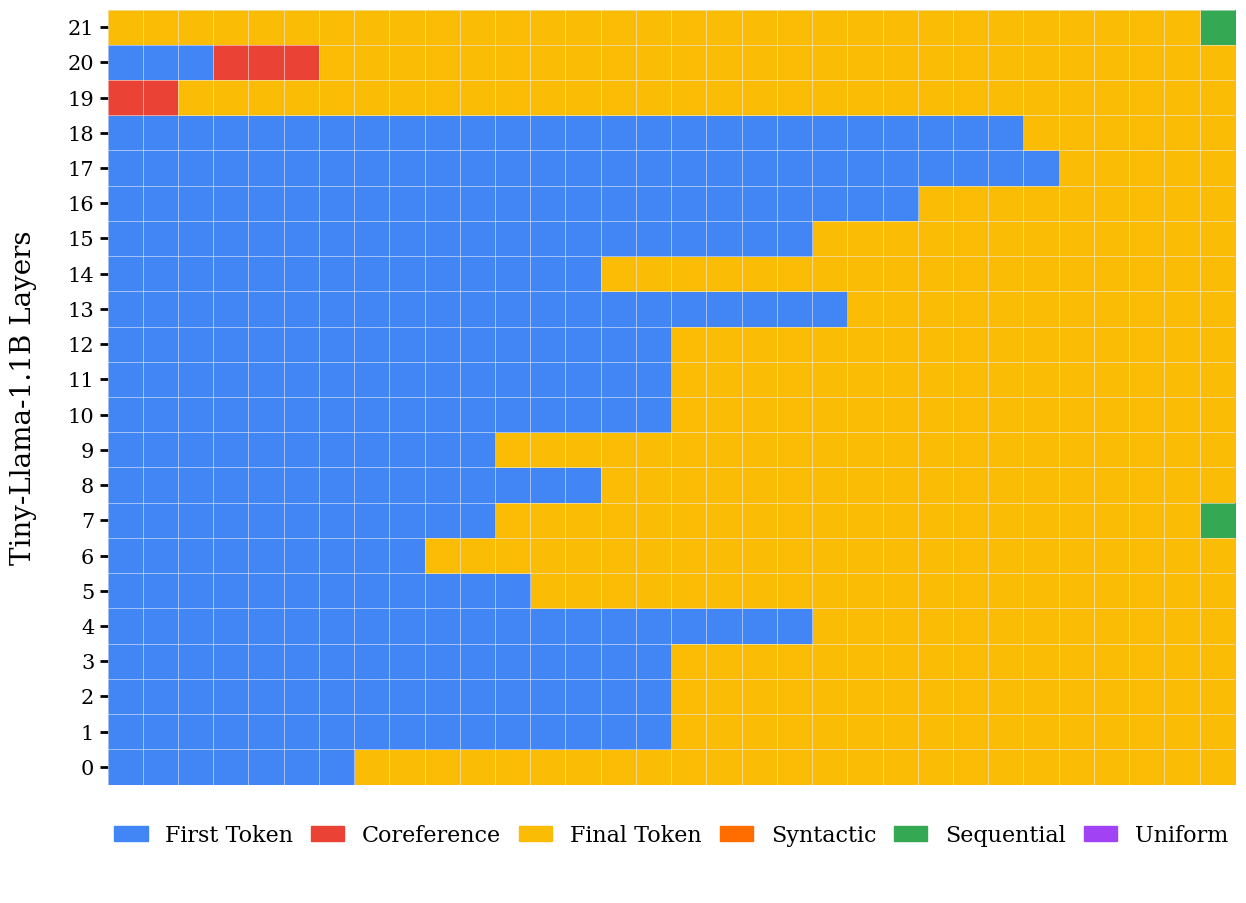

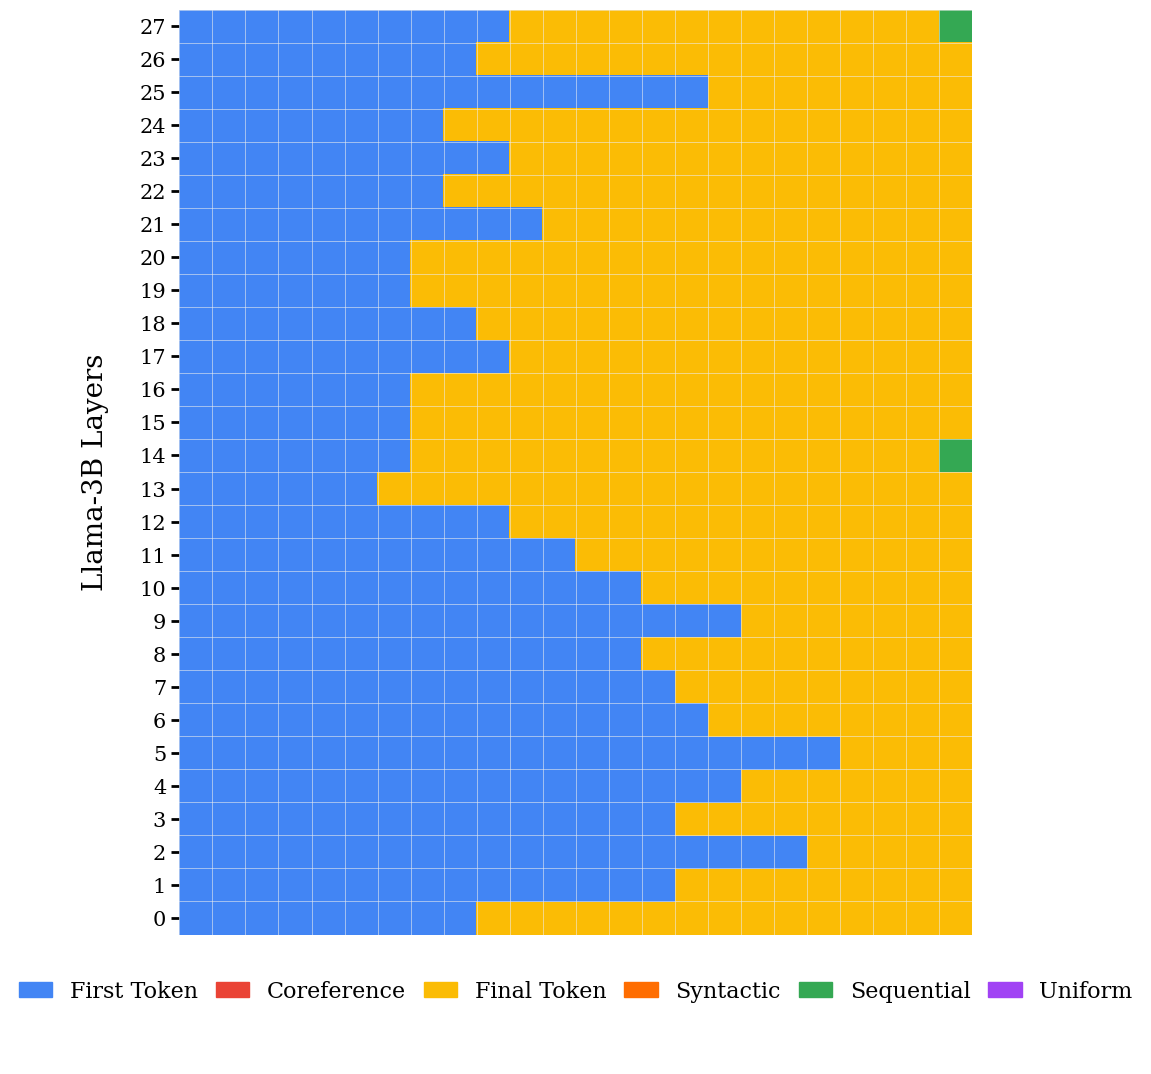

In [133]:
# Mapping categories to priority ranks (0 is far left, 5 is far right)
CATEGORY_PRIORITY = {
    'initiation_and_anchoring': 0,
    'relational_and_semantic': 1,
    'special_tokens_and_boundaries': 2,
    'linguistic_and_syntactic': 3,
    'sequential_and_induction': 4,
    'uniformity_and_global': 5
}

CATEGORY_DISPLAY_NAMES = {
    'initiation_and_anchoring':      'First Token',
    'relational_and_semantic':       'Coreference',
    'special_tokens_and_boundaries': 'Final Token',
    'linguistic_and_syntactic':      'Syntactic',
    'sequential_and_induction':      'Sequential',
    'uniformity_and_global':         'Uniform',
}

# ── Figure B: Category color heatmap + legend ─────────────────────────────────
def plot_heatmap_categories(model_key, cfg):
    result = load_best_fits(model_key)
    if result[0] is None: return
    bf, n_layers, n_heads, score_mat, name_mat = result

    # 1. Determine the sorting indices for each row based on category priority
    prio_mat = np.zeros((n_layers, n_heads))
    for l in range(n_layers):
        for h in range(n_heads):
            name = name_mat[l, h]
            if name:
                cat = get_cat_for_model(model_key, name)
                # Lookup priority; default to 99 if category name doesn't match exactly
                prio_mat[l, h] = CATEGORY_PRIORITY.get(cat, 99)
            else:
                prio_mat[l, h] = 100 # Empty/White cells moved to the far right

    # Get indices that sort priorities independently for every row
    sort_indices = np.argsort(prio_mat, axis=1)

    # 2. Build the category color matrix
    cat_mat = np.zeros((n_layers, n_heads, 4))  # RGBA
    for l in range(n_layers):
        for h in range(n_heads):
            name = name_mat[l, h]
            if name:
                cat   = get_cat_for_model(model_key, name)
                color = CATEGORY_COLORS.get(cat, '#888888')
            else:
                color = '#FFFFFF'
            cat_mat[l, h] = mcolors.to_rgba(color)

    # 3. Apply the sorting to the color matrix using priority indices
    cat_mat = np.take_along_axis(cat_mat, sort_indices[..., np.newaxis], axis=1)

    cell  = 0.5
    fig_w = n_heads * cell + 2.5
    fig_h = n_layers * cell + 4.5
    fig = plt.figure(figsize=(fig_w, fig_h))

    gs = fig.add_gridspec(1, 1, left=0.15, right=0.85, top=0.9, bottom=0.4)
    ax = fig.add_subplot(gs[0])

    ax.imshow(cat_mat, aspect='equal', interpolation='nearest',
              origin='upper', extent=[0, n_heads, 0, n_layers])

    # Grid lines
    for x in range(n_heads + 1):
        ax.axvline(x, color='#EEEEEE', linewidth=0.4)
    for y in range(n_layers + 1):
        ax.axhline(y, color='#EEEEEE', linewidth=0.4)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlim(0, n_heads)
    ax.set_ylim(0, n_layers)
    
    # Y-Axis Formatting
    ax.set_yticks(np.arange(n_layers) + 0.5)
    ax.set_yticklabels(range(n_layers))
    ax.tick_params(axis='y', labelsize=15, width=2, length=6)
    # ax.set_ylabel(f'Tiny-Llama-1.1B Layers', fontsize=20, labelpad=22)
    names = {
        "tinyllama": "Tiny-Llama-1.1B Layers",
        "gpt2": "GPT-2 Layers",
        "bert": "BERT-Base Layers",
        "llama3b": "Llama-3B Layers"
    }
    ax.set_ylabel(f'{names[model_key]}', fontsize=20, labelpad=22)
    
    # Remove X-Axis
    ax.set_xticks([])

    plt.draw()
    pos = ax.get_position()

    # Legend Axis
    leg_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.05])
    leg_ax.axis('off')

    # cat_patches = [
    #     mpatches.Patch(color=v, label=k.replace('_', ' ').title())
    #     for k, v in CATEGORY_COLORS.items()
    # ]
    cat_patches = [
        mpatches.Patch(color=v, label=CATEGORY_DISPLAY_NAMES.get(k, k.replace('_', ' ').title()))
        for k, v in CATEGORY_COLORS.items()
    ]
    leg = leg_ax.legend(
        handles=cat_patches,
        loc='upper center',
        ncol=6,
        fontsize=16,
        frameon=False,
        handlelength=1.5,
        columnspacing=0.8,
        labelspacing=0.6,
        borderaxespad=0.0,
    )
    leg._legend_box.sep = 10

    out = f'{RESULTS_DIR}/figure_4_{model_key}_2b'
    plt.savefig(out + '.pdf', bbox_inches='tight', dpi=800)
    plt.show()

for model_key, cfg in MODEL_CONFIGS.items():
    # if model_key == "tinyllama":
        # plot_heatmap_categories(model_key, cfg)
    plot_heatmap_categories(model_key, cfg)